# Introduction 

The Glasgow Royal Infirmary (GRI) cohort is a retrospective colorectal cancer (CRC) cohort of stage I-III patients from Prof. Joanne Edward's lab. We are interesting in modelling the clinical data associated with these patients in order to predict cancer recurrence and survival probabilities of patients with CRC.

The competing risk is any other cause of death that is not CRC death or CRC recurrence. The event of interest is CRC death and CRC recurrence. 

This file contains a simple data preprocessing, where we look at missing values and filter columns and rows. 

# Dataset

In [263]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import missingno as msno
from sksurv.linear_model import CoxPHSurvivalAnalysis
import seaborn as sns


from helper import smart_fix_dtypes
from helper import clean_columns

pd.set_option("display.max_columns", None)
#pd.set_option("display.max_rows", None)



In [264]:
df = pd.read_excel("data/GRI_FullDataset.xlsx", na_values=["NaN", "nan", "NA", "NAN"])

In [265]:
df

,TMA_order,TMA_number,CSS_months_2020,UpdateJuly2020_a0_cd1_ncd2,neoadj1,Thirtyday_mortality_2017,c0r1,CMS_Raheleh_withoutlabels,DFS_months_2020,DFS_status_July2020,DateofLastFollowUp01072020,date_recurrence_01072020,MMR_Status_Jen,adj1,el0em1,dofsurg,dob,REC_n0_yes1,DFS_months,DFS_years,Vital_status_confirmed,Notes,PrimaryCOD,Recurrence_local1_distant2,Local_recurrenceKK,Distant_recurrenceKK,Recurrence_Location,Colin_full_recurrence_sites,Recurrence_code,operation,Date_of_scan,age,agecd,sex,Female,Male,Right0_Left1,Location,Dukes,tstage,nstage,mstage,Differentiation,Diffcd,Tumour_budding,TuPerf,MargInv,venousinv,Perineural_Inv,PeritInv,Petersen_Index,Petersen_Index_low0_high1,TSP_Pete,TSP_Pete_HL,KM_Pete,KM_Pete_HL,GMS_Pete,mGPS,NLR_gtr5,ASA_group,weight,height,BMI_code,BMIunder30,BMIover30Y1N0,Smoker_n0_ex1_curr2,smoker,cigsday,exsmoker,anysmoke,Pathology_Notes,LNmet,LNsample,less12nodes,Neut,lymph,precrp,crp_code,prealb,alb_code,Aspirin,NSAID,Statin,Metformin,Mucin,Neut_gtr75,NLR,LNR,LNR_code,Elastica_VI,Less_than_10,ASCO_high_risk,crp,pre_lymph,Local_distant_recurrenc,Lymphoid_aggregates,Germinal_centres,Graham_Appelman_CLR,Ueno_CLR,Ueno_CLR_1mmcutoff,Vayrynen_CLR,Vayrynen_CLR_0.38cutoff,IE_Lymphocytes,IE_lymphocytesHL,filter_$,ImageAnalysis_Ki67,Ki67_Code_30,PTPN12st_cd28.31,PTPN12_tum_cd40.09,PTPN12both_32.97,PTPN12_tum,PTPN12_stroma,PTPN12_both,IL6R_AK_186.64,S100A2_raw,S100A2_code,combined_tbs100,CD3_raw,CD3_code,CD3_FOXP3_raw,CD3_FOXP3_code,CD68_raw,CD68_code,combinedCD3CD68,raw_CXCL9_s,CXCL9_s_code,CXCL9_t_code,raw_CXCL10_s,CXCL10_s_code,CXCL10_t_code,Cyclind1_raw,cyclind1_code,KI67_t,KI67_tumour_code,CD163_Str,CD163_code,CD66b,CD66b_code,ratioCD163CD68,ratio_M2M1_code,IKKA_MM,IKK_Beta_MM,IKK_Beta_MM_42.79,IKK_AplusIKK_B,IKKA_IKKB_Ratio,STAT1_tumour_raw,STAT1_tumour_cutoff_BK,CD3FOXP3_raw,CD3FOXP3_n_code,Bcat_Cyto,Bcat_Cyto_Coded,Bcat_Nuc,Bcat_nuc_coded,Bcat_Mem,Bcat_mem_coded,Fascin_cyto,Fascin_cyto_coded,Ecad_cyto,Ecad_Mem,Ecad_cyto_coded,Ecad_mem_coded,Zeb_cyto_coded,Zeb_nuc,Zeb_nuc_coded,Twist_cyto,Twist_cyto_coded,Twist_nuc,Twist_nuc_coded,Snail_cyto,Snail_cyto_coded,Snailnuc,Snail_nuc_coded,SOX9_cyto,SOX9_cyto_coded,SOX9_nuc,SOX9_nuc_coded,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Cyto_67.51_coded,SMAD4_Nu_NS,SMAD4_Nu_6.91_coded,SMAD4_CytoNu_combined,twolines_SMAD4_Cyto_Nu_combined,SMAD4_Stroma_Cyto,SMAD4_Stroma_Cyto_4.94_coded,SMAD4_Stroma_Nu,SMAD4_Stroma_Nu_3.88_coded,SMAD4_Stroma_CytoNu_combined,Zeb1_cyto_IE_code,Zeb1_nuc_IE1_A,Zeb1_nuc_IE_code,Zeb1_cyto_IE_mc,Zeb1_cyto_IE_mc_code,Bud_histoscore_Zeb1_code,Bud_histoscore_zeb1_mc,Bud_histo_Zeb_mc_code,Cyto_budcohort_Zeb11_A,Cyto_budcohort_zeb1_code,Nuc_budcohort_zeb1,Nuc_budcohort_zeb1_code,Zeb1_cyto_IE,NPM1_GK,pSTAT3_705_UH,pSTAT3_UH_TC_198.01,pSTAT3_Tum_Bud_PM,pSTAT3_Tum_Bud_12,IL17RA_Abs_PresPM
0,1,TMA1,97,0.0,0.0,0,0.0,3.0,97.0,0.0,01.07.2020,01.07.2020,1.0,0.0,0.0,22.05.2012,01.03.1945,0.0,NaN,NaN,NaN,right and caecum,NaN,0.0,0.0,0.0,NaN,0.0,0.0,subtotal,11.05.2012,67.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,3.0,0.0,0.0,mod,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,2.0,1.0,0.0,1.0,0.0,2.0,86.0,1.73,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Synch tumours,0.0,35.0,0.0,6.3,1.6,11.0,1.0,35.0,0.0,NaN,NaN,NaN,NaN,1.0,0.0,3.94,0.00,0.0,1.0,0.0,0.0,1.10,1600.0,NaN,13.0,4.0,2.0,0.81,0.0,0.69,1.0,1.6,0.0,1.0,7.02,0.0,1,1,1,49.49,31.21,37.93,0.0,103.0,1.0,1.0,5.63,1.0,2.17,1.0,5.07,0.0,2.0,0.21,0.0,1.0,0.35,0.0,0.0,65.00,0.0,25.81,1.0,14.27,1.0,0.86,0.0,2.82,0.0,118.25,1.26,0.0,119.51,2.07,121.45,1.0,29.33,1.0,141.0,1.0,23.0,0.0,137.0,1.0,23.0,1.0,NaN,285.0,NaN,1.0,122.0,1.0,179.0,1.0,127.0,0.0,167.0,0.0,111.0,0.0,136.0,0.0,175.0,0.0,240.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.62,1.0,82.42,0.0,101.62,1.0,135.82,3.67,0.0,NaN,NaN,NaN
1,2,TMA1,97,0.0,0.0,0,0.0,NaN,97.0,0.0,01.07.2020,01.07.2020,NaN,0.0,0.0,23.05.2012,27.12.1933,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.0,left,06.02.2012,78.0,2.0,1.0,0.0,1.0,1.0,1.0,2.0,3.0,0.0,0.0,mod,0.0,0.0,0.0,0.0

In [266]:
df[["CSS_months_2020", "DFS_months_2020", "DFS_status_July2020", "REC_n0_yes1", "UpdateJuly2020_a0_cd1_ncd2"]]

,CSS_months_2020,DFS_months_2020,DFS_status_July2020,REC_n0_yes1,UpdateJuly2020_a0_cd1_ncd2
0,97,97.0,0.0,0.0,0.0
1,97,97.0,0.0,0.0,0.0
2,50,25.0,1.0,1.0,1.0
3,83,83.0,2.0,0.0,2.0
4,96,96.0,0.0,0.0,0.0
...,...,...,...,...,...
781,103,103.0,2.0,0.0,2.0
782,53,29.0,1.0,1.0,1.0
783,145,145.0,2.0,0.0,2.0
784,52,52.0,2.0,0.0,2.0


### Missigness

In [267]:
print(df.isna().sum().to_string())

TMA_order                            0
TMA_number                           0
CSS_months_2020                      0
UpdateJuly2020_a0_cd1_ncd2           3
neoadj1                              2
Thirtyday_mortality_2017             0
c0r1                                 2
CMS_Raheleh_withoutlabels          352
DFS_months_2020                     23
DFS_status_July2020                 22
DateofLastFollowUp01072020           0
date_recurrence_01072020            23
MMR_Status_Jen                      26
adj1                                 2
el0em1                               2
dofsurg                              0
dob                                  0
REC_n0_yes1                         20
DFS_months                         569
DFS_years                          569
Vital_status_confirmed             722
Notes                              618
PrimaryCOD                         412
Recurrence_local1_distant2          25
Local_recurrenceKK                  25
Distant_recurrenceKK     

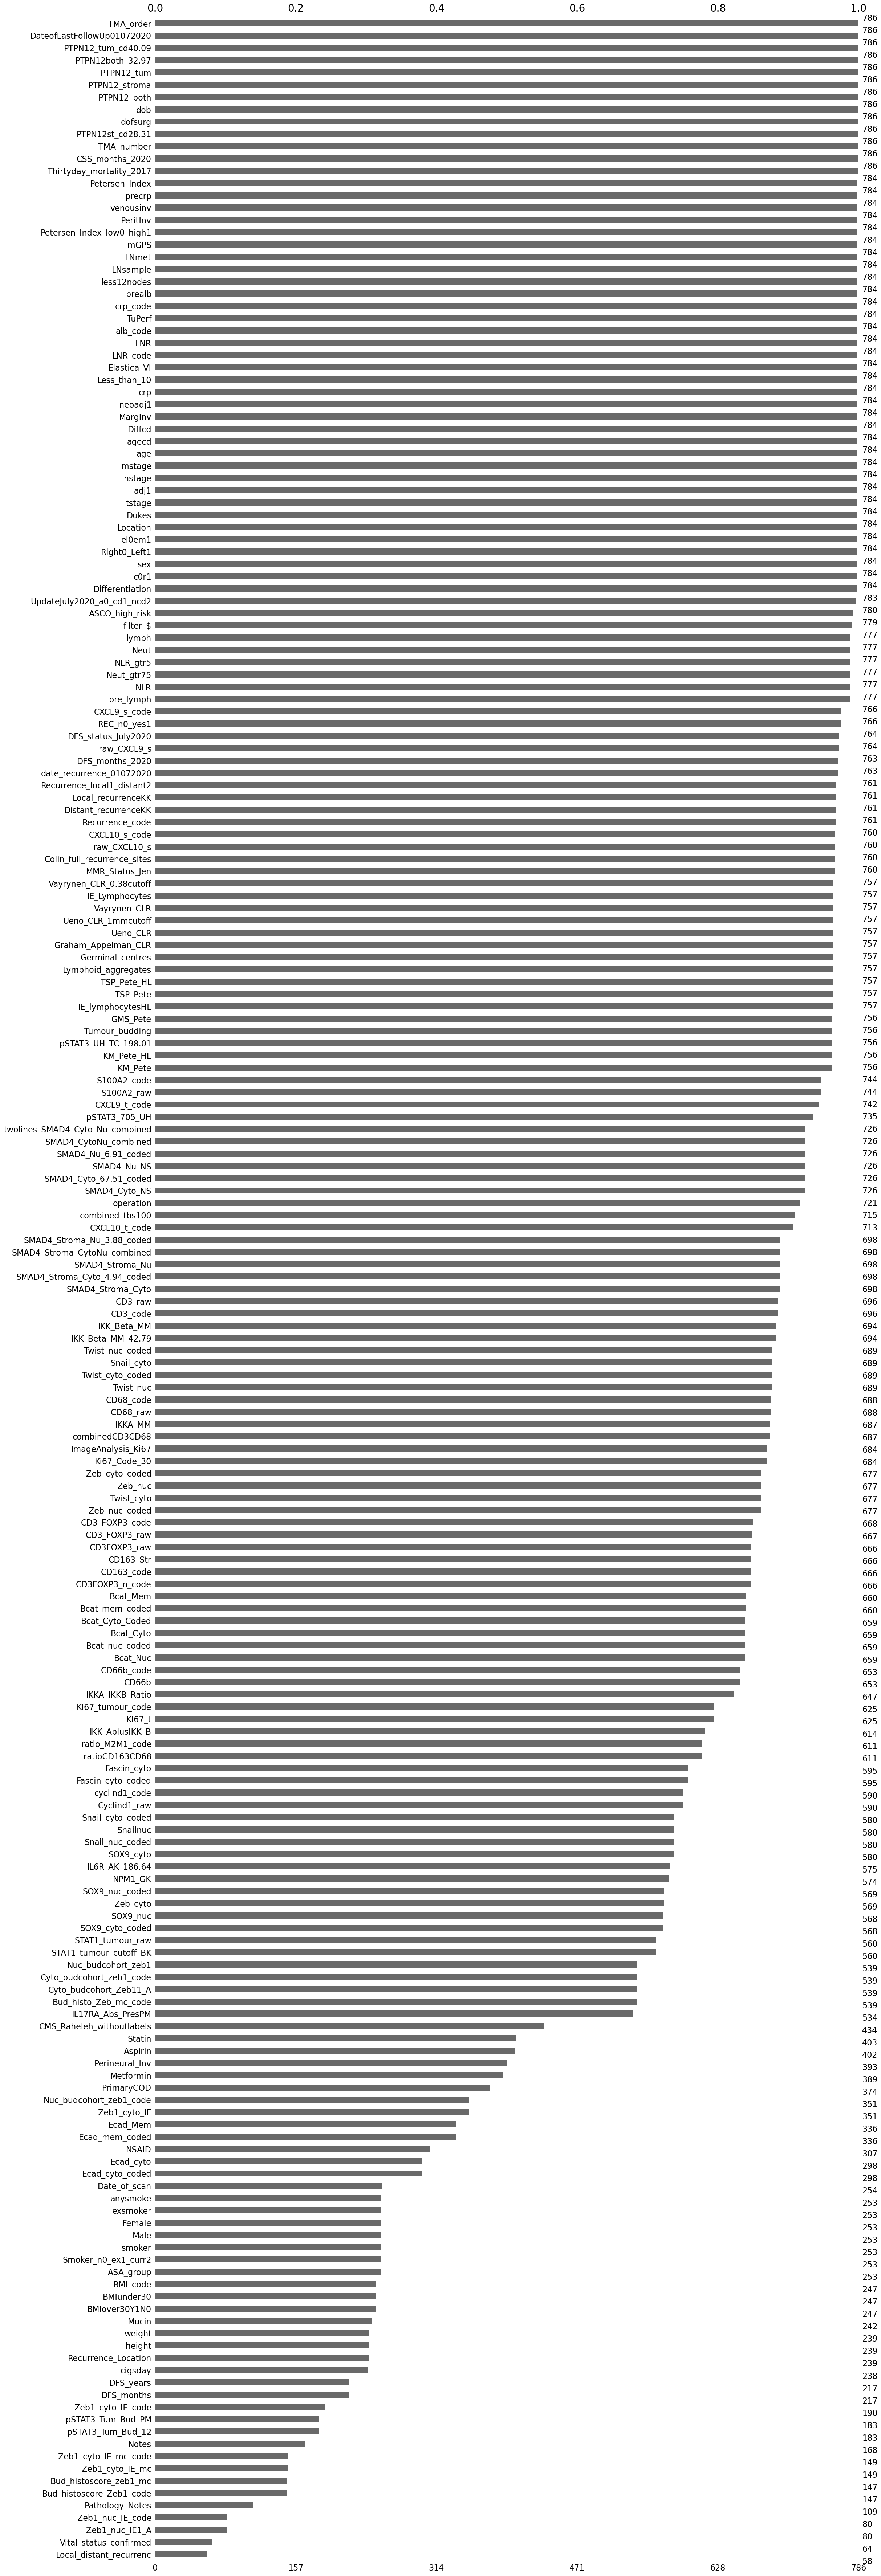

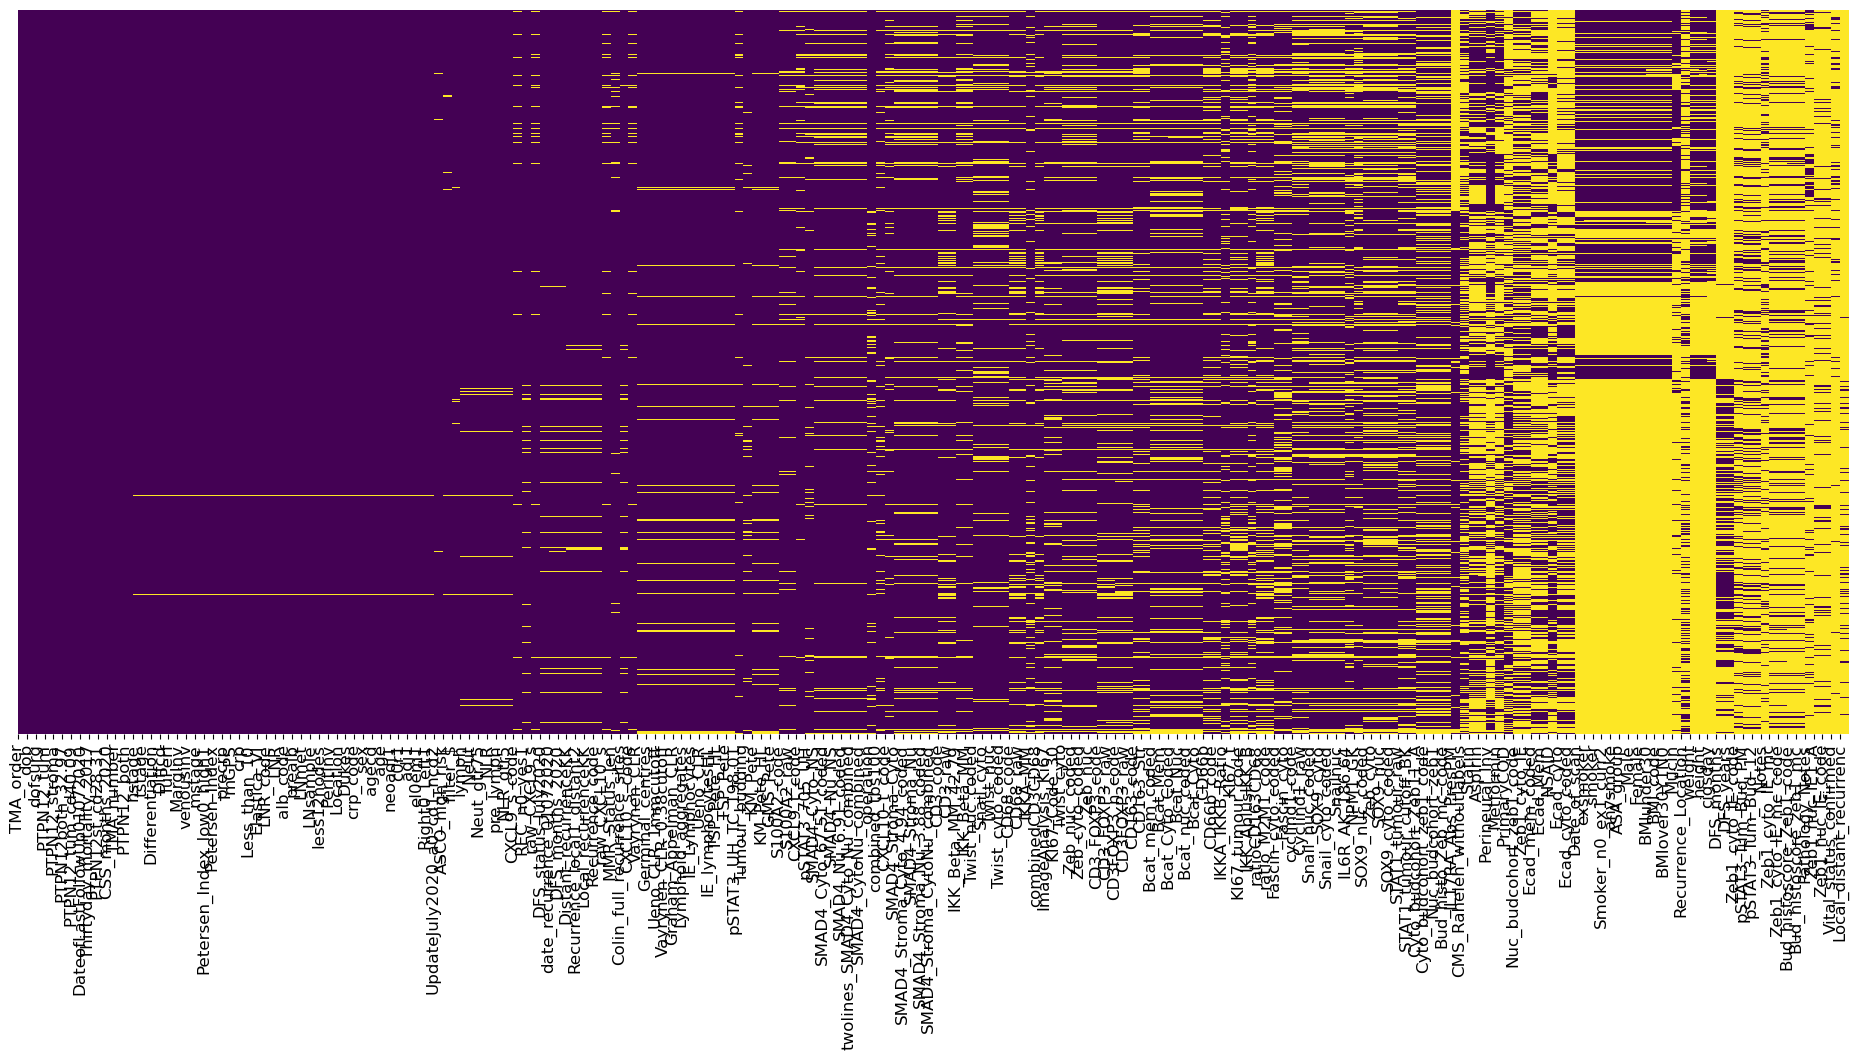

In [268]:
# Plot missigness
# Bar chart (missing counts per column)
msno.bar(df,  sort = "ascending")
plt.show()

# Heatmap of missing-value correlations
#msno.heatmap(df)
#plt.show()

plt.figure(figsize=(19, 11))

missing_order = df.isna().mean().sort_values()

df_sorted = df[missing_order.index]
ax = sns.heatmap(df_sorted.isna(), cbar=False, cmap="viridis")

ax.set_xticks(range(len(df_sorted.columns)))
ax.set_xticklabels(df_sorted.columns, rotation=90, ha="center", fontsize=12)
ax.set_yticks([])
plt.tight_layout()

#### Preprocessing

Initial preprocessing includes exclusion criteria such not including those patients that have neoadjuvant therapy. 
Also, some patients gave the value 999 as NA, and the event is set as "12", instead of 0, 1 or 2.

Exclusion criteria: patients with neoadjuvant therapy

In [269]:
df["neoadj1"].value_counts(dropna=False)

neoadj1
0.0      724
1.0       55
999.0      5
NaN        2
Name: count, dtype: int64

In [270]:
df.shape

(786, 207)

In [271]:
# make a subset with those that contain neoadjuvant therapy 0
df = df[df["neoadj1"] == 0]

In [272]:
df.shape

(724, 207)

In [273]:
df["UpdateJuly2020_a0_cd1_ncd2"].value_counts(dropna=False)

UpdateJuly2020_a0_cd1_ncd2
2.0     267
0.0     247
1.0     207
NaN       2
12.0      1
Name: count, dtype: int64

In [274]:
df.loc[df['UpdateJuly2020_a0_cd1_ncd2'].isnull()]


,TMA_order,TMA_number,CSS_months_2020,UpdateJuly2020_a0_cd1_ncd2,neoadj1,Thirtyday_mortality_2017,c0r1,CMS_Raheleh_withoutlabels,DFS_months_2020,DFS_status_July2020,DateofLastFollowUp01072020,date_recurrence_01072020,MMR_Status_Jen,adj1,el0em1,dofsurg,dob,REC_n0_yes1,DFS_months,DFS_years,Vital_status_confirmed,Notes,PrimaryCOD,Recurrence_local1_distant2,Local_recurrenceKK,Distant_recurrenceKK,Recurrence_Location,Colin_full_recurrence_sites,Recurrence_code,operation,Date_of_scan,age,agecd,sex,Female,Male,Right0_Left1,Location,Dukes,tstage,nstage,mstage,Differentiation,Diffcd,Tumour_budding,TuPerf,MargInv,venousinv,Perineural_Inv,PeritInv,Petersen_Index,Petersen_Index_low0_high1,TSP_Pete,TSP_Pete_HL,KM_Pete,KM_Pete_HL,GMS_Pete,mGPS,NLR_gtr5,ASA_group,weight,height,BMI_code,BMIunder30,BMIover30Y1N0,Smoker_n0_ex1_curr2,smoker,cigsday,exsmoker,anysmoke,Pathology_Notes,LNmet,LNsample,less12nodes,Neut,lymph,precrp,crp_code,prealb,alb_code,Aspirin,NSAID,Statin,Metformin,Mucin,Neut_gtr75,NLR,LNR,LNR_code,Elastica_VI,Less_than_10,ASCO_high_risk,crp,pre_lymph,Local_distant_recurrenc,Lymphoid_aggregates,Germinal_centres,Graham_Appelman_CLR,Ueno_CLR,Ueno_CLR_1mmcutoff,Vayrynen_CLR,Vayrynen_CLR_0.38cutoff,IE_Lymphocytes,IE_lymphocytesHL,filter_$,ImageAnalysis_Ki67,Ki67_Code_30,PTPN12st_cd28.31,PTPN12_tum_cd40.09,PTPN12both_32.97,PTPN12_tum,PTPN12_stroma,PTPN12_both,IL6R_AK_186.64,S100A2_raw,S100A2_code,combined_tbs100,CD3_raw,CD3_code,CD3_FOXP3_raw,CD3_FOXP3_code,CD68_raw,CD68_code,combinedCD3CD68,raw_CXCL9_s,CXCL9_s_code,CXCL9_t_code,raw_CXCL10_s,CXCL10_s_code,CXCL10_t_code,Cyclind1_raw,cyclind1_code,KI67_t,KI67_tumour_code,CD163_Str,CD163_code,CD66b,CD66b_code,ratioCD163CD68,ratio_M2M1_code,IKKA_MM,IKK_Beta_MM,IKK_Beta_MM_42.79,IKK_AplusIKK_B,IKKA_IKKB_Ratio,STAT1_tumour_raw,STAT1_tumour_cutoff_BK,CD3FOXP3_raw,CD3FOXP3_n_code,Bcat_Cyto,Bcat_Cyto_Coded,Bcat_Nuc,Bcat_nuc_coded,Bcat_Mem,Bcat_mem_coded,Fascin_cyto,Fascin_cyto_coded,Ecad_cyto,Ecad_Mem,Ecad_cyto_coded,Ecad_mem_coded,Zeb_cyto_coded,Zeb_nuc,Zeb_nuc_coded,Twist_cyto,Twist_cyto_coded,Twist_nuc,Twist_nuc_coded,Snail_cyto,Snail_cyto_coded,Snailnuc,Snail_nuc_coded,SOX9_cyto,SOX9_cyto_coded,SOX9_nuc,SOX9_nuc_coded,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Cyto_67.51_coded,SMAD4_Nu_NS,SMAD4_Nu_6.91_coded,SMAD4_CytoNu_combined,twolines_SMAD4_Cyto_Nu_combined,SMAD4_Stroma_Cyto,SMAD4_Stroma_Cyto_4.94_coded,SMAD4_Stroma_Nu,SMAD4_Stroma_Nu_3.88_coded,SMAD4_Stroma_CytoNu_combined,Zeb1_cyto_IE_code,Zeb1_nuc_IE1_A,Zeb1_nuc_IE_code,Zeb1_cyto_IE_mc,Zeb1_cyto_IE_mc_code,Bud_histoscore_Zeb1_code,Bud_histoscore_zeb1_mc,Bud_histo_Zeb_mc_code,Cyto_budcohort_Zeb11_A,Cyto_budcohort_zeb1_code,Nuc_budcohort_zeb1,Nuc_budcohort_zeb1_code,Zeb1_cyto_IE,NPM1_GK,pSTAT3_705_UH,pSTAT3_UH_TC_198.01,pSTAT3_Tum_Bud_PM,pSTAT3_Tum_Bud_12,IL17RA_Abs_PresPM
118,119,TMA1,105,NaN,0.0,0,0.0,NaN,105.0,0.0,01.07.2020,01.07.2020,2.0,1.0,0.0,27.09.2011,17.06.1961,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.0,right,12.08.2011,50.0,0.0,1.0,0.0,1.0,0.0,0.0,3.0,3.0,1.0,0.0,mod,0.0,0.0,0.0,0.0,1.0,NaN,0.0,1.0,0.0,80.0,1.0,0.0,0.0,2.0,0.0,0.0,1.0,66.2,1.66,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0,39.0,0.0,2.4,1.6,2.7,0.0,36.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,1.50,0.05,1.0,1.0,0.0,1.0,0.27,1600.0,NaN,6.0,0.0,1.0,0.68,0.0,0.21,0.0,0.6,0.0,1.0,NaN,NaN,1,1,1,92.48,85.77,87.83,0.0,103.0,1.0,1.0,8.31,1.0,0.89,0.0,3.19,0.0,1.0,2.44,0.0,0.0,3.13,0.0,1.0,58.33,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.71,189.78,1.0,316.49,27.35,85.39,1.0,11.25,0.0,152.0,1.0,31.0,0.0,130.0,1.0,2.0,0.0,227.0,290.00,1.0,1.0,105.0,1.0,152.0,0.0,141.0,0.0,186.0,0.0,76.0,1.0,84.0,1.0,93.0,1.0,224.0,0.0,28.90,0.0,3.69,0.0,0.0,0.0,1.49,0.0,1.20,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,196.70,207.01,1.0,NaN,NaN,NaN
587,588,TMA3,8,NaN,0.0,0,1.0,NaN,NaN,0.0,31.07.2003,NaN,2.0,0.0,0.0,01.11.2002,10.09.1923,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.0,proctect,NaN,79.0,2.0,1.0,NaN,NaN,1.0,2.0,2.0,3.0,0.0,0.0,mod,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,30.0,0.0,1.0,0.0,1.0

In [275]:
# we can keep the ones without nan in patient outcome
df = df[df["UpdateJuly2020_a0_cd1_ncd2"].notna()]

In [276]:
df.loc[df['UpdateJuly2020_a0_cd1_ncd2'] == 12]

,TMA_order,TMA_number,CSS_months_2020,UpdateJuly2020_a0_cd1_ncd2,neoadj1,Thirtyday_mortality_2017,c0r1,CMS_Raheleh_withoutlabels,DFS_months_2020,DFS_status_July2020,DateofLastFollowUp01072020,date_recurrence_01072020,MMR_Status_Jen,adj1,el0em1,dofsurg,dob,REC_n0_yes1,DFS_months,DFS_years,Vital_status_confirmed,Notes,PrimaryCOD,Recurrence_local1_distant2,Local_recurrenceKK,Distant_recurrenceKK,Recurrence_Location,Colin_full_recurrence_sites,Recurrence_code,operation,Date_of_scan,age,agecd,sex,Female,Male,Right0_Left1,Location,Dukes,tstage,nstage,mstage,Differentiation,Diffcd,Tumour_budding,TuPerf,MargInv,venousinv,Perineural_Inv,PeritInv,Petersen_Index,Petersen_Index_low0_high1,TSP_Pete,TSP_Pete_HL,KM_Pete,KM_Pete_HL,GMS_Pete,mGPS,NLR_gtr5,ASA_group,weight,height,BMI_code,BMIunder30,BMIover30Y1N0,Smoker_n0_ex1_curr2,smoker,cigsday,exsmoker,anysmoke,Pathology_Notes,LNmet,LNsample,less12nodes,Neut,lymph,precrp,crp_code,prealb,alb_code,Aspirin,NSAID,Statin,Metformin,Mucin,Neut_gtr75,NLR,LNR,LNR_code,Elastica_VI,Less_than_10,ASCO_high_risk,crp,pre_lymph,Local_distant_recurrenc,Lymphoid_aggregates,Germinal_centres,Graham_Appelman_CLR,Ueno_CLR,Ueno_CLR_1mmcutoff,Vayrynen_CLR,Vayrynen_CLR_0.38cutoff,IE_Lymphocytes,IE_lymphocytesHL,filter_$,ImageAnalysis_Ki67,Ki67_Code_30,PTPN12st_cd28.31,PTPN12_tum_cd40.09,PTPN12both_32.97,PTPN12_tum,PTPN12_stroma,PTPN12_both,IL6R_AK_186.64,S100A2_raw,S100A2_code,combined_tbs100,CD3_raw,CD3_code,CD3_FOXP3_raw,CD3_FOXP3_code,CD68_raw,CD68_code,combinedCD3CD68,raw_CXCL9_s,CXCL9_s_code,CXCL9_t_code,raw_CXCL10_s,CXCL10_s_code,CXCL10_t_code,Cyclind1_raw,cyclind1_code,KI67_t,KI67_tumour_code,CD163_Str,CD163_code,CD66b,CD66b_code,ratioCD163CD68,ratio_M2M1_code,IKKA_MM,IKK_Beta_MM,IKK_Beta_MM_42.79,IKK_AplusIKK_B,IKKA_IKKB_Ratio,STAT1_tumour_raw,STAT1_tumour_cutoff_BK,CD3FOXP3_raw,CD3FOXP3_n_code,Bcat_Cyto,Bcat_Cyto_Coded,Bcat_Nuc,Bcat_nuc_coded,Bcat_Mem,Bcat_mem_coded,Fascin_cyto,Fascin_cyto_coded,Ecad_cyto,Ecad_Mem,Ecad_cyto_coded,Ecad_mem_coded,Zeb_cyto_coded,Zeb_nuc,Zeb_nuc_coded,Twist_cyto,Twist_cyto_coded,Twist_nuc,Twist_nuc_coded,Snail_cyto,Snail_cyto_coded,Snailnuc,Snail_nuc_coded,SOX9_cyto,SOX9_cyto_coded,SOX9_nuc,SOX9_nuc_coded,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Cyto_67.51_coded,SMAD4_Nu_NS,SMAD4_Nu_6.91_coded,SMAD4_CytoNu_combined,twolines_SMAD4_Cyto_Nu_combined,SMAD4_Stroma_Cyto,SMAD4_Stroma_Cyto_4.94_coded,SMAD4_Stroma_Nu,SMAD4_Stroma_Nu_3.88_coded,SMAD4_Stroma_CytoNu_combined,Zeb1_cyto_IE_code,Zeb1_nuc_IE1_A,Zeb1_nuc_IE_code,Zeb1_cyto_IE_mc,Zeb1_cyto_IE_mc_code,Bud_histoscore_Zeb1_code,Bud_histoscore_zeb1_mc,Bud_histo_Zeb_mc_code,Cyto_budcohort_Zeb11_A,Cyto_budcohort_zeb1_code,Nuc_budcohort_zeb1,Nuc_budcohort_zeb1_code,Zeb1_cyto_IE,NPM1_GK,pSTAT3_705_UH,pSTAT3_UH_TC_198.01,pSTAT3_Tum_Bud_PM,pSTAT3_Tum_Bud_12,IL17RA_Abs_PresPM
530,531,TMA3,62,12.0,0.0,0,1.0,4.0,62.0,0.0,02.12.2006,02.12.2006,3.0,1.0,0.0,26.09.2001,12.10.1943,0.0,137.0,11.42,NaN,"Moved to Grangemouth, LTF",NaN,0.0,0.0,0.0,NaN,0.0,0.0,proctect,NaN,57.0,0.0,1.0,NaN,NaN,1.0,2.0,3.0,3.0,1.0,0.0,mod,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,30.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,synch Dukes C and A tumours,1.0,14.0,0.0,5.6,1.4,6.0,0.0,41.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,4.0,0.07,1.0,0.0,0.0,0.0,0.6,1400.0,NaN,7.0,0.0,1.0,0.54,0.0,0.3,0.0,0.4,0.0,1.0,35.41,1.0,0,1,1,43.89,23.4,36.9,1.0,73.0,0.0,0.0,17.14,1.0,4.05,1.0,1.75,0.0,2.0,3.43,1.0,0.0,1.09,0.0,0.0,167.5,1.0,35.03,1.0,8.23,1.0,1.27,1.0,4.72,0.0,114.85,134.95,1.0,249.8,20.38,257.08,1.0,17.91,1.0,130.0,0.0,37.0,0.0,135.0,1.0,12.0,1.0,191.0,NaN,1.0,NaN,97.0,1.0,104.0,0.0,130.0,0.0,208.0,0.0,149.0,0.0,155.0,0.0,206.0,0.0,264.0,0.0,44.92,0.0,41.31,1.0,1.0,0.0,4.29,0.0,13.11,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.49,1.0,122.47,1.0,130.49,1.0,142.07,NaN,0.0,NaN,NaN,0.0


In [277]:
# looking at the one with 12 as value 
df[df["UpdateJuly2020_a0_cd1_ncd2"] == 12]

# it is commented in Notes that the person moved. It is probably alive when that happened and so the most appropiate is a 0 (alive) as status. 
# Also REC_no0_yes1 suggests that there is no recurrence
df.loc[df["UpdateJuly2020_a0_cd1_ncd2"] == 12, "UpdateJuly2020_a0_cd1_ncd2"] = 0


In [278]:
df.shape

(722, 207)

In [279]:
# Detecting some value of "999" what is inserted when NA
(df["neoadj1"] == 999).sum()

df["neoadj1"].value_counts(dropna=False)

print((df == 999).sum().to_string())

TMA_order                           0
TMA_number                          0
CSS_months_2020                     0
UpdateJuly2020_a0_cd1_ncd2          0
neoadj1                             0
Thirtyday_mortality_2017            0
c0r1                                0
CMS_Raheleh_withoutlabels           0
DFS_months_2020                     0
DFS_status_July2020                 0
DateofLastFollowUp01072020          0
date_recurrence_01072020            0
MMR_Status_Jen                      0
adj1                                2
el0em1                              0
dofsurg                             0
dob                                 0
REC_n0_yes1                         0
DFS_months                          0
DFS_years                           0
Vital_status_confirmed              0
Notes                               0
PrimaryCOD                          0
Recurrence_local1_distant2         24
Local_recurrenceKK                 24
Distant_recurrenceKK               23
Recurrence_L

In [280]:
# replace it with NA
df.replace(999, np.nan, inplace=True)

In [281]:
## make the dates
data = df.copy()

# Convert dates from "dd.mm.yyyy" format
data["Date_of_scan"] = pd.to_datetime(df["Date_of_scan"], format="%d.%m.%Y", errors="coerce")
data["DateofLastFollowUp01072020"] = pd.to_datetime(df["DateofLastFollowUp01072020"], format="%d.%m.%Y", errors="coerce")
data["date_recurrence_01072020"] = pd.to_datetime(df["date_recurrence_01072020"], format="%d.%m.%Y", errors="coerce")
data["dofsurg"] = pd.to_datetime(df["dofsurg"], format="%d.%m.%Y", errors="coerce")
data["dob"] = pd.to_datetime(df["dob"], format="%d.%m.%Y", errors="coerce")

In [282]:
# make the operation labels correctly
data["operation"] = data["operation"].astype(str).str.upper()

data["operation"] = data["operation"].str.replace(r"EXT RIGH", "EXT RT", regex=True)
data["operation"] = data["operation"].str.replace(r"EXT RH", "EXT RT", regex=True)

data["operation"] = data["operation"].str.replace(r"PROCTOCO", "PANPROCT", regex=True)
data["operation"] = data["operation"].str.replace(r"PROCTECT", "PANPROCT", regex=True)

data["operation"] = data["operation"].str.replace(r"(?<!\w)APR\s*\?(?!\w)", "APR", regex=True)

print(data["operation"].unique())


['SUBTOTAL' 'LEFT' 'RIGHT' 'ANTERIOR' 'SIGMOID' 'HARTMANN' 'PANPROCT'
 'EXT RT' 'APR' 'LH+RH' 'TRANSVER' 'RH BSO T' 'NAN']


In [283]:

df2 = data.copy()

# Condition for NA rows in any of these columns
na_mask = df2[["Recurrence_local1_distant2", "REC_n0_yes1", "Colin_full_recurrence_sites"]].isna().any(axis=1)

# Apply the same logic as in R
df2.loc[na_mask, "Recurrence_local1_distant2"] = np.where(
    df2.loc[na_mask, "REC_n0_yes1"] == 0,
    0,
    df2.loc[na_mask, "Recurrence_local1_distant2"]
)

df2.loc[na_mask, "Colin_full_recurrence_sites"] = np.where(
    df2.loc[na_mask, "REC_n0_yes1"] == 0,
    0,
    df2.loc[na_mask, "Colin_full_recurrence_sites"]
)

df2.loc[na_mask, "REC_n0_yes1"] = np.where(
    df2.loc[na_mask, "Recurrence_local1_distant2"] == 0,
    0,
    df2.loc[na_mask, "REC_n0_yes1"]
)

# Create a new label for Recurrence_local1_distant2, if the label is == to 4, means that it had recurrence and we do not know where. 
na_mask2 = df2["Recurrence_local1_distant2"].isna()

df2.loc[na_mask2, "Recurrence_local1_distant2"] = np.where(
    df2.loc[na_mask2, "REC_n0_yes1"] == 1,
    4,
    df2.loc[na_mask2, "Recurrence_local1_distant2"]
)



If there is any further info for DFS in other variable, we can take it from there to populate the one we will use. 

In [284]:

df2.loc[df2["DFS_months_2020"].isna(), "DFS_months_2020"] = df2.loc[
    df2["DFS_months_2020"].isna(), "DFS_months"
]
filled = df2["DFS_months_2020"].notna() & data["DFS_months_2020"].isna()
filled_count = filled.sum()

In [285]:
df2["DFS_months_test"] = ((df2["date_recurrence_01072020"] - df2["dofsurg"]).dt.days / 30.4375)
df2["CSS_months_test"] = ((df2["DateofLastFollowUp01072020"] - df2["dofsurg"]).dt.days / 30.4375)

Calculated DFS/CSS vs the given variables shows that they were rounding down, rather than up. 

In [286]:
df2[["DFS_months_test", "DFS_months_2020", "CSS_months_2020", "CSS_months_test", "REC_n0_yes1", "UpdateJuly2020_a0_cd1_ncd2"]].head()

,DFS_months_test,DFS_months_2020,CSS_months_2020,CSS_months_test,REC_n0_yes1,UpdateJuly2020_a0_cd1_ncd2
0,97.314168,97.0,97,97.314168,0.0,0.0
1,97.281314,97.0,97,97.281314,0.0,0.0
2,25.330595,25.0,50,50.792608,1.0,1.0
3,83.154004,83.0,83,83.154004,0.0,2.0
4,96.854209,96.0,96,96.854209,0.0,0.0


In [287]:
np.min(df2["DFS_months_test"])

np.float64(-0.919917864476386)

In [288]:
np.min(df2["DFS_months_2020"])

np.float64(0.0)

Since some of the values can be negative, we modify it by 0. 

In [289]:
df2.loc[df2["DFS_months_test"] < 0, "DFS_months_test"] = 0
df2.loc[df2["CSS_months_test"] < 0, "CSS_months_test"] = 0

Since death of CRC and recurrence will be our event of interest, CSS (cancer specific death) time can be used to populate missing values of DFS. We are interested mainly in time-to-recurrence (DFS), so we use this one and populate the missing values with CSS. 

In [290]:
# amount of individuals with info in CSS but no DFS, because the time is for CRC death
filled = df2["DFS_months_2020"].isna() & df2["CSS_months_2020"].notna()
filled_count = filled.sum()
filled_count

np.int64(20)

Patients with NA in DFS but not in CSS (follow up time)

In [291]:
df2.loc[df2["DFS_months_2020"].isna() & df2["CSS_months_2020"].notna(), 
            ["DFS_months_2020", "CSS_months_2020", "DFS_status_July2020", "UpdateJuly2020_a0_cd1_ncd2", "REC_n0_yes1"]
]

,DFS_months_2020,CSS_months_2020,DFS_status_July2020,UpdateJuly2020_a0_cd1_ncd2,REC_n0_yes1
300,NaN,1,NaN,1.0,0.0
407,NaN,43,NaN,1.0,NaN
417,NaN,2,NaN,2.0,NaN
421,NaN,20,NaN,1.0,NaN
452,NaN,7,NaN,1.0,NaN
457,NaN,31,NaN,2.0,NaN
467,NaN,61,NaN,1.0,NaN
475,NaN,50,NaN,2.0,NaN
476,NaN,79,NaN,2.0,NaN
480,NaN,26,NaN,1.0,NaN


A total of 20 individuals do not have a DFS but do have CSS...

For the competing risk time, take the minimum between both the DFS and CSS. 

In [292]:
df2["Cmprsk_time"] = df2[["DFS_months_test", "CSS_months_test"]].min(axis=1, skipna=True).round(0)
df2["Cmprsk_time"].isna().sum()

np.int64(0)

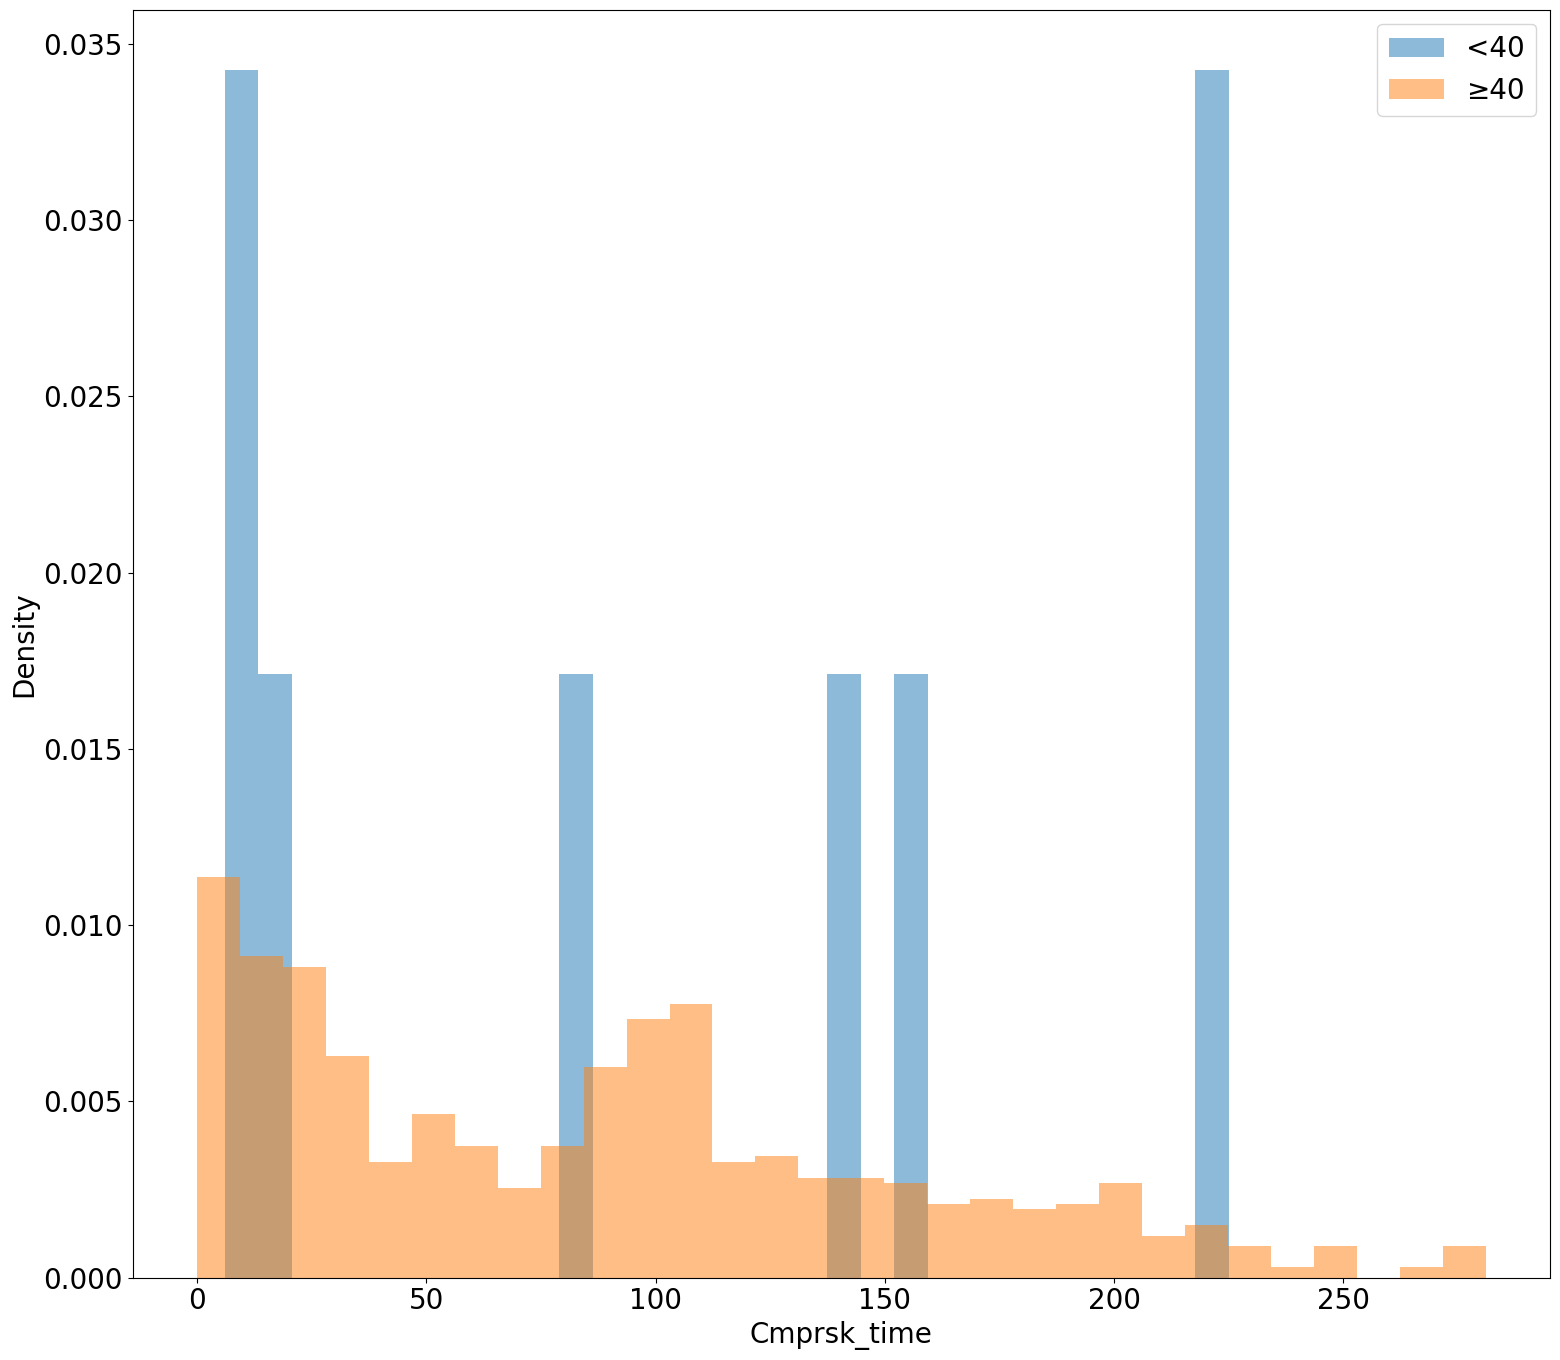

In [293]:
df2["age_grp"] = np.where(df2["age"] < 40, "<40", "≥40")

plt.figure()
for g in ["<40", "≥40"]:
    x = df2.loc[df2["age_grp"] == g, "Cmprsk_time"].dropna()
    plt.hist(x, bins=30, density=True, alpha=0.5, label=g)
plt.xlabel("Cmprsk_time"); plt.ylabel("Density"); plt.legend(); plt.tight_layout(); plt.show()

In [294]:
df2 = df2.drop(columns="age_grp")

### Basic demographic 

In [295]:
print(df2.columns.to_list())

['TMA_order', 'TMA_number', 'CSS_months_2020', 'UpdateJuly2020_a0_cd1_ncd2', 'neoadj1', 'Thirtyday_mortality_2017', 'c0r1', 'CMS_Raheleh_withoutlabels', 'DFS_months_2020', 'DFS_status_July2020', 'DateofLastFollowUp01072020', 'date_recurrence_01072020', 'MMR_Status_Jen', 'adj1', 'el0em1', 'dofsurg', 'dob', 'REC_n0_yes1', 'DFS_months', 'DFS_years', 'Vital_status_confirmed', 'Notes', 'PrimaryCOD', 'Recurrence_local1_distant2', 'Local_recurrenceKK', 'Distant_recurrenceKK', 'Recurrence_Location', 'Colin_full_recurrence_sites', 'Recurrence_code', 'operation', 'Date_of_scan', 'age', 'agecd', 'sex', 'Female', 'Male', 'Right0_Left1', 'Location', 'Dukes', 'tstage', 'nstage', 'mstage', 'Differentiation', 'Diffcd', 'Tumour_budding', 'TuPerf', 'MargInv', 'venousinv', 'Perineural_Inv', 'PeritInv', 'Petersen_Index', 'Petersen_Index_low0_high1', 'TSP_Pete', 'TSP_Pete_HL', 'KM_Pete', 'KM_Pete_HL', 'GMS_Pete', 'mGPS', 'NLR_gtr5', 'ASA_group', 'weight', 'height', 'BMI_code', 'BMIunder30', 'BMIover30Y1N0'

In [296]:
df2["sex"].value_counts(normalize=True) * 100

sex
1.0    55.263158
0.0    44.736842
Name: proportion, dtype: float64

In [297]:
df2["age"].mean()

np.float64(68.87673130193906)

In [298]:
# primary cancer location
df2["Location"].value_counts(dropna=False) / (len(df2["Location"])) * 100

Location
0.0    41.551247
1.0    33.240997
2.0    25.207756
Name: count, dtype: float64

In [299]:
# percentage of early on-set
sum(df2["age"] <= 50) / (len(df2["age"])) * 100

6.509695290858726

In [300]:
df2["el0em1"].value_counts(dropna=False) / (len(df2["el0em1"])) * 100

el0em1
0.0    89.612188
1.0    10.387812
Name: count, dtype: float64

In [301]:
df2["Thirtyday_mortality_2017"].value_counts(dropna=False) / (len(df2["Thirtyday_mortality_2017"])) * 100

Thirtyday_mortality_2017
0    99.030471
1     0.969529
Name: count, dtype: float64

In [302]:
df2["tstage"].value_counts(dropna=False) / (len(df2["tstage"])) * 100

tstage
3.0    55.955679
4.0    28.947368
2.0    10.664820
1.0     4.432133
Name: count, dtype: float64

In [303]:
df2["mstage"].value_counts(dropna=False)

mstage
0.0    722
Name: count, dtype: int64

Calculation of LN ratio 

In [304]:
## super important to calculate the ratio of limph nodes that are positive
df2["LNratio"] = np.where( df2["LNsample"] == 0, 0, (df2["LNmet"] / df2["LNsample"]).round(3))

# it might be actually not needed since it is already calculated as LNR

In [305]:
df2["Cmprsk_time"].mean()

np.float64(86.7590027700831)

### Variables for competing risks

Basically it is the same as the event indicator, but if they had recurrence, they are treated like if they died by other causes.
It requires the last follow up information recorded in "UpdateJuly2020_a0_cd1_ncd2", and the Disease free status information from "DFS_status_July2020".
If it has had recurrence meaning DFS_status_July == 1, then that is our event of interest now.

Recurrence/died of cancer = event of interest

Alive without recurrence = censor

Died of other causes without recurrece = competing event



In [306]:
df2["UpdateJuly2020_a0_cd1_ncd2"].isna().sum()

np.int64(0)

In [307]:
df2["DFS_status_July2020"].isna().sum()

np.int64(20)

There is Nan in both DFS and patient outcome, but not shared. Therefore we can repopulate one with the other. 

In [308]:
df2[df2["DFS_status_July2020"].isna() &  df2["UpdateJuly2020_a0_cd1_ncd2"].isna()]

,TMA_order,TMA_number,CSS_months_2020,UpdateJuly2020_a0_cd1_ncd2,neoadj1,Thirtyday_mortality_2017,c0r1,CMS_Raheleh_withoutlabels,DFS_months_2020,DFS_status_July2020,DateofLastFollowUp01072020,date_recurrence_01072020,MMR_Status_Jen,adj1,el0em1,dofsurg,dob,REC_n0_yes1,DFS_months,DFS_years,Vital_status_confirmed,Notes,PrimaryCOD,Recurrence_local1_distant2,Local_recurrenceKK,Distant_recurrenceKK,Recurrence_Location,Colin_full_recurrence_sites,Recurrence_code,operation,Date_of_scan,age,agecd,sex,Female,Male,Right0_Left1,Location,Dukes,tstage,nstage,mstage,Differentiation,Diffcd,Tumour_budding,TuPerf,MargInv,venousinv,Perineural_Inv,PeritInv,Petersen_Index,Petersen_Index_low0_high1,TSP_Pete,TSP_Pete_HL,KM_Pete,KM_Pete_HL,GMS_Pete,mGPS,NLR_gtr5,ASA_group,weight,height,BMI_code,BMIunder30,BMIover30Y1N0,Smoker_n0_ex1_curr2,smoker,cigsday,exsmoker,anysmoke,Pathology_Notes,LNmet,LNsample,less12nodes,Neut,lymph,precrp,crp_code,prealb,alb_code,Aspirin,NSAID,Statin,Metformin,Mucin,Neut_gtr75,NLR,LNR,LNR_code,Elastica_VI,Less_than_10,ASCO_high_risk,crp,pre_lymph,Local_distant_recurrenc,Lymphoid_aggregates,Germinal_centres,Graham_Appelman_CLR,Ueno_CLR,Ueno_CLR_1mmcutoff,Vayrynen_CLR,Vayrynen_CLR_0.38cutoff,IE_Lymphocytes,IE_lymphocytesHL,filter_$,ImageAnalysis_Ki67,Ki67_Code_30,PTPN12st_cd28.31,PTPN12_tum_cd40.09,PTPN12both_32.97,PTPN12_tum,PTPN12_stroma,PTPN12_both,IL6R_AK_186.64,S100A2_raw,S100A2_code,combined_tbs100,CD3_raw,CD3_code,CD3_FOXP3_raw,CD3_FOXP3_code,CD68_raw,CD68_code,combinedCD3CD68,raw_CXCL9_s,CXCL9_s_code,CXCL9_t_code,raw_CXCL10_s,CXCL10_s_code,CXCL10_t_code,Cyclind1_raw,cyclind1_code,KI67_t,KI67_tumour_code,CD163_Str,CD163_code,CD66b,CD66b_code,ratioCD163CD68,ratio_M2M1_code,IKKA_MM,IKK_Beta_MM,IKK_Beta_MM_42.79,IKK_AplusIKK_B,IKKA_IKKB_Ratio,STAT1_tumour_raw,STAT1_tumour_cutoff_BK,CD3FOXP3_raw,CD3FOXP3_n_code,Bcat_Cyto,Bcat_Cyto_Coded,Bcat_Nuc,Bcat_nuc_coded,Bcat_Mem,Bcat_mem_coded,Fascin_cyto,Fascin_cyto_coded,Ecad_cyto,Ecad_Mem,Ecad_cyto_coded,Ecad_mem_coded,Zeb_cyto_coded,Zeb_nuc,Zeb_nuc_coded,Twist_cyto,Twist_cyto_coded,Twist_nuc,Twist_nuc_coded,Snail_cyto,Snail_cyto_coded,Snailnuc,Snail_nuc_coded,SOX9_cyto,SOX9_cyto_coded,SOX9_nuc,SOX9_nuc_coded,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Cyto_67.51_coded,SMAD4_Nu_NS,SMAD4_Nu_6.91_coded,SMAD4_CytoNu_combined,twolines_SMAD4_Cyto_Nu_combined,SMAD4_Stroma_Cyto,SMAD4_Stroma_Cyto_4.94_coded,SMAD4_Stroma_Nu,SMAD4_Stroma_Nu_3.88_coded,SMAD4_Stroma_CytoNu_combined,Zeb1_cyto_IE_code,Zeb1_nuc_IE1_A,Zeb1_nuc_IE_code,Zeb1_cyto_IE_mc,Zeb1_cyto_IE_mc_code,Bud_histoscore_Zeb1_code,Bud_histoscore_zeb1_mc,Bud_histo_Zeb_mc_code,Cyto_budcohort_Zeb11_A,Cyto_budcohort_zeb1_code,Nuc_budcohort_zeb1,Nuc_budcohort_zeb1_code,Zeb1_cyto_IE,NPM1_GK,pSTAT3_705_UH,pSTAT3_UH_TC_198.01,pSTAT3_Tum_Bud_PM,pSTAT3_Tum_Bud_12,IL17RA_Abs_PresPM,DFS_months_test,CSS_months_test,Cmprsk_time,LNratio


How has the DFS been calculated? can we replicate it?

In [309]:
dfs_status = np.select(
    [
        (df["REC_n0_yes1"] == 1), # recurrence
        (df["UpdateJuly2020_a0_cd1_ncd2"] == 1), # cancer-specific death
        (df["UpdateJuly2020_a0_cd1_ncd2"] == 0) & (df["REC_n0_yes1"] == 0),  # alive, no recurrence
        (df["UpdateJuly2020_a0_cd1_ncd2"] == 2) & (df["REC_n0_yes1"] == 0),  # other-cause death, no recurrence
    ],
    [1, 1, 0, 2],
    default=np.nan
)

df2["DFS_status_test"] = dfs_status


In [310]:
df2[["UpdateJuly2020_a0_cd1_ncd2","REC_n0_yes1","DFS_status_test","DFS_status_July2020"]]

,UpdateJuly2020_a0_cd1_ncd2,REC_n0_yes1,DFS_status_test,DFS_status_July2020
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,1.0,1.0,1.0,1.0
3,2.0,0.0,2.0,2.0
4,0.0,0.0,0.0,0.0
...,...,...,...,...
780,0.0,0.0,0.0,0.0
781,2.0,0.0,2.0,2.0
783,2.0,0.0,2.0,2.0
784,2.0,0.0,2.0,2.0


The testing variable and the real one differ in few rows, mainly because of missing values. Those missing values are complete in the main patient outome definition `UpdateJuly2020_a0_cd1_ncd2`

In [311]:
df2.loc[df2["DFS_status_test"] != df2["DFS_status_July2020"], ["UpdateJuly2020_a0_cd1_ncd2", "DFS_status_test", "DFS_status_July2020", "DFS_months_2020", "CSS_months_2020", "REC_n0_yes1"]]


,UpdateJuly2020_a0_cd1_ncd2,DFS_status_test,DFS_status_July2020,DFS_months_2020,CSS_months_2020,REC_n0_yes1
300,1.0,1.0,NaN,NaN,1,0.0
407,1.0,1.0,NaN,NaN,43,NaN
417,2.0,NaN,NaN,NaN,2,NaN
421,1.0,1.0,NaN,NaN,20,NaN
452,1.0,1.0,NaN,NaN,7,NaN
457,2.0,NaN,NaN,NaN,31,NaN
467,1.0,1.0,NaN,NaN,61,NaN
475,2.0,NaN,NaN,NaN,50,NaN
476,2.0,NaN,NaN,NaN,79,NaN
480,1.0,1.0,NaN,NaN,26,NaN


We can then easily use to compute the competing risk status variable the `UpdateJuly2020_a0_cd1_ncd2` and adjust with DFS. 

In [312]:
df2["Cmprsk_Status"] = df2["UpdateJuly2020_a0_cd1_ncd2"]
df2["Cmprsk_Status"] = np.where(df2["DFS_status_July2020"] == 1, 1,  df2["Cmprsk_Status"])

In [313]:
mask = df2["Cmprsk_Status"].isna()

df2[mask]

,TMA_order,TMA_number,CSS_months_2020,UpdateJuly2020_a0_cd1_ncd2,neoadj1,Thirtyday_mortality_2017,c0r1,CMS_Raheleh_withoutlabels,DFS_months_2020,DFS_status_July2020,DateofLastFollowUp01072020,date_recurrence_01072020,MMR_Status_Jen,adj1,el0em1,dofsurg,dob,REC_n0_yes1,DFS_months,DFS_years,Vital_status_confirmed,Notes,PrimaryCOD,Recurrence_local1_distant2,Local_recurrenceKK,Distant_recurrenceKK,Recurrence_Location,Colin_full_recurrence_sites,Recurrence_code,operation,Date_of_scan,age,agecd,sex,Female,Male,Right0_Left1,Location,Dukes,tstage,nstage,mstage,Differentiation,Diffcd,Tumour_budding,TuPerf,MargInv,venousinv,Perineural_Inv,PeritInv,Petersen_Index,Petersen_Index_low0_high1,TSP_Pete,TSP_Pete_HL,KM_Pete,KM_Pete_HL,GMS_Pete,mGPS,NLR_gtr5,ASA_group,weight,height,BMI_code,BMIunder30,BMIover30Y1N0,Smoker_n0_ex1_curr2,smoker,cigsday,exsmoker,anysmoke,Pathology_Notes,LNmet,LNsample,less12nodes,Neut,lymph,precrp,crp_code,prealb,alb_code,Aspirin,NSAID,Statin,Metformin,Mucin,Neut_gtr75,NLR,LNR,LNR_code,Elastica_VI,Less_than_10,ASCO_high_risk,crp,pre_lymph,Local_distant_recurrenc,Lymphoid_aggregates,Germinal_centres,Graham_Appelman_CLR,Ueno_CLR,Ueno_CLR_1mmcutoff,Vayrynen_CLR,Vayrynen_CLR_0.38cutoff,IE_Lymphocytes,IE_lymphocytesHL,filter_$,ImageAnalysis_Ki67,Ki67_Code_30,PTPN12st_cd28.31,PTPN12_tum_cd40.09,PTPN12both_32.97,PTPN12_tum,PTPN12_stroma,PTPN12_both,IL6R_AK_186.64,S100A2_raw,S100A2_code,combined_tbs100,CD3_raw,CD3_code,CD3_FOXP3_raw,CD3_FOXP3_code,CD68_raw,CD68_code,combinedCD3CD68,raw_CXCL9_s,CXCL9_s_code,CXCL9_t_code,raw_CXCL10_s,CXCL10_s_code,CXCL10_t_code,Cyclind1_raw,cyclind1_code,KI67_t,KI67_tumour_code,CD163_Str,CD163_code,CD66b,CD66b_code,ratioCD163CD68,ratio_M2M1_code,IKKA_MM,IKK_Beta_MM,IKK_Beta_MM_42.79,IKK_AplusIKK_B,IKKA_IKKB_Ratio,STAT1_tumour_raw,STAT1_tumour_cutoff_BK,CD3FOXP3_raw,CD3FOXP3_n_code,Bcat_Cyto,Bcat_Cyto_Coded,Bcat_Nuc,Bcat_nuc_coded,Bcat_Mem,Bcat_mem_coded,Fascin_cyto,Fascin_cyto_coded,Ecad_cyto,Ecad_Mem,Ecad_cyto_coded,Ecad_mem_coded,Zeb_cyto_coded,Zeb_nuc,Zeb_nuc_coded,Twist_cyto,Twist_cyto_coded,Twist_nuc,Twist_nuc_coded,Snail_cyto,Snail_cyto_coded,Snailnuc,Snail_nuc_coded,SOX9_cyto,SOX9_cyto_coded,SOX9_nuc,SOX9_nuc_coded,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Cyto_67.51_coded,SMAD4_Nu_NS,SMAD4_Nu_6.91_coded,SMAD4_CytoNu_combined,twolines_SMAD4_Cyto_Nu_combined,SMAD4_Stroma_Cyto,SMAD4_Stroma_Cyto_4.94_coded,SMAD4_Stroma_Nu,SMAD4_Stroma_Nu_3.88_coded,SMAD4_Stroma_CytoNu_combined,Zeb1_cyto_IE_code,Zeb1_nuc_IE1_A,Zeb1_nuc_IE_code,Zeb1_cyto_IE_mc,Zeb1_cyto_IE_mc_code,Bud_histoscore_Zeb1_code,Bud_histoscore_zeb1_mc,Bud_histo_Zeb_mc_code,Cyto_budcohort_Zeb11_A,Cyto_budcohort_zeb1_code,Nuc_budcohort_zeb1,Nuc_budcohort_zeb1_code,Zeb1_cyto_IE,NPM1_GK,pSTAT3_705_UH,pSTAT3_UH_TC_198.01,pSTAT3_Tum_Bud_PM,pSTAT3_Tum_Bud_12,IL17RA_Abs_PresPM,DFS_months_test,CSS_months_test,Cmprsk_time,LNratio,DFS_status_test,Cmprsk_Status


Drop if there is no outcome recorded, and therefore no cmprsk status


In [314]:
time, status = "Cmprsk_time", "Cmprsk_Status"

print(df2[[time, status]].isna().sum())

# drop if we do not know any of these two:
df2 = df2.dropna(subset=[time, status])


Cmprsk_time      0
Cmprsk_Status    0
dtype: int64


In [315]:
df2["Cmprsk_Status"].value_counts(normalize=True) * 100

Cmprsk_Status
2.0    35.041551
1.0    32.686981
0.0    32.271468
Name: proportion, dtype: float64

In [316]:
df2["UpdateJuly2020_a0_cd1_ncd2"].value_counts(normalize=True) * 100

UpdateJuly2020_a0_cd1_ncd2
2.0    36.980609
0.0    34.349030
1.0    28.670360
Name: proportion, dtype: float64

In [317]:
df2["REC_n0_yes1"].value_counts(normalize=True) * 100

REC_n0_yes1
0.0    69.024045
1.0    30.975955
Name: proportion, dtype: float64

In [318]:
df2["REC_n0_yes1"].value_counts(dropna=False)

REC_n0_yes1
0.0    488
1.0    219
NaN     15
Name: count, dtype: int64

In [319]:
df2.loc[df2["REC_n0_yes1"].isna(), ]

,TMA_order,TMA_number,CSS_months_2020,UpdateJuly2020_a0_cd1_ncd2,neoadj1,Thirtyday_mortality_2017,c0r1,CMS_Raheleh_withoutlabels,DFS_months_2020,DFS_status_July2020,DateofLastFollowUp01072020,date_recurrence_01072020,MMR_Status_Jen,adj1,el0em1,dofsurg,dob,REC_n0_yes1,DFS_months,DFS_years,Vital_status_confirmed,Notes,PrimaryCOD,Recurrence_local1_distant2,Local_recurrenceKK,Distant_recurrenceKK,Recurrence_Location,Colin_full_recurrence_sites,Recurrence_code,operation,Date_of_scan,age,agecd,sex,Female,Male,Right0_Left1,Location,Dukes,tstage,nstage,mstage,Differentiation,Diffcd,Tumour_budding,TuPerf,MargInv,venousinv,Perineural_Inv,PeritInv,Petersen_Index,Petersen_Index_low0_high1,TSP_Pete,TSP_Pete_HL,KM_Pete,KM_Pete_HL,GMS_Pete,mGPS,NLR_gtr5,ASA_group,weight,height,BMI_code,BMIunder30,BMIover30Y1N0,Smoker_n0_ex1_curr2,smoker,cigsday,exsmoker,anysmoke,Pathology_Notes,LNmet,LNsample,less12nodes,Neut,lymph,precrp,crp_code,prealb,alb_code,Aspirin,NSAID,Statin,Metformin,Mucin,Neut_gtr75,NLR,LNR,LNR_code,Elastica_VI,Less_than_10,ASCO_high_risk,crp,pre_lymph,Local_distant_recurrenc,Lymphoid_aggregates,Germinal_centres,Graham_Appelman_CLR,Ueno_CLR,Ueno_CLR_1mmcutoff,Vayrynen_CLR,Vayrynen_CLR_0.38cutoff,IE_Lymphocytes,IE_lymphocytesHL,filter_$,ImageAnalysis_Ki67,Ki67_Code_30,PTPN12st_cd28.31,PTPN12_tum_cd40.09,PTPN12both_32.97,PTPN12_tum,PTPN12_stroma,PTPN12_both,IL6R_AK_186.64,S100A2_raw,S100A2_code,combined_tbs100,CD3_raw,CD3_code,CD3_FOXP3_raw,CD3_FOXP3_code,CD68_raw,CD68_code,combinedCD3CD68,raw_CXCL9_s,CXCL9_s_code,CXCL9_t_code,raw_CXCL10_s,CXCL10_s_code,CXCL10_t_code,Cyclind1_raw,cyclind1_code,KI67_t,KI67_tumour_code,CD163_Str,CD163_code,CD66b,CD66b_code,ratioCD163CD68,ratio_M2M1_code,IKKA_MM,IKK_Beta_MM,IKK_Beta_MM_42.79,IKK_AplusIKK_B,IKKA_IKKB_Ratio,STAT1_tumour_raw,STAT1_tumour_cutoff_BK,CD3FOXP3_raw,CD3FOXP3_n_code,Bcat_Cyto,Bcat_Cyto_Coded,Bcat_Nuc,Bcat_nuc_coded,Bcat_Mem,Bcat_mem_coded,Fascin_cyto,Fascin_cyto_coded,Ecad_cyto,Ecad_Mem,Ecad_cyto_coded,Ecad_mem_coded,Zeb_cyto_coded,Zeb_nuc,Zeb_nuc_coded,Twist_cyto,Twist_cyto_coded,Twist_nuc,Twist_nuc_coded,Snail_cyto,Snail_cyto_coded,Snailnuc,Snail_nuc_coded,SOX9_cyto,SOX9_cyto_coded,SOX9_nuc,SOX9_nuc_coded,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Cyto_67.51_coded,SMAD4_Nu_NS,SMAD4_Nu_6.91_coded,SMAD4_CytoNu_combined,twolines_SMAD4_Cyto_Nu_combined,SMAD4_Stroma_Cyto,SMAD4_Stroma_Cyto_4.94_coded,SMAD4_Stroma_Nu,SMAD4_Stroma_Nu_3.88_coded,SMAD4_Stroma_CytoNu_combined,Zeb1_cyto_IE_code,Zeb1_nuc_IE1_A,Zeb1_nuc_IE_code,Zeb1_cyto_IE_mc,Zeb1_cyto_IE_mc_code,Bud_histoscore_Zeb1_code,Bud_histoscore_zeb1_mc,Bud_histo_Zeb_mc_code,Cyto_budcohort_Zeb11_A,Cyto_budcohort_zeb1_code,Nuc_budcohort_zeb1,Nuc_budcohort_zeb1_code,Zeb1_cyto_IE,NPM1_GK,pSTAT3_705_UH,pSTAT3_UH_TC_198.01,pSTAT3_Tum_Bud_PM,pSTAT3_Tum_Bud_12,IL17RA_Abs_PresPM,DFS_months_test,CSS_months_test,Cmprsk_time,LNratio,DFS_status_test,Cmprsk_Status
407,408,TMA3,43,1.0,0.0,0,0.0,2.0,NaN,NaN,2000-10-24,NaT,2.0,0.0,0.0,1997-03-07,1907-07-31,NaN,NaN,NaN,NaN,NaN,C260,NaN,NaN,NaN,NaN,NaN,NaN,LEFT,NaT,89.0,2.0,0.0,NaN,NaN,1.0,1.0,2.0,3.0,0.0,0.0,mod,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,30.0,0.0,0.0,0.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,8.0,1.0,16.4,0.5,51.0,1.0,27.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,32.80,0.00,0.0,1.0,1.0,1.0,5.1,500.0,NaN,4.0,0.0,1.0,0.71,0.0,0.31,0.0,0.2,0.0,1.0,9.19,0.0,0,0,0,35.72,13.98,29.18,0.0,105.0,1.0,1.0,3.88,1.0,0.23,0.0,4.63,0.0,2.0,1.57,0.0,1.0,0.89,0.0,0.0,120.00,1.0,25.63,1.0,2.64,0.0,3.38,1.0,0.57,0.0,NaN,34.20,0.0,NaN,NaN,106.74,1.0,20.00,1.0,108.0,0.0,0.0,0.0,101.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,121.0,1.0,163.0,1.0,117.0,0.0,143.0,0.0,104.0,1.0,108.0,1.0,224.0,0.0,258.0,0.0,0.00,0.0,0.15,0.0,0.0,0.0,0.00,0.0,0.16,0.0,0.0,NaN,142.5,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113.62,161.51,0.0,1.93,0.0,0.0,NaN,43.597536,44.0,0.000,1.0,1.0
417,418,TMA3,2,2.0,0.0,0,0.0,NaN,NaN,NaN,1997-09-04,NaT,3.0,0.0,0.0,1997-06-24,1920-06-28,NaN,NaN,NaN,NaN,NaN,4151,NaN,NaN,NaN,NaN,NaN,NaN,NAN,NaT,76.0,2.0,0.0,Na

In [320]:
df2.loc[df2["REC_n0_yes1"] == 0, "DFS_months_2020"].mean()

np.float64(114.16977225672878)

In [321]:
df2.loc[df2["REC_n0_yes1"] == 1, "DFS_months_2020"].mean()

np.float64(30.136986301369863)

It is not easy to define the event of interest, since we have cases where they might have died of other causes but they have had recurrence as well. 
Since we are primarily interested in recurrence, we have to prioritize it. Therefore, if it has had recurrence, we would assign it the event of interest regardless of the other cause of death.

Some examples where the overall status, does not correspond with the disease free status:


In [322]:
mask = df2["UpdateJuly2020_a0_cd1_ncd2"] != df2["DFS_status_July2020"]
df2.loc[mask, ["UpdateJuly2020_a0_cd1_ncd2", "DFS_status_July2020", "REC_n0_yes1", "Cmprsk_Status"]]

,UpdateJuly2020_a0_cd1_ncd2,DFS_status_July2020,REC_n0_yes1,Cmprsk_Status
45,0.0,1.0,1.0,1.0
52,0.0,1.0,1.0,1.0
58,2.0,1.0,1.0,1.0
71,0.0,1.0,1.0,1.0
78,0.0,1.0,1.0,1.0
81,0.0,1.0,1.0,1.0
103,0.0,1.0,1.0,1.0
131,0.0,1.0,1.0,1.0
146,0.0,1.0,1.0,1.0
147,2.0,1.0,1.0,1.0


In [323]:
df2

,TMA_order,TMA_number,CSS_months_2020,UpdateJuly2020_a0_cd1_ncd2,neoadj1,Thirtyday_mortality_2017,c0r1,CMS_Raheleh_withoutlabels,DFS_months_2020,DFS_status_July2020,DateofLastFollowUp01072020,date_recurrence_01072020,MMR_Status_Jen,adj1,el0em1,dofsurg,dob,REC_n0_yes1,DFS_months,DFS_years,Vital_status_confirmed,Notes,PrimaryCOD,Recurrence_local1_distant2,Local_recurrenceKK,Distant_recurrenceKK,Recurrence_Location,Colin_full_recurrence_sites,Recurrence_code,operation,Date_of_scan,age,agecd,sex,Female,Male,Right0_Left1,Location,Dukes,tstage,nstage,mstage,Differentiation,Diffcd,Tumour_budding,TuPerf,MargInv,venousinv,Perineural_Inv,PeritInv,Petersen_Index,Petersen_Index_low0_high1,TSP_Pete,TSP_Pete_HL,KM_Pete,KM_Pete_HL,GMS_Pete,mGPS,NLR_gtr5,ASA_group,weight,height,BMI_code,BMIunder30,BMIover30Y1N0,Smoker_n0_ex1_curr2,smoker,cigsday,exsmoker,anysmoke,Pathology_Notes,LNmet,LNsample,less12nodes,Neut,lymph,precrp,crp_code,prealb,alb_code,Aspirin,NSAID,Statin,Metformin,Mucin,Neut_gtr75,NLR,LNR,LNR_code,Elastica_VI,Less_than_10,ASCO_high_risk,crp,pre_lymph,Local_distant_recurrenc,Lymphoid_aggregates,Germinal_centres,Graham_Appelman_CLR,Ueno_CLR,Ueno_CLR_1mmcutoff,Vayrynen_CLR,Vayrynen_CLR_0.38cutoff,IE_Lymphocytes,IE_lymphocytesHL,filter_$,ImageAnalysis_Ki67,Ki67_Code_30,PTPN12st_cd28.31,PTPN12_tum_cd40.09,PTPN12both_32.97,PTPN12_tum,PTPN12_stroma,PTPN12_both,IL6R_AK_186.64,S100A2_raw,S100A2_code,combined_tbs100,CD3_raw,CD3_code,CD3_FOXP3_raw,CD3_FOXP3_code,CD68_raw,CD68_code,combinedCD3CD68,raw_CXCL9_s,CXCL9_s_code,CXCL9_t_code,raw_CXCL10_s,CXCL10_s_code,CXCL10_t_code,Cyclind1_raw,cyclind1_code,KI67_t,KI67_tumour_code,CD163_Str,CD163_code,CD66b,CD66b_code,ratioCD163CD68,ratio_M2M1_code,IKKA_MM,IKK_Beta_MM,IKK_Beta_MM_42.79,IKK_AplusIKK_B,IKKA_IKKB_Ratio,STAT1_tumour_raw,STAT1_tumour_cutoff_BK,CD3FOXP3_raw,CD3FOXP3_n_code,Bcat_Cyto,Bcat_Cyto_Coded,Bcat_Nuc,Bcat_nuc_coded,Bcat_Mem,Bcat_mem_coded,Fascin_cyto,Fascin_cyto_coded,Ecad_cyto,Ecad_Mem,Ecad_cyto_coded,Ecad_mem_coded,Zeb_cyto_coded,Zeb_nuc,Zeb_nuc_coded,Twist_cyto,Twist_cyto_coded,Twist_nuc,Twist_nuc_coded,Snail_cyto,Snail_cyto_coded,Snailnuc,Snail_nuc_coded,SOX9_cyto,SOX9_cyto_coded,SOX9_nuc,SOX9_nuc_coded,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Cyto_67.51_coded,SMAD4_Nu_NS,SMAD4_Nu_6.91_coded,SMAD4_CytoNu_combined,twolines_SMAD4_Cyto_Nu_combined,SMAD4_Stroma_Cyto,SMAD4_Stroma_Cyto_4.94_coded,SMAD4_Stroma_Nu,SMAD4_Stroma_Nu_3.88_coded,SMAD4_Stroma_CytoNu_combined,Zeb1_cyto_IE_code,Zeb1_nuc_IE1_A,Zeb1_nuc_IE_code,Zeb1_cyto_IE_mc,Zeb1_cyto_IE_mc_code,Bud_histoscore_Zeb1_code,Bud_histoscore_zeb1_mc,Bud_histo_Zeb_mc_code,Cyto_budcohort_Zeb11_A,Cyto_budcohort_zeb1_code,Nuc_budcohort_zeb1,Nuc_budcohort_zeb1_code,Zeb1_cyto_IE,NPM1_GK,pSTAT3_705_UH,pSTAT3_UH_TC_198.01,pSTAT3_Tum_Bud_PM,pSTAT3_Tum_Bud_12,IL17RA_Abs_PresPM,DFS_months_test,CSS_months_test,Cmprsk_time,LNratio,DFS_status_test,Cmprsk_Status
0,1,TMA1,97,0.0,0.0,0,0.0,3.0,97.0,0.0,2020-07-01,2020-07-01,1.0,0.0,0.0,2012-05-22,1945-03-01,0.0,NaN,NaN,NaN,right and caecum,NaN,0.0,0.0,0.0,NaN,0.0,0.0,SUBTOTAL,2012-05-11,67.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,3.0,0.0,0.0,mod,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,2.0,1.0,0.0,1.0,0.0,2.0,86.0,1.73,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Synch tumours,0.0,35.0,0.0,6.3,1.6,11.0,1.0,35.0,0.0,NaN,NaN,NaN,NaN,1.0,0.0,3.94,0.00,0.0,1.0,0.0,0.0,1.10,1600.0,NaN,13.0,4.0,2.0,0.81,0.0,0.69,1.0,1.6,0.0,1.0,7.02,0.0,1,1,1,49.49,31.21,37.93,0.0,103.0,1.0,1.0,5.63,1.0,2.17,1.0,5.07,0.0,2.0,0.21,0.0,1.0,0.35,0.0,0.0,65.00,0.0,25.81,1.0,14.27,1.0,0.86,0.0,2.82,0.0,118.25,1.26,0.0,119.51,2.07,121.45,1.0,29.33,1.0,141.0,1.0,23.0,0.0,137.0,1.0,23.0,1.0,NaN,285.0,NaN,1.0,122.0,1.0,179.0,1.0,127.0,0.0,167.0,0.0,111.0,0.0,136.0,0.0,175.0,0.0,240.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.62,1.0,82.42,0.0,101.62,1.0,135.82,3.67,0.0,NaN,NaN,NaN,97.314168,97.314168,97.0,0.000,0.0,0.0
1,2,TMA1,97,0.0,0.0,0,0.0,NaN,97.0,0.0,2020-07-01,2020-07-01,NaN,0.0,0.0,2012-05-23,1933-12-27,0.0,NaN


# Quality Performance Indicators (QPIs)
## Colorectal cancer quality performance indicator (QPI) documentation

https://publichealthscotland.scot/population-health/conditions-and-diseases/cancer/cancer-quality-performance-indicators-qpis/quality-performance-indicators-qpis/qpi-documentation/


https://publichealthscotland.scot/publications/colorectal-cancer-quality-performance-indicator-qpi-documentation/colorectal-cancer-quality-performance-indicator-qpi-documentation-1-april-2021-onwards/

01 May 2023 (Latest release)

National cancer quality performance indicators have been developed to support continuous quality improvement in cancer care (CEL 06 2012). NHS Boards are required to report these indicators against a clinically agreed indicator specific target as part of the mandatory national cancer quality programme. They have been developed collaboratively by North Cancer Alliance, South East Scotland Cancer Network, West of Scotland Cancer Network, Healthcare Improvement Scotland and PHS.

They are recorded to evaluate if patients with colorectal cancer are receiving a high standard of care. 

| **Field Name** | **Description**                                             | **Required for QPI(s)**              |
| -------------- | ----------------------------------------------------------- | ------------------------------------ |
| DATEIMAGELB    | Date of Imaging Large Bowel                                 | QPI 2                                |
| DIAGDATE       | Date of Diagnosis (Cancer)                                  | QPI 1, 2, 5, 7, 8, 9, 10, 11, 12, 16 |
| SITEPRIM       | Site of Origin of Primary Tumour (Cancer)                   | QPI 1, 7                             |
| FINSURGDATE    | Date of Final Definitive (or Only) Surgery                  | QPI 2, 7, 10, 11                     |
| PRESENT        | Presentation Type (Elective/Emergency)                      | QPI 1, 2, 7, 10                      |
| OPINTENT       | Intent of Surgery (Curative/Palliative)                     | QPI 1, 2, 5                          |
| REOPER         | Re-operation after definitive surgery                       | QPI 8                                |
| ANASLEAK       | Anastomotic Leak after surgery                              | QPI 9                                |
| CIRCMARGIN     | Circumferential Margin Involved (surgical specimen)         | QPI 7                                |
| LNEXAMINE      | Final Total Number of Lymph Nodes Examined                  | QPI 5                                |
| FINALN         | TNM Nodal Classification (Final)                            | QPI 11                               |
| FINALT         | TNM Tumour Classification (Final)                           | QPI 11                               |
| FINALM         | TNM Metastasis Classification (Final)                       | QPI 11                               |
| NEOONC         | Neo-Adjuvant Oncology Treatment Type                        | QPI 11                               |
| ADJONC         | Primary/Palliative/Adjuvant Oncology Treatment Type         | QPI 1                                |
| ADJONC\_DATE   | Date Primary/Palliative/Adjuvant Oncology Treatment Started | QPI 11                               |
| LIVERDIAGDATE  | Date of Liver Imaging confirming liver mets                 | QPI 15                               |
| HPBMDT         | Referral to HPB MDT (liver mets patients)                   | QPI 15                               |
| BRAF           | BRAF mutation status                                        | QPI 16                               |
| MSISTATUS      | Microsatellite Instability (MSI) Status                     | QPI 16                               |
| IHCSTATUS      | Mismatch Repair (MMR IHC)                                   | QPI 16                               |
| GENETICS       | Genetics Referral                                           | QPI 16                               |
| TRIAL          | Patient entered into Clinical Trial                         | Generic QPIs                         |

The QPI's names are the following:

| **QPI** | **Name**                                                      |
| ------- | ------------------------------------------------------------- |
| QPI 1   | Radiological Diagnosis of Colorectal Cancer                   |
| QPI 2   | Pre-operative Imaging of Colon                                |
| QPI 3   | *Retired* (Staging Laparoscopy – removed in earlier versions) |
| QPI 4   | Pre-operative MRI in Rectal Cancer                            |
| QPI 5   | Lymph Node Yield                                              |
| QPI 6   | Pre-operative Radiotherapy in Rectal Cancer                   |
| QPI 7   | Clear Surgical Margins                                        |
| QPI 8   | Re-operation                                                  |
| QPI 9   | Anastomotic Leak                                              |
| QPI 10  | Emergency Surgery                                             |
| QPI 11  | Pathological Staging                                          |
| QPI 12  | Adjuvant Chemotherapy in Stage III Colon Cancer               |
| QPI 13  | Adjuvant Radiotherapy in Rectal Cancer                        |
| QPI 14  | Adjuvant Chemotherapy in Rectal Cancer                        |
| QPI 15  | Imaging for Liver Metastases                                  |
| QPI 16  | Molecular Pathological Markers                                |

In our dataset we have lots of more variables, some of them can be understood as extenstion of the standard QPI's. For instance the GRI contains more genertic and pathology variables, which in the future could be converted into the standard practise.


In our dataset:

| **GRI column**            | **QPI dataset variable**                    | **QPI No.**                         | **QPI Name**                                                                     |
| ---------------------------------- | ------------------------------------------- | ----------------------------------- | -------------------------------------------------------------------------------- |
| `UpdateJuly2020_a0_cd1_ncd2`       | Treatment update / recurrence status fields | QPI 12                              | Adjuvant Chemotherapy in Stage III Colon Cancer                                  |
| `Thirtyday_mortality_2017`         | 30-day mortality (audit item, not a QPI)    | –                                   | –                                                                                |
| `MMR_Status_Jen`                   | `MSISTATUS` / `IHCSTATUS`                   | QPI 16                              | Molecular Pathological Markers                                                   |
| `BRAF`                   | `BRAF`                   | QPI 16                              | Molecular Pathological Markers                                                   |
| `dofsurg` (date of surgery)        | `FINSURGDATE`                               | QPI 2, 7, 10, 11                    | Definitive Surgery / Surgical Margins / Emergency Surgery / Pathological Staging |
| `operation`                        | `OPINTENT`                                  | QPI 1, 2, 5                         | Surgical Intent (Curative/Palliative)                                            |
| `sex` / `Female` / `Male`          | `SEX`                                       | Background (not QPI)                | –                                                                                |
| `Location` / `Right0_Left1`        | `SITEPRIM`                                  | QPI 1, 7                            | Radiological Diagnosis / Clear Surgical Margins                                  |
| `tstage` / `nstage` / `mstage`     | `FINALT` / `FINALN` / `FINALM`              | QPI 11                              | Pathological Staging                                                             |
| `Differentiation`                  | `DIFFERENT` (if present)                      | Not core QPI (but pathology detail) | –                                                                                |
| `LNratio` | `LNEXAMINE`                                 | QPI 5                               | Lymph Node Yield                                                                 |
| `MargInv`                          | `CIRCMARGIN`                                | QPI 7                               | Clear Surgical Margins                                                           |
| `Recurrence_local1_distant2`       | Recurrence coding                           | QPI 12–14                           | Adjuvant therapy follow-up                                                       |
| `PrimaryCOD`                       | Cause of death                              | Background (not QPI)                | –                                           |


Additionally we have the BRAF mutation status.

Lots of recurrence and competing risk status do not appear in the QPI's but they are quite useful


Regarding the genetics or QPI 16, we miss MLH1 in GRI. Overall QPI miss lots of important variables like tumor budding etc. 


Let's add the mutation data

In [324]:
mutations = pd.read_excel("data/Mutations_GRI.xlsx", na_values=["NaN", "nan", "NA", "NAN"])

mutations

,TMA_order,BRAF,KRAS,NRAS
0,1,0.0,0.0,0.0
1,2,0.0,1.0,0.0
2,3,0.0,1.0,0.0
3,4,0.0,0.0,1.0
4,5,0.0,1.0,1.0
...,...,...,...,...
782,783,NaN,NaN,NaN
783,784,0.0,1.0,1.0
784,785,0.0,1.0,1.0
785,786,0.0,0.0,0.0


In [325]:
df3 = df2.merge(mutations, on="TMA_order") 

In [326]:
df3.to_csv("data/GRI_preprocess-1.csv")

In [327]:
df3

,TMA_order,TMA_number,CSS_months_2020,UpdateJuly2020_a0_cd1_ncd2,neoadj1,Thirtyday_mortality_2017,c0r1,CMS_Raheleh_withoutlabels,DFS_months_2020,DFS_status_July2020,DateofLastFollowUp01072020,date_recurrence_01072020,MMR_Status_Jen,adj1,el0em1,dofsurg,dob,REC_n0_yes1,DFS_months,DFS_years,Vital_status_confirmed,Notes,PrimaryCOD,Recurrence_local1_distant2,Local_recurrenceKK,Distant_recurrenceKK,Recurrence_Location,Colin_full_recurrence_sites,Recurrence_code,operation,Date_of_scan,age,agecd,sex,Female,Male,Right0_Left1,Location,Dukes,tstage,nstage,mstage,Differentiation,Diffcd,Tumour_budding,TuPerf,MargInv,venousinv,Perineural_Inv,PeritInv,Petersen_Index,Petersen_Index_low0_high1,TSP_Pete,TSP_Pete_HL,KM_Pete,KM_Pete_HL,GMS_Pete,mGPS,NLR_gtr5,ASA_group,weight,height,BMI_code,BMIunder30,BMIover30Y1N0,Smoker_n0_ex1_curr2,smoker,cigsday,exsmoker,anysmoke,Pathology_Notes,LNmet,LNsample,less12nodes,Neut,lymph,precrp,crp_code,prealb,alb_code,Aspirin,NSAID,Statin,Metformin,Mucin,Neut_gtr75,NLR,LNR,LNR_code,Elastica_VI,Less_than_10,ASCO_high_risk,crp,pre_lymph,Local_distant_recurrenc,Lymphoid_aggregates,Germinal_centres,Graham_Appelman_CLR,Ueno_CLR,Ueno_CLR_1mmcutoff,Vayrynen_CLR,Vayrynen_CLR_0.38cutoff,IE_Lymphocytes,IE_lymphocytesHL,filter_$,ImageAnalysis_Ki67,Ki67_Code_30,PTPN12st_cd28.31,PTPN12_tum_cd40.09,PTPN12both_32.97,PTPN12_tum,PTPN12_stroma,PTPN12_both,IL6R_AK_186.64,S100A2_raw,S100A2_code,combined_tbs100,CD3_raw,CD3_code,CD3_FOXP3_raw,CD3_FOXP3_code,CD68_raw,CD68_code,combinedCD3CD68,raw_CXCL9_s,CXCL9_s_code,CXCL9_t_code,raw_CXCL10_s,CXCL10_s_code,CXCL10_t_code,Cyclind1_raw,cyclind1_code,KI67_t,KI67_tumour_code,CD163_Str,CD163_code,CD66b,CD66b_code,ratioCD163CD68,ratio_M2M1_code,IKKA_MM,IKK_Beta_MM,IKK_Beta_MM_42.79,IKK_AplusIKK_B,IKKA_IKKB_Ratio,STAT1_tumour_raw,STAT1_tumour_cutoff_BK,CD3FOXP3_raw,CD3FOXP3_n_code,Bcat_Cyto,Bcat_Cyto_Coded,Bcat_Nuc,Bcat_nuc_coded,Bcat_Mem,Bcat_mem_coded,Fascin_cyto,Fascin_cyto_coded,Ecad_cyto,Ecad_Mem,Ecad_cyto_coded,Ecad_mem_coded,Zeb_cyto_coded,Zeb_nuc,Zeb_nuc_coded,Twist_cyto,Twist_cyto_coded,Twist_nuc,Twist_nuc_coded,Snail_cyto,Snail_cyto_coded,Snailnuc,Snail_nuc_coded,SOX9_cyto,SOX9_cyto_coded,SOX9_nuc,SOX9_nuc_coded,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Cyto_67.51_coded,SMAD4_Nu_NS,SMAD4_Nu_6.91_coded,SMAD4_CytoNu_combined,twolines_SMAD4_Cyto_Nu_combined,SMAD4_Stroma_Cyto,SMAD4_Stroma_Cyto_4.94_coded,SMAD4_Stroma_Nu,SMAD4_Stroma_Nu_3.88_coded,SMAD4_Stroma_CytoNu_combined,Zeb1_cyto_IE_code,Zeb1_nuc_IE1_A,Zeb1_nuc_IE_code,Zeb1_cyto_IE_mc,Zeb1_cyto_IE_mc_code,Bud_histoscore_Zeb1_code,Bud_histoscore_zeb1_mc,Bud_histo_Zeb_mc_code,Cyto_budcohort_Zeb11_A,Cyto_budcohort_zeb1_code,Nuc_budcohort_zeb1,Nuc_budcohort_zeb1_code,Zeb1_cyto_IE,NPM1_GK,pSTAT3_705_UH,pSTAT3_UH_TC_198.01,pSTAT3_Tum_Bud_PM,pSTAT3_Tum_Bud_12,IL17RA_Abs_PresPM,DFS_months_test,CSS_months_test,Cmprsk_time,LNratio,DFS_status_test,Cmprsk_Status,BRAF,KRAS,NRAS
0,1,TMA1,97,0.0,0.0,0,0.0,3.0,97.0,0.0,2020-07-01,2020-07-01,1.0,0.0,0.0,2012-05-22,1945-03-01,0.0,NaN,NaN,NaN,right and caecum,NaN,0.0,0.0,0.0,NaN,0.0,0.0,SUBTOTAL,2012-05-11,67.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,3.0,0.0,0.0,mod,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,2.0,1.0,0.0,1.0,0.0,2.0,86.0,1.73,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Synch tumours,0.0,35.0,0.0,6.3,1.6,11.0,1.0,35.0,0.0,NaN,NaN,NaN,NaN,1.0,0.0,3.94,0.00,0.0,1.0,0.0,0.0,1.10,1600.0,NaN,13.0,4.0,2.0,0.81,0.0,0.69,1.0,1.6,0.0,1.0,7.02,0.0,1,1,1,49.49,31.21,37.93,0.0,103.0,1.0,1.0,5.63,1.0,2.17,1.0,5.07,0.0,2.0,0.21,0.0,1.0,0.35,0.0,0.0,65.00,0.0,25.81,1.0,14.27,1.0,0.86,0.0,2.82,0.0,118.25,1.26,0.0,119.51,2.07,121.45,1.0,29.33,1.0,141.0,1.0,23.0,0.0,137.0,1.0,23.0,1.0,NaN,285.0,NaN,1.0,122.0,1.0,179.0,1.0,127.0,0.0,167.0,0.0,111.0,0.0,136.0,0.0,175.0,0.0,240.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.62,1.0,82.42,0.0,101.62,1.0,135.82,3.67,0.0,NaN,NaN,NaN,97.314168,97.314168,97.0,0.000,0.0,0.0,0.0,0.0,0.0
1,2,TMA1,97,0.0,0.0,0,0.0,NaN,97.0,0.0,2020-07-01,2020-07-01,NaN,0.0,0.0,20

Which of te QPIs can be predictive?

In [328]:
qpis = [
    #"UpdateJuly2020_a0_cd1_ncd2",
    #"Thirtyday_mortality_2017", # not for prediction and part od DFS_months
    "MMR_Status_Jen",
    "BRAF",
    #"dofsurg", #not for prediction
    #"operation", # operation has causal blind spots
    "sex",
    "Location", "Right0_Left1",
    "tstage", "nstage", "mstage",
    "Differentiation",
    "LNratio",
    "MargInv",
    #"Recurrence_local1_distant2", #not for prediction
    #"PrimaryCOD", # removing this since we gave cmprsk status
    "DFS_months_2020",
    #"DFS_status_July2020", # moved to Cmprsk_Status
    "Cmprsk_Status"
]

df_qpis = df3[qpis]

In [329]:
df_qpis

,MMR_Status_Jen,BRAF,sex,Location,Right0_Left1,tstage,nstage,mstage,Differentiation,LNratio,MargInv,DFS_months_2020,Cmprsk_Status
0,1.0,0.0,1.0,1.0,1.0,3.0,0.0,0.0,mod,0.000,0.0,97.0,0.0
1,NaN,0.0,1.0,1.0,1.0,3.0,0.0,0.0,mod,0.000,0.0,97.0,0.0
2,2.0,0.0,1.0,0.0,0.0,3.0,2.0,0.0,mod,0.375,0.0,25.0,1.0
3,2.0,0.0,1.0,1.0,1.0,3.0,0.0,0.0,mod,0.000,0.0,83.0,2.0
4,2.0,0.0,1.0,1.0,1.0,2.0,0.0,0.0,mod,0.000,0.0,96.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
717,2.0,0.0,0.0,1.0,1.0,3.0,0.0,0.0,mod,0.000,0.0,170.0,0.0
718,2.0,0.0,1.0,1.0,1.0,2.0,0.0,0.0,mod,0.000,0.0,103.0,2.0
719,2.0,0.0,0.0,2.0,1.0,3.0,0.0,0.0,mod,0.000,0.0,145.0,2.0
720,2.0,0.0,1.0,1.0,1.0,3.0,2.0,0.0,mod,0.600,0.0,52.0,2.0


In [330]:
print(df_qpis.isna().sum().to_string())


MMR_Status_Jen     19
BRAF               14
sex                 0
Location            0
Right0_Left1        0
tstage              0
nstage              0
mstage              0
Differentiation     5
LNratio             0
MargInv             0
DFS_months_2020    20
Cmprsk_Status       0


In [331]:
#sns.heatmap(df_qpis.isna(), cbar=False, cmap="viridis")

df_qpis_short = df_qpis.dropna(axis = 0)

print(df_qpis.shape)   


(722, 13)


Just as an example... this would require proper missing data inputation.

### Remove columns that we do not need

These are columns highly missing (smoke, weight...), like >50%





In [332]:
df3["ASA_group"].isna().sum()

np.int64(507)

In [333]:
df3[["LNratio", "LNR"]]

df3["LNratio"].equals(df3["LNR"])

#print(df3[["LNratio", "LNR"]])

diff_mask = df3["LNratio"] != df3["LNR"]
df3.loc[diff_mask, ["LNratio", "LNR"]]

# we shall then keep the LNratio

,LNratio,LNR
2,0.375,0.38
10,0.083,0.08
11,0.276,0.28
18,0.154,0.15
21,0.625,0.63
...,...,...
706,0.091,0.09
708,0.531,0.53
713,0.097,0.10
714,0.125,0.13


In [334]:
print(df3.columns.to_list())

['TMA_order', 'TMA_number', 'CSS_months_2020', 'UpdateJuly2020_a0_cd1_ncd2', 'neoadj1', 'Thirtyday_mortality_2017', 'c0r1', 'CMS_Raheleh_withoutlabels', 'DFS_months_2020', 'DFS_status_July2020', 'DateofLastFollowUp01072020', 'date_recurrence_01072020', 'MMR_Status_Jen', 'adj1', 'el0em1', 'dofsurg', 'dob', 'REC_n0_yes1', 'DFS_months', 'DFS_years', 'Vital_status_confirmed', 'Notes', 'PrimaryCOD', 'Recurrence_local1_distant2', 'Local_recurrenceKK', 'Distant_recurrenceKK', 'Recurrence_Location', 'Colin_full_recurrence_sites', 'Recurrence_code', 'operation', 'Date_of_scan', 'age', 'agecd', 'sex', 'Female', 'Male', 'Right0_Left1', 'Location', 'Dukes', 'tstage', 'nstage', 'mstage', 'Differentiation', 'Diffcd', 'Tumour_budding', 'TuPerf', 'MargInv', 'venousinv', 'Perineural_Inv', 'PeritInv', 'Petersen_Index', 'Petersen_Index_low0_high1', 'TSP_Pete', 'TSP_Pete_HL', 'KM_Pete', 'KM_Pete_HL', 'GMS_Pete', 'mGPS', 'NLR_gtr5', 'ASA_group', 'weight', 'height', 'BMI_code', 'BMIunder30', 'BMIover30Y1N0'

In [335]:
df3.shape

(722, 216)

We can drop some covariates that are coded version of continues variables. There is one coded version per each continous biomarker. 

We can also drop treatment variables, since including them as predictors would cause causal blind spots, immortal time bias, etc. 

Variables used to calculate DFS or competing risks status are also not longer needed. 

Some varibles such weight, height and BMI are highly missing and then we can remove them. 


In [336]:
df4 = df3.drop(labels=['TMA_number',"CSS_months_2020", "UpdateJuly2020_a0_cd1_ncd2", "neoadj1", "Thirtyday_mortality_2017",
                 "CMS_Raheleh_withoutlabels", "DFS_status_July2020", 'DateofLastFollowUp01072020', 'date_recurrence_01072020', 
                 'dofsurg', 'dob', 'DFS_months', 'DFS_years', "Vital_status_confirmed", "Pathology_Notes", 'Notes', 'PrimaryCOD', 'Local_recurrenceKK', 
                 'Distant_recurrenceKK', 'Recurrence_Location', 'Recurrence_code', 'operation', 'Date_of_scan', 
                 'agecd','Female', 'Male','Diffcd', 'Petersen_Index_low0_high1', 'TSP_Pete_HL', 'KM_Pete_HL', 'weight', 'height', 'BMI_code', 'BMIunder30', 
                 'BMIover30Y1N0', 'Smoker_n0_ex1_curr2', 'smoker', 'cigsday', 'exsmoker', 'anysmoke','LNmet', 'LNsample', 'less12nodes',
                 'crp_code', 'alb_code', 'Aspirin', 'NSAID', 'Statin', 'Metformin', 'Mucin', 'NLR_gtr5', 'Neut_gtr75','LNR_code', 'Less_than_10', 
                 'ASCO_high_risk', 'Ueno_CLR_1mmcutoff', 'Vayrynen_CLR_0.38cutoff', 'IE_lymphocytesHL', 'filter_$', 'Ki67_Code_30', 'PTPN12st_cd28.31',	
                 'PTPN12_tum_cd40.09',	'PTPN12both_32.97',
                 # testing variables
                 'DFS_status_test','DFS_months_test', 'CSS_months_test', 'DFS_months_2020',
                 # remove all same value
                 'mstage',
                 # remove dukes
                 "Dukes",
                 # remove duplicates
                 'LNR', "ImageAnalysis_Ki67", 
                 # remove duplicate that was recommended by Jo
                 "venousinv", "CD3FOXP3_raw", # maybe the other one
                 # remove ratios
                 'ratioCD163CD68', 'ratio_M2M1_code', 'IKKA_IKKB_Ratio', 'NLR',
                 # remove redundant
                 "Right0_Left1", "c0r1",
                 # remove composites
                 "Petersen_Index", "KM_Pete", "GMS_Pete", "mGPS", "IKK_AplusIKK_B",
                 # remove unclear definitions
                 "Graham_Appelman_CLR", "Ueno_CLR", "Vayrynen_CLR",
                 # remove treatment options
                 "adj1",
                 # coded versions of raw and combinations:
                 'S100A2_code', 'combined_tbs100', 'CD3_code', 'CD3_FOXP3_code', 'CD68_code', 'combinedCD3CD68', 'CXCL9_s_code', 'CXCL9_t_code',
                 'CXCL10_s_code', 'CXCL10_t_code', 'cyclind1_code', 'KI67_tumour_code', 'CD163_code', 'CD66b_code',
                 'STAT1_tumour_cutoff_BK',  'CD3FOXP3_n_code', 'Bcat_Cyto_Coded', 'Bcat_nuc_coded', 'Bcat_mem_coded', 'Fascin_cyto_coded', 
                 'Ecad_cyto_coded', 'Ecad_mem_coded', 'Zeb_cyto_coded','Zeb_nuc_coded', 'Twist_cyto_coded', 'IKK_Beta_MM_42.79',
                 'Twist_nuc_coded', 'Snail_cyto_coded', 'Snail_nuc_coded', 'SOX9_cyto_coded', 'SOX9_nuc_coded',
                 'SMAD4_Cyto_67.51_coded', 'SMAD4_Nu_6.91_coded', 'SMAD4_CytoNu_combined', 'twolines_SMAD4_Cyto_Nu_combined', 
                 'SMAD4_Stroma_Cyto_4.94_coded', 'SMAD4_Stroma_Nu_3.88_coded', 'SMAD4_Stroma_CytoNu_combined', 'Zeb1_cyto_IE_code', 
                 'Zeb1_cyto_IE_mc_code', 'Bud_histoscore_Zeb1_code', 'Bud_histo_Zeb_mc_code', 'Cyto_budcohort_zeb1_code', 
                 'Nuc_budcohort_zeb1_code', 'pSTAT3_UH_TC_198.01', 'pSTAT3_Tum_Bud_12', 'PTPN12_both' ], axis=1)

                

For IL6 we only have a coded version so we leave it. 

Maybe some ratios should be removed too. 

In [337]:
df4

,TMA_order,MMR_Status_Jen,el0em1,REC_n0_yes1,Recurrence_local1_distant2,Colin_full_recurrence_sites,age,sex,Location,tstage,nstage,Differentiation,Tumour_budding,TuPerf,MargInv,Perineural_Inv,PeritInv,TSP_Pete,ASA_group,Neut,lymph,precrp,prealb,Elastica_VI,crp,pre_lymph,Local_distant_recurrenc,Lymphoid_aggregates,Germinal_centres,IE_Lymphocytes,PTPN12_tum,PTPN12_stroma,IL6R_AK_186.64,S100A2_raw,CD3_raw,CD3_FOXP3_raw,CD68_raw,raw_CXCL9_s,raw_CXCL10_s,Cyclind1_raw,KI67_t,CD163_Str,CD66b,IKKA_MM,IKK_Beta_MM,STAT1_tumour_raw,Bcat_Cyto,Bcat_Nuc,Bcat_Mem,Fascin_cyto,Ecad_cyto,Ecad_Mem,Zeb_nuc,Twist_cyto,Twist_nuc,Snail_cyto,Snailnuc,SOX9_cyto,SOX9_nuc,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Nu_NS,SMAD4_Stroma_Cyto,SMAD4_Stroma_Nu,Zeb1_nuc_IE1_A,Zeb1_nuc_IE_code,Zeb1_cyto_IE_mc,Bud_histoscore_zeb1_mc,Cyto_budcohort_Zeb11_A,Nuc_budcohort_zeb1,Zeb1_cyto_IE,NPM1_GK,pSTAT3_705_UH,pSTAT3_Tum_Bud_PM,IL17RA_Abs_PresPM,Cmprsk_time,LNratio,Cmprsk_Status,BRAF,KRAS,NRAS
0,1,1.0,0.0,0.0,0.0,0.0,67.0,1.0,1.0,3.0,0.0,mod,0.0,0.0,0.0,0.0,0.0,30.0,2.0,6.3,1.6,11.0,35.0,1.0,1.10,1600.0,NaN,13.0,4.0,1.6,49.49,31.21,0.0,103.0,5.63,2.17,5.07,0.21,0.35,65.00,25.81,14.27,0.86,118.25,1.26,121.45,141.0,23.0,137.0,23.0,NaN,285.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,1.0,0.0,1.0,135.82,3.67,NaN,NaN,97.0,0.000,0.0,0.0,0.0,0.0
1,2,NaN,0.0,0.0,0.0,0.0,78.0,1.0,1.0,3.0,0.0,mod,0.0,0.0,0.0,0.0,0.0,70.0,2.0,3.5,1.4,2.0,35.0,1.0,0.20,1400.0,NaN,14.0,0.0,1.6,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,97.0,0.000,0.0,0.0,1.0,0.0
2,3,2.0,0.0,1.0,2.0,6.0,64.0,1.0,0.0,3.0,2.0,mod,1.0,0.0,0.0,NaN,0.0,30.0,2.0,4.3,2.1,8.2,34.0,1.0,0.82,2100.0,NaN,17.0,3.0,1.8,40.02,31.82,0.0,113.0,3.85,2.16,3.79,1.33,2.02,100.00,44.54,11.05,4.87,88.35,2.94,184.38,116.0,8.0,105.0,6.0,NaN,NaN,1.0,1.0,0.0,0.0,1.0,1.0,NaN,NaN,0.93,0.69,0.00,0.22,100.0,1.0,17.34,0.0,0.0,0.0,0.0,NaN,106.69,NaN,NaN,25.0,0.375,1.0,0.0,1.0,0.0
3,4,2.0,0.0,0.0,0.0,0.0,85.0,1.0,1.0,3.0,0.0,mod,1.0,0.0,0.0,0.0,0.0,50.0,1.0,8.9,0.7,9.0,33.0,1.0,0.90,700.0,NaN,11.0,0.0,2.7,89.35,91.12,NaN,102.0,16.17,11.15,4.97,4.89,3.22,76.67,24.43,26.14,11.14,101.83,19.74,99.86,116.0,25.0,115.0,6.0,NaN,NaN,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.31,0.13,0.00,0.08,NaN,NaN,96.65,1.0,0.0,0.0,0.0,133.14,152.01,11.62,NaN,83.0,0.000,2.0,0.0,0.0,1.0
4,5,2.0,0.0,0.0,0.0,0.0,57.0,1.0,1.0,2.0,0.0,mod,0.0,0.0,0.0,0.0,0.0,30.0,1.0,4.5,1.8,1.4,36.0,1.0,0.14,1800.0,NaN,0.0,0.0,1.1,100.93,85.71,0.0,105.0,1.43,3.60,1.51,0.38,0.72,125.00,61.50,1.86,7.05,149.48,10.38,134.66,140.0,38.0,121.0,1.0,NaN,NaN,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,50.37,16.12,14.81,4.92,NaN,NaN,NaN,NaN,1.0,1.0,1.0,173.53,96.60,19.15,NaN,97.0,0.000,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
717,781,2.0,0.0,0.0,0.0,0.0,68.0,0.0,1.0,3.0,0.0,mod,0.0,0.0,0.0,1.0,0.0,30.0,NaN,2.7,1.8,6.0,36.0,1.0,0.60,1800.0,NaN,7.0,1.0,1.8,69.24,55.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.30,NaN,NaN,171.0,0.000,0.0,0.0,0.0,0.0
718,782,2.0,0.0,0.0,0.0,0.0,66.0,1.0,1.0,2.0,0.0,mod,0.0,0.0,0.0,NaN,0.0,NaN,NaN,3.6,1.4,6.0,43.0,1.0,0.60,1400.0,NaN,NaN,NaN,NaN,57.08,59.51,NaN,100.0,4.19,3.28,1.00,0.70,0.38,NaN,7.28,0.47,12.59,76.31,103.08,NaN,130.0,4.0,113.0,2.0,NaN,NaN,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,36.49,13.87,16.97,10.34,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,0.00,NaN,NaN,104.0,0.000,2.0,0.0,0.0,0.0
719,784,2.0,0.0,0.0,0.0,0.0,78.0,0.0,2.0,3.0,0.0,mod,0.0,0.0,0.0,NaN,0.0,NaN,NaN,4.2,2.7,19.0,42.0,1.0,1.90,2700.0,NaN,NaN,NaN,NaN,26.80,27.77,NaN

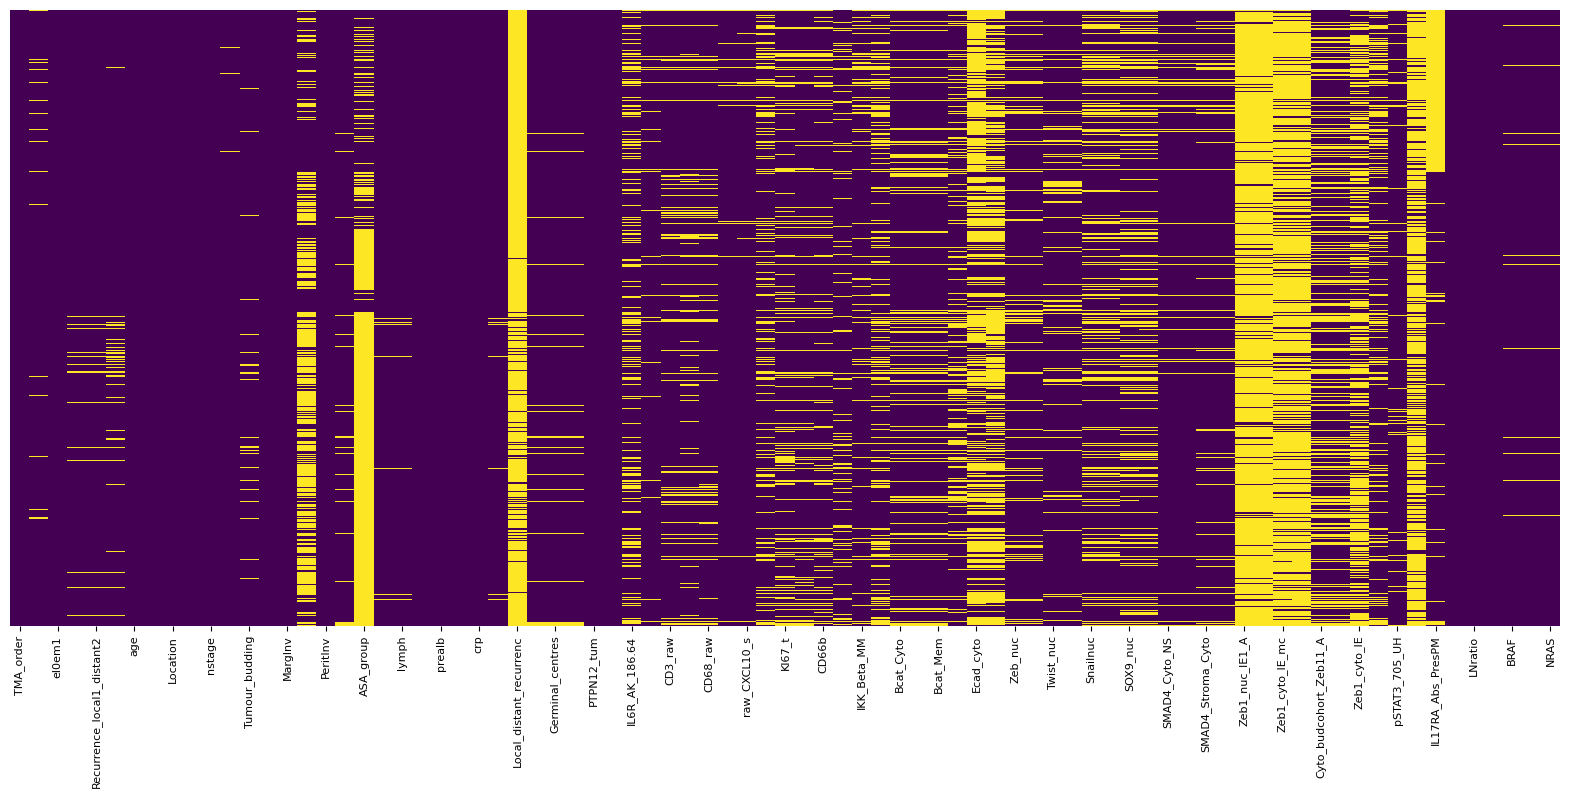

In [338]:
plt.figure(figsize=(20, 8))
sns.heatmap(df4.isna(), cbar=False, cmap="viridis")

plt.xticks(rotation=90, fontsize=8)  
plt.yticks([])         
plt.show()

Also removing those columns where we have more than 50% of missing values, since we will perform MICE. 

In [339]:

df4.shape


(722, 81)

In [340]:
k = int(np.ceil(0.5 * df4.shape[0]))  # required non-NA per row
k

361

In [341]:
df5 = df4.dropna(axis=1, thresh=k)
df5

,TMA_order,MMR_Status_Jen,el0em1,REC_n0_yes1,Recurrence_local1_distant2,Colin_full_recurrence_sites,age,sex,Location,tstage,nstage,Differentiation,Tumour_budding,TuPerf,MargInv,PeritInv,TSP_Pete,Neut,lymph,precrp,prealb,Elastica_VI,crp,pre_lymph,Lymphoid_aggregates,Germinal_centres,IE_Lymphocytes,PTPN12_tum,PTPN12_stroma,IL6R_AK_186.64,S100A2_raw,CD3_raw,CD3_FOXP3_raw,CD68_raw,raw_CXCL9_s,raw_CXCL10_s,Cyclind1_raw,KI67_t,CD163_Str,CD66b,IKKA_MM,IKK_Beta_MM,STAT1_tumour_raw,Bcat_Cyto,Bcat_Nuc,Bcat_Mem,Fascin_cyto,Zeb_nuc,Twist_cyto,Twist_nuc,Snail_cyto,Snailnuc,SOX9_cyto,SOX9_nuc,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Nu_NS,SMAD4_Stroma_Cyto,SMAD4_Stroma_Nu,Cyto_budcohort_Zeb11_A,Nuc_budcohort_zeb1,NPM1_GK,pSTAT3_705_UH,IL17RA_Abs_PresPM,Cmprsk_time,LNratio,Cmprsk_Status,BRAF,KRAS,NRAS
0,1,1.0,0.0,0.0,0.0,0.0,67.0,1.0,1.0,3.0,0.0,mod,0.0,0.0,0.0,0.0,30.0,6.3,1.6,11.0,35.0,1.0,1.10,1600.0,13.0,4.0,1.6,49.49,31.21,0.0,103.0,5.63,2.17,5.07,0.21,0.35,65.00,25.81,14.27,0.86,118.25,1.26,121.45,141.0,23.0,137.0,23.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,1.0,0.0,135.82,3.67,NaN,97.0,0.000,0.0,0.0,0.0,0.0
1,2,NaN,0.0,0.0,0.0,0.0,78.0,1.0,1.0,3.0,0.0,mod,0.0,0.0,0.0,0.0,70.0,3.5,1.4,2.0,35.0,1.0,0.20,1400.0,14.0,0.0,1.6,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,97.0,0.000,0.0,0.0,1.0,0.0
2,3,2.0,0.0,1.0,2.0,6.0,64.0,1.0,0.0,3.0,2.0,mod,1.0,0.0,0.0,0.0,30.0,4.3,2.1,8.2,34.0,1.0,0.82,2100.0,17.0,3.0,1.8,40.02,31.82,0.0,113.0,3.85,2.16,3.79,1.33,2.02,100.00,44.54,11.05,4.87,88.35,2.94,184.38,116.0,8.0,105.0,6.0,1.0,1.0,0.0,0.0,1.0,1.0,NaN,NaN,0.93,0.69,0.00,0.22,0.0,0.0,NaN,106.69,NaN,25.0,0.375,1.0,0.0,1.0,0.0
3,4,2.0,0.0,0.0,0.0,0.0,85.0,1.0,1.0,3.0,0.0,mod,1.0,0.0,0.0,0.0,50.0,8.9,0.7,9.0,33.0,1.0,0.90,700.0,11.0,0.0,2.7,89.35,91.12,NaN,102.0,16.17,11.15,4.97,4.89,3.22,76.67,24.43,26.14,11.14,101.83,19.74,99.86,116.0,25.0,115.0,6.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.31,0.13,0.00,0.08,0.0,0.0,133.14,152.01,NaN,83.0,0.000,2.0,0.0,0.0,1.0
4,5,2.0,0.0,0.0,0.0,0.0,57.0,1.0,1.0,2.0,0.0,mod,0.0,0.0,0.0,0.0,30.0,4.5,1.8,1.4,36.0,1.0,0.14,1800.0,0.0,0.0,1.1,100.93,85.71,0.0,105.0,1.43,3.60,1.51,0.38,0.72,125.00,61.50,1.86,7.05,149.48,10.38,134.66,140.0,38.0,121.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,50.37,16.12,14.81,4.92,1.0,1.0,173.53,96.60,NaN,97.0,0.000,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
717,781,2.0,0.0,0.0,0.0,0.0,68.0,0.0,1.0,3.0,0.0,mod,0.0,0.0,0.0,0.0,30.0,2.7,1.8,6.0,36.0,1.0,0.60,1800.0,7.0,1.0,1.8,69.24,55.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.30,NaN,171.0,0.000,0.0,0.0,0.0,0.0
718,782,2.0,0.0,0.0,0.0,0.0,66.0,1.0,1.0,2.0,0.0,mod,0.0,0.0,0.0,0.0,NaN,3.6,1.4,6.0,43.0,1.0,0.60,1400.0,NaN,NaN,NaN,57.08,59.51,NaN,100.0,4.19,3.28,1.00,0.70,0.38,NaN,7.28,0.47,12.59,76.31,103.08,NaN,130.0,4.0,113.0,2.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,36.49,13.87,16.97,10.34,1.0,1.0,NaN,0.00,NaN,104.0,0.000,2.0,0.0,0.0,0.0
719,784,2.0,0.0,0.0,0.0,0.0,78.0,0.0,2.0,3.0,0.0,mod,0.0,0.0,0.0,0.0,NaN,4.2,2.7,19.0,42.0,1.0,1.90,2700.0,NaN,NaN,NaN,26.80,27.77,NaN,100.0,NaN,NaN,NaN,4.76,7.61,NaN,NaN,NaN,NaN,107.92,NaN,NaN,NaN,NaN,NaN,26.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,11.99,9.50,NaN,NaN,NaN,NaN,NaN,80.56,NaN,145.0,0.000,2.0,0.0,1.0,1.0
720,785,2.0,1.0,0.0,0.0,0.0,75.0,1.0,1.0,3.0,2.0,mod,0.0,0.0,0.0,0.0,NaN,7.2,1.2,20.0,36.0,1.0,2.00,1200.0,NaN,NaN,NaN,25.56,16.67,0.0,100.0,NaN,NaN,NaN,1.23,2.64,NaN,NaN,NaN,13.26,NaN,85.03,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,29.82,31.34,6.71,15.24,NaN,NaN,NaN,36.89,NaN,53.0,0.600,2.0,0.0,1.0,1.0


In [342]:

#dropped columns
df4.columns.difference(df5.columns)


Index(['ASA_group', 'Bud_histoscore_zeb1_mc', 'Ecad_Mem', 'Ecad_cyto',
       'Local_distant_recurrenc', 'Perineural_Inv', 'Zeb1_cyto_IE',
       'Zeb1_cyto_IE_mc', 'Zeb1_nuc_IE1_A', 'Zeb1_nuc_IE_code',
       'pSTAT3_Tum_Bud_PM'],
      dtype='object')

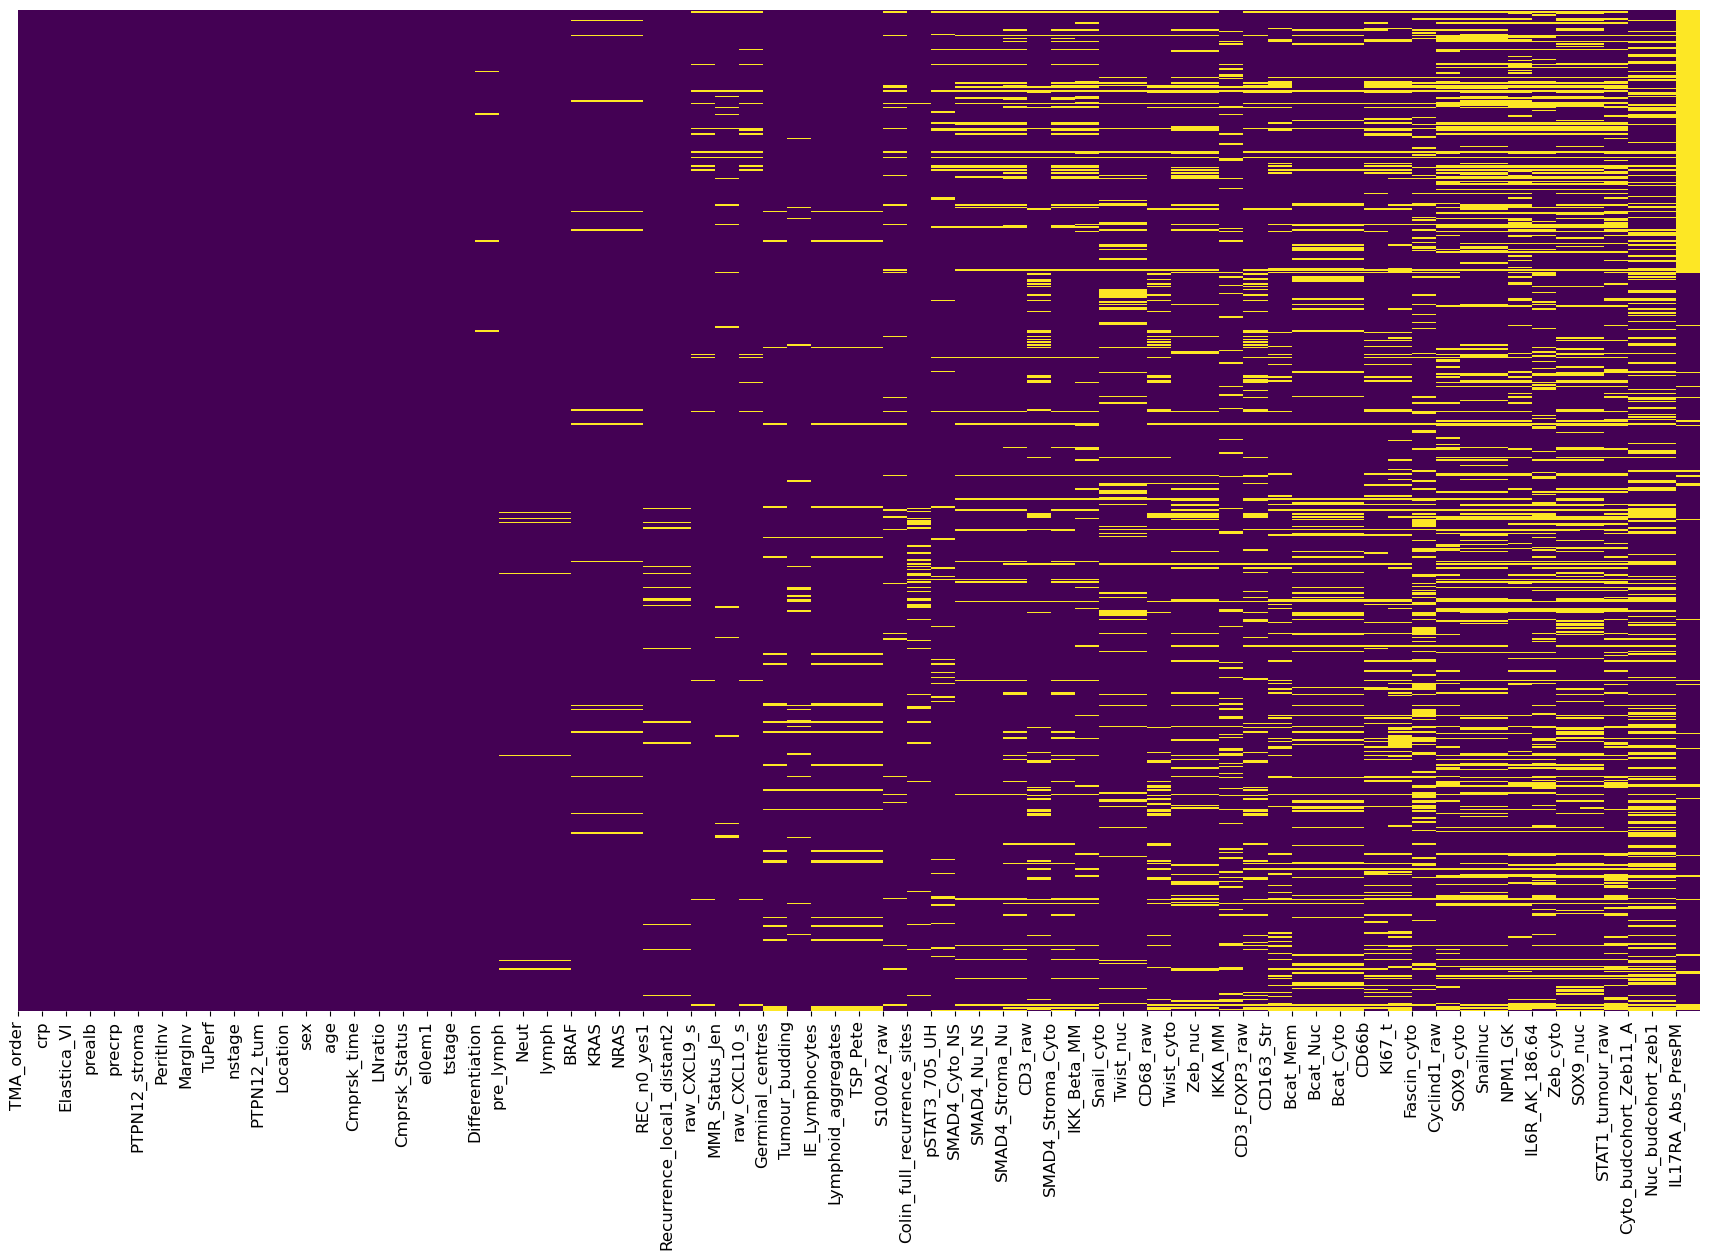

In [343]:
plt.figure(figsize=(17.5, 13))

missing_order = df5.isna().mean().sort_values()

df5_sorted = df5[missing_order.index]
ax = sns.heatmap(df5_sorted.isna(), cbar=False, cmap="viridis")

ax.set_xticks(range(len(df5_sorted.columns)))
ax.set_xticklabels(df5_sorted.columns, rotation=90, ha="center", fontsize=12)
ax.set_yticks([])
plt.tight_layout()

In [344]:
df5.shape

(722, 70)

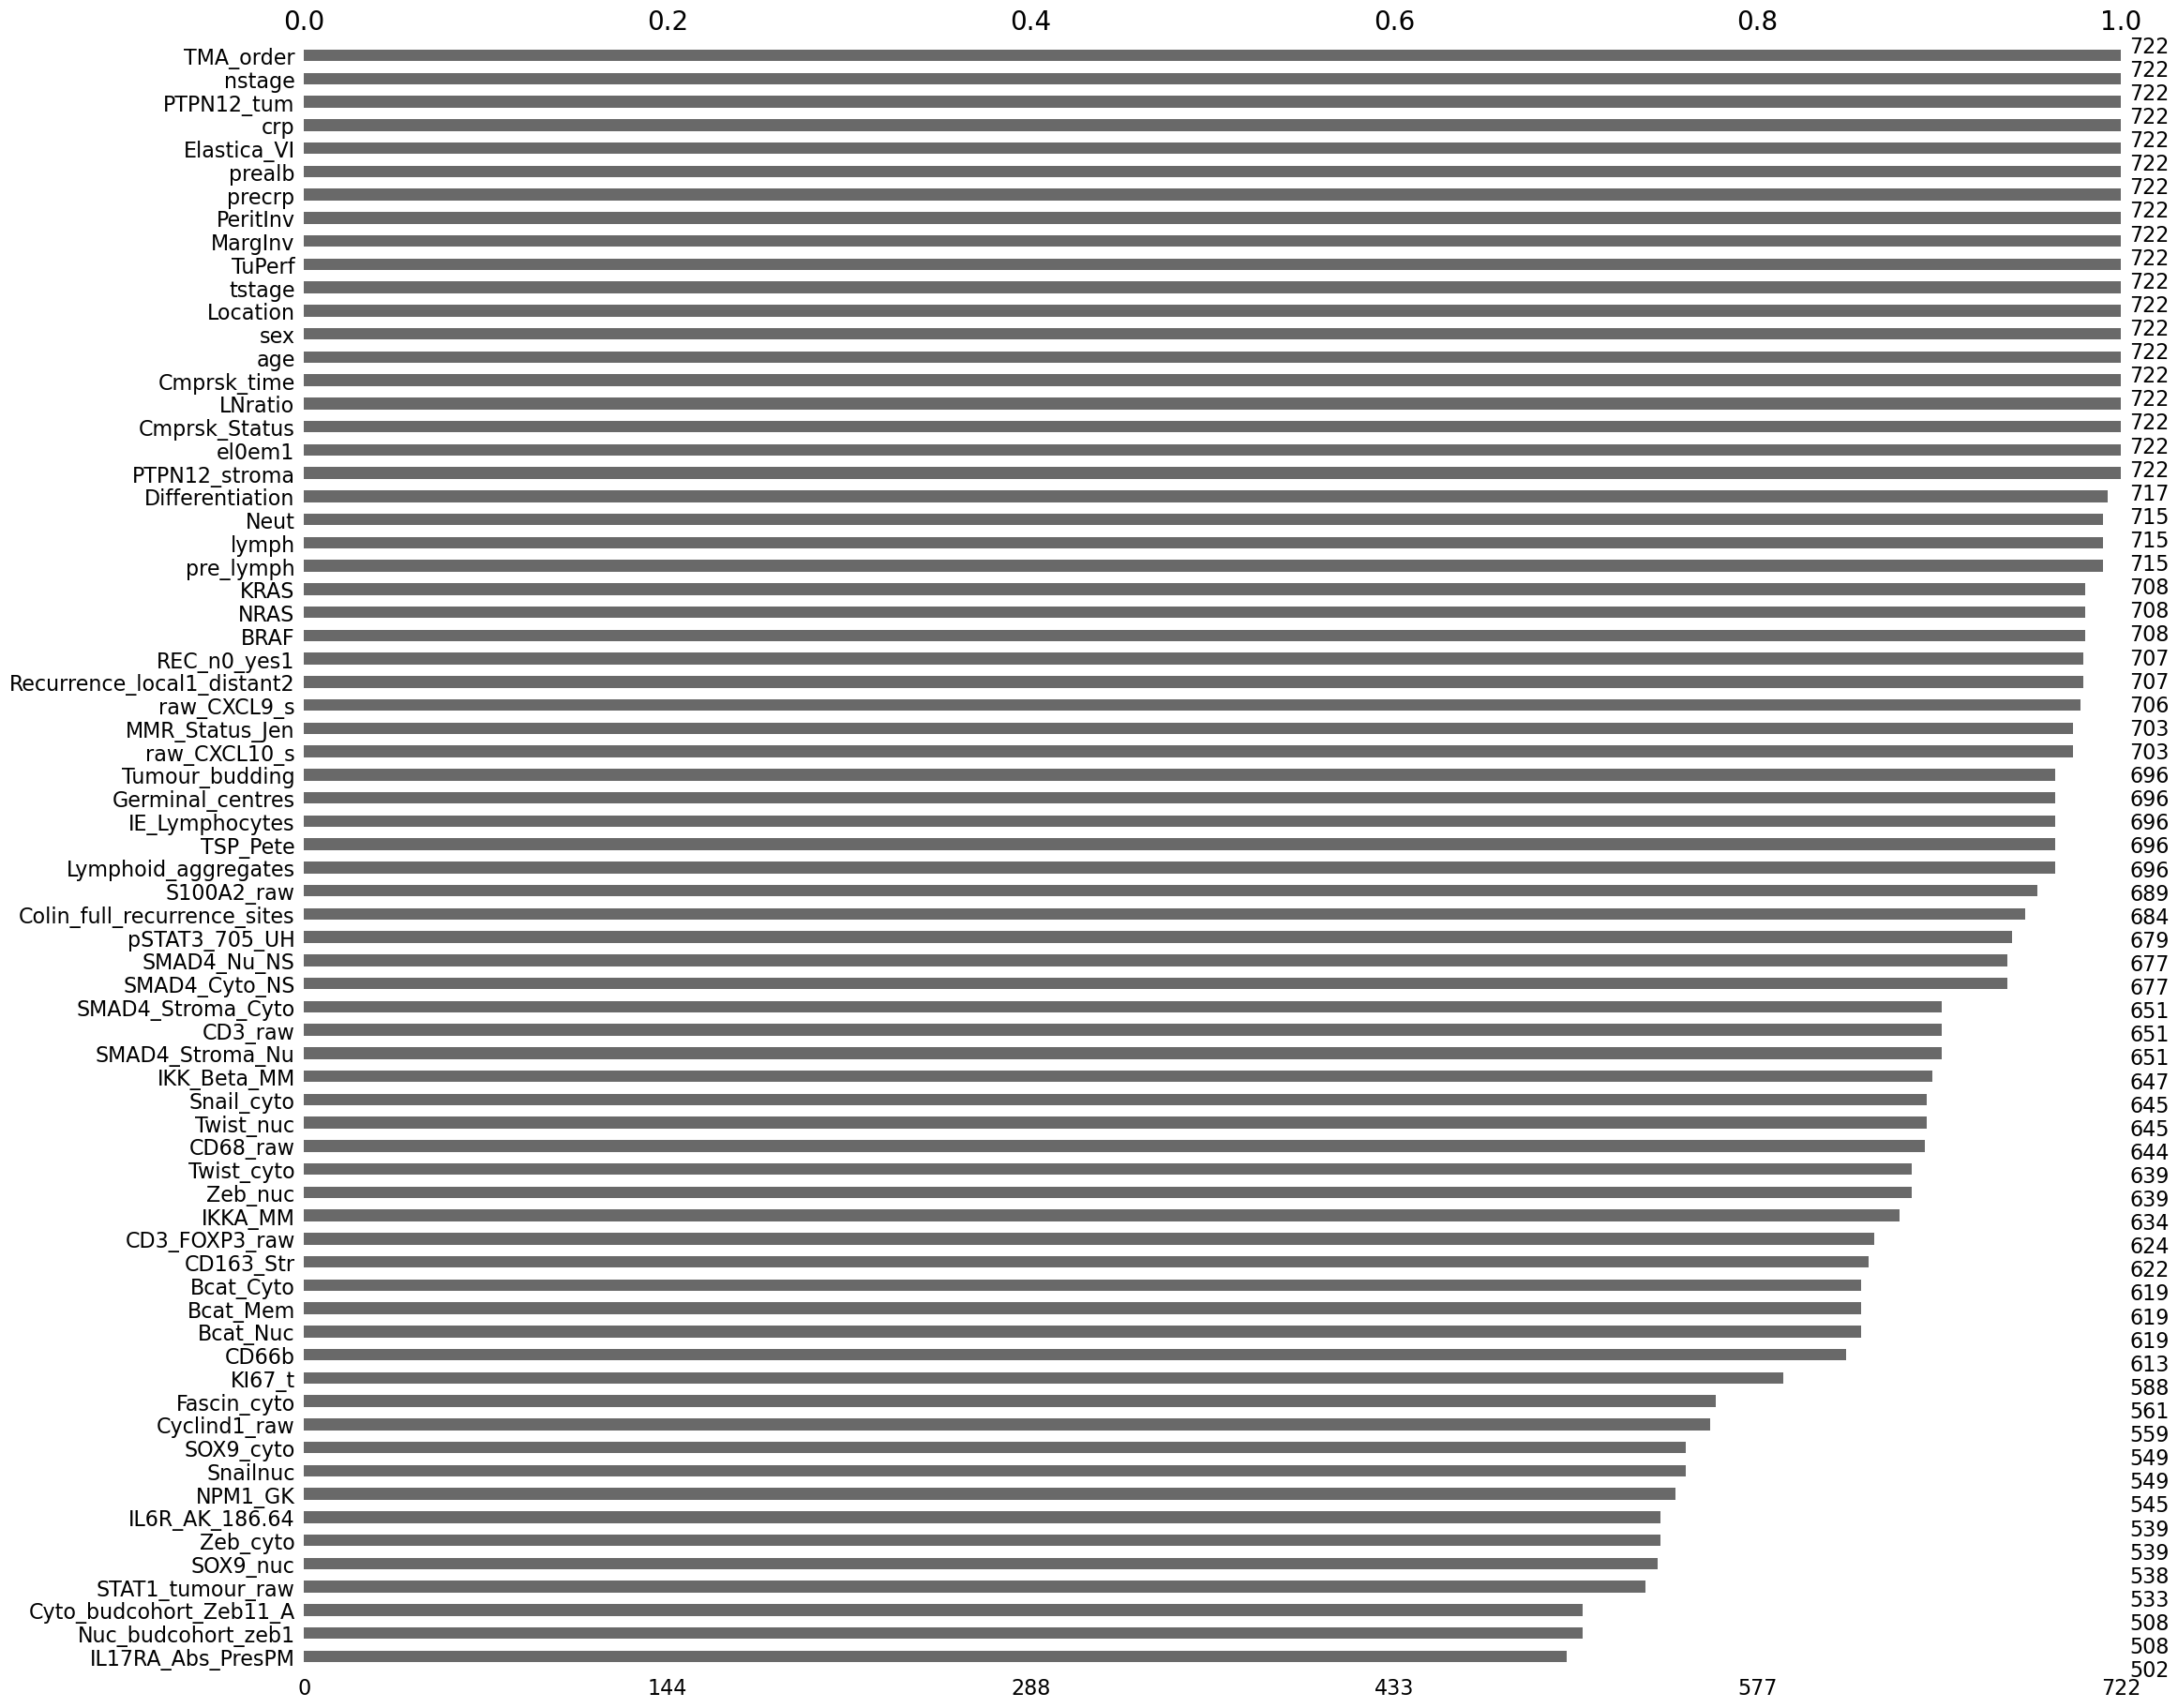

In [345]:
msno.bar(df5,  sort = "ascending")
plt.show()

However the columns might not be with the correct type

In [346]:
df5.dtypes
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 70 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TMA_order                    722 non-null    int64  
 1   MMR_Status_Jen               703 non-null    float64
 2   el0em1                       722 non-null    float64
 3   REC_n0_yes1                  707 non-null    float64
 4   Recurrence_local1_distant2   707 non-null    float64
 5   Colin_full_recurrence_sites  684 non-null    float64
 6   age                          722 non-null    float64
 7   sex                          722 non-null    float64
 8   Location                     722 non-null    float64
 9   tstage                       722 non-null    float64
 10  nstage                       722 non-null    float64
 11  Differentiation              717 non-null    object 
 12  Tumour_budding               696 non-null    float64
 13  TuPerf              

In [347]:
df6 = smart_fix_dtypes(df5, cat_threshold=10)
#print(df5.dtypes)
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 70 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   TMA_order                    722 non-null    int64   
 1   MMR_Status_Jen               703 non-null    category
 2   el0em1                       722 non-null    Int8    
 3   REC_n0_yes1                  707 non-null    Int8    
 4   Recurrence_local1_distant2   707 non-null    category
 5   Colin_full_recurrence_sites  684 non-null    category
 6   age                          722 non-null    float64 
 7   sex                          722 non-null    Int8    
 8   Location                     722 non-null    category
 9   tstage                       722 non-null    category
 10  nstage                       722 non-null    category
 11  Differentiation              717 non-null    category
 12  Tumour_budding               696 non-null    Int8    
 13  TuPer

Some further organization of values in certain columns:

In [348]:
df6["Differentiation"].value_counts(dropna=False)

Differentiation
mod         606
poor         66
well         16
mod/well     11
mod/poor      9
<NA>          5
well/mod      4
Mod           1
mucin         1
mucinous      1
undiff        1
welll         1
Name: count, dtype: int64

Map considering the recommendations in the QPIs:

In [349]:
_map = { 
    # Well/Moderate
    "well": "Well/Moderate", "welll": "Well/Moderate",
    "mod": "Well/Moderate", "moderate": "Well/Moderate",
    "mod/well": "Well/Moderate", "well/mod": "Well/Moderate",

    # Poor / undiff
    "poor": "Poor/Undiff", "mod/poor": "Poor/Undiff", "poor/mod": "Poor/Undiff", "undiff": "Poor/Undiff",
    "mucin": "Poor/Undiff", "mucinous": "Poor/Undiff", "muscious": "Poor/Undiff",
    # Mucinous olnly two labels
    #"mucin": "Mucinous", "mucinous": "Mucinous", "muscious": "Mucinous",
}

# normalize to lowercase first, then map
s = df6["Differentiation"].astype(str).str.strip().str.lower()
df6["Differentiation"] = s.map(_map)

# quick check
print(df6["Differentiation"].value_counts(dropna=False))

Differentiation
Well/Moderate    639
Poor/Undiff       78
NaN                5
Name: count, dtype: int64


In [350]:
df6["TSP_Pete"].value_counts(dropna=False)

TSP_Pete
20.0    194
30.0    143
60.0     82
10.0     78
40.0     77
70.0     48
50.0     32
NaN      26
80.0     15
55.0     10
5.0       9
25.0      4
15.0      2
45.0      2
Name: count, dtype: int64

In [351]:
df6["tstage"].value_counts(dropna=False) / len(df6["tstage"]) * 100


tstage
3    55.955679
4    28.947368
2    10.664820
1     4.432133
Name: count, dtype: float64

We are going to group the stage of I and II, we saw in preliminary analysis that the hazard ratios had really high confidence intervals.

In [352]:
t = pd.to_numeric(df6["tstage"], errors="coerce")
df6["tstage"] = t.map({1: "I–II", 2: "I–II", 3: "III", 4: "IV"})

In [353]:
df6["tstage"].value_counts(dropna=False)

tstage
III     404
IV      209
I–II    109
Name: count, dtype: int64

In [354]:
df6["MMR_Status_Jen"].value_counts(dropna=False)

MMR_Status_Jen
2      468
1      124
3      111
NaN     19
Name: count, dtype: int64

In [355]:
df6["MMR_Status_Jen"] = np.where(df6["MMR_Status_Jen"] == 3, np.nan,  df6["MMR_Status_Jen"])

In [356]:
df6["MMR_Status_Jen"].value_counts(dropna = False) * 100 / len(df6["MMR_Status_Jen"])

MMR_Status_Jen
2.0    64.819945
NaN    18.005540
1.0    17.174515
Name: count, dtype: float64

In [357]:
df6["TuPerf"].value_counts(dropna=False) / len(df6["TuPerf"]) * 100

TuPerf
0    96.814404
1     3.185596
Name: count, dtype: Float64

In [358]:
df6.columns

Index(['TMA_order', 'MMR_Status_Jen', 'el0em1', 'REC_n0_yes1',
       'Recurrence_local1_distant2', 'Colin_full_recurrence_sites', 'age',
       'sex', 'Location', 'tstage', 'nstage', 'Differentiation',
       'Tumour_budding', 'TuPerf', 'MargInv', 'PeritInv', 'TSP_Pete', 'Neut',
       'lymph', 'precrp', 'prealb', 'Elastica_VI', 'crp', 'pre_lymph',
       'Lymphoid_aggregates', 'Germinal_centres', 'IE_Lymphocytes',
       'PTPN12_tum', 'PTPN12_stroma', 'IL6R_AK_186.64', 'S100A2_raw',
       'CD3_raw', 'CD3_FOXP3_raw', 'CD68_raw', 'raw_CXCL9_s', 'raw_CXCL10_s',
       'Cyclind1_raw', 'KI67_t', 'CD163_Str', 'CD66b', 'IKKA_MM',
       'IKK_Beta_MM', 'STAT1_tumour_raw', 'Bcat_Cyto', 'Bcat_Nuc', 'Bcat_Mem',
       'Fascin_cyto', 'Zeb_nuc', 'Twist_cyto', 'Twist_nuc', 'Snail_cyto',
       'Snailnuc', 'SOX9_cyto', 'SOX9_nuc', 'Zeb_cyto', 'SMAD4_Cyto_NS',
       'SMAD4_Nu_NS', 'SMAD4_Stroma_Cyto', 'SMAD4_Stroma_Nu',
       'Cyto_budcohort_Zeb11_A', 'Nuc_budcohort_zeb1', 'NPM1_GK',
       'pSTA

In [359]:
df6.shape

(722, 70)

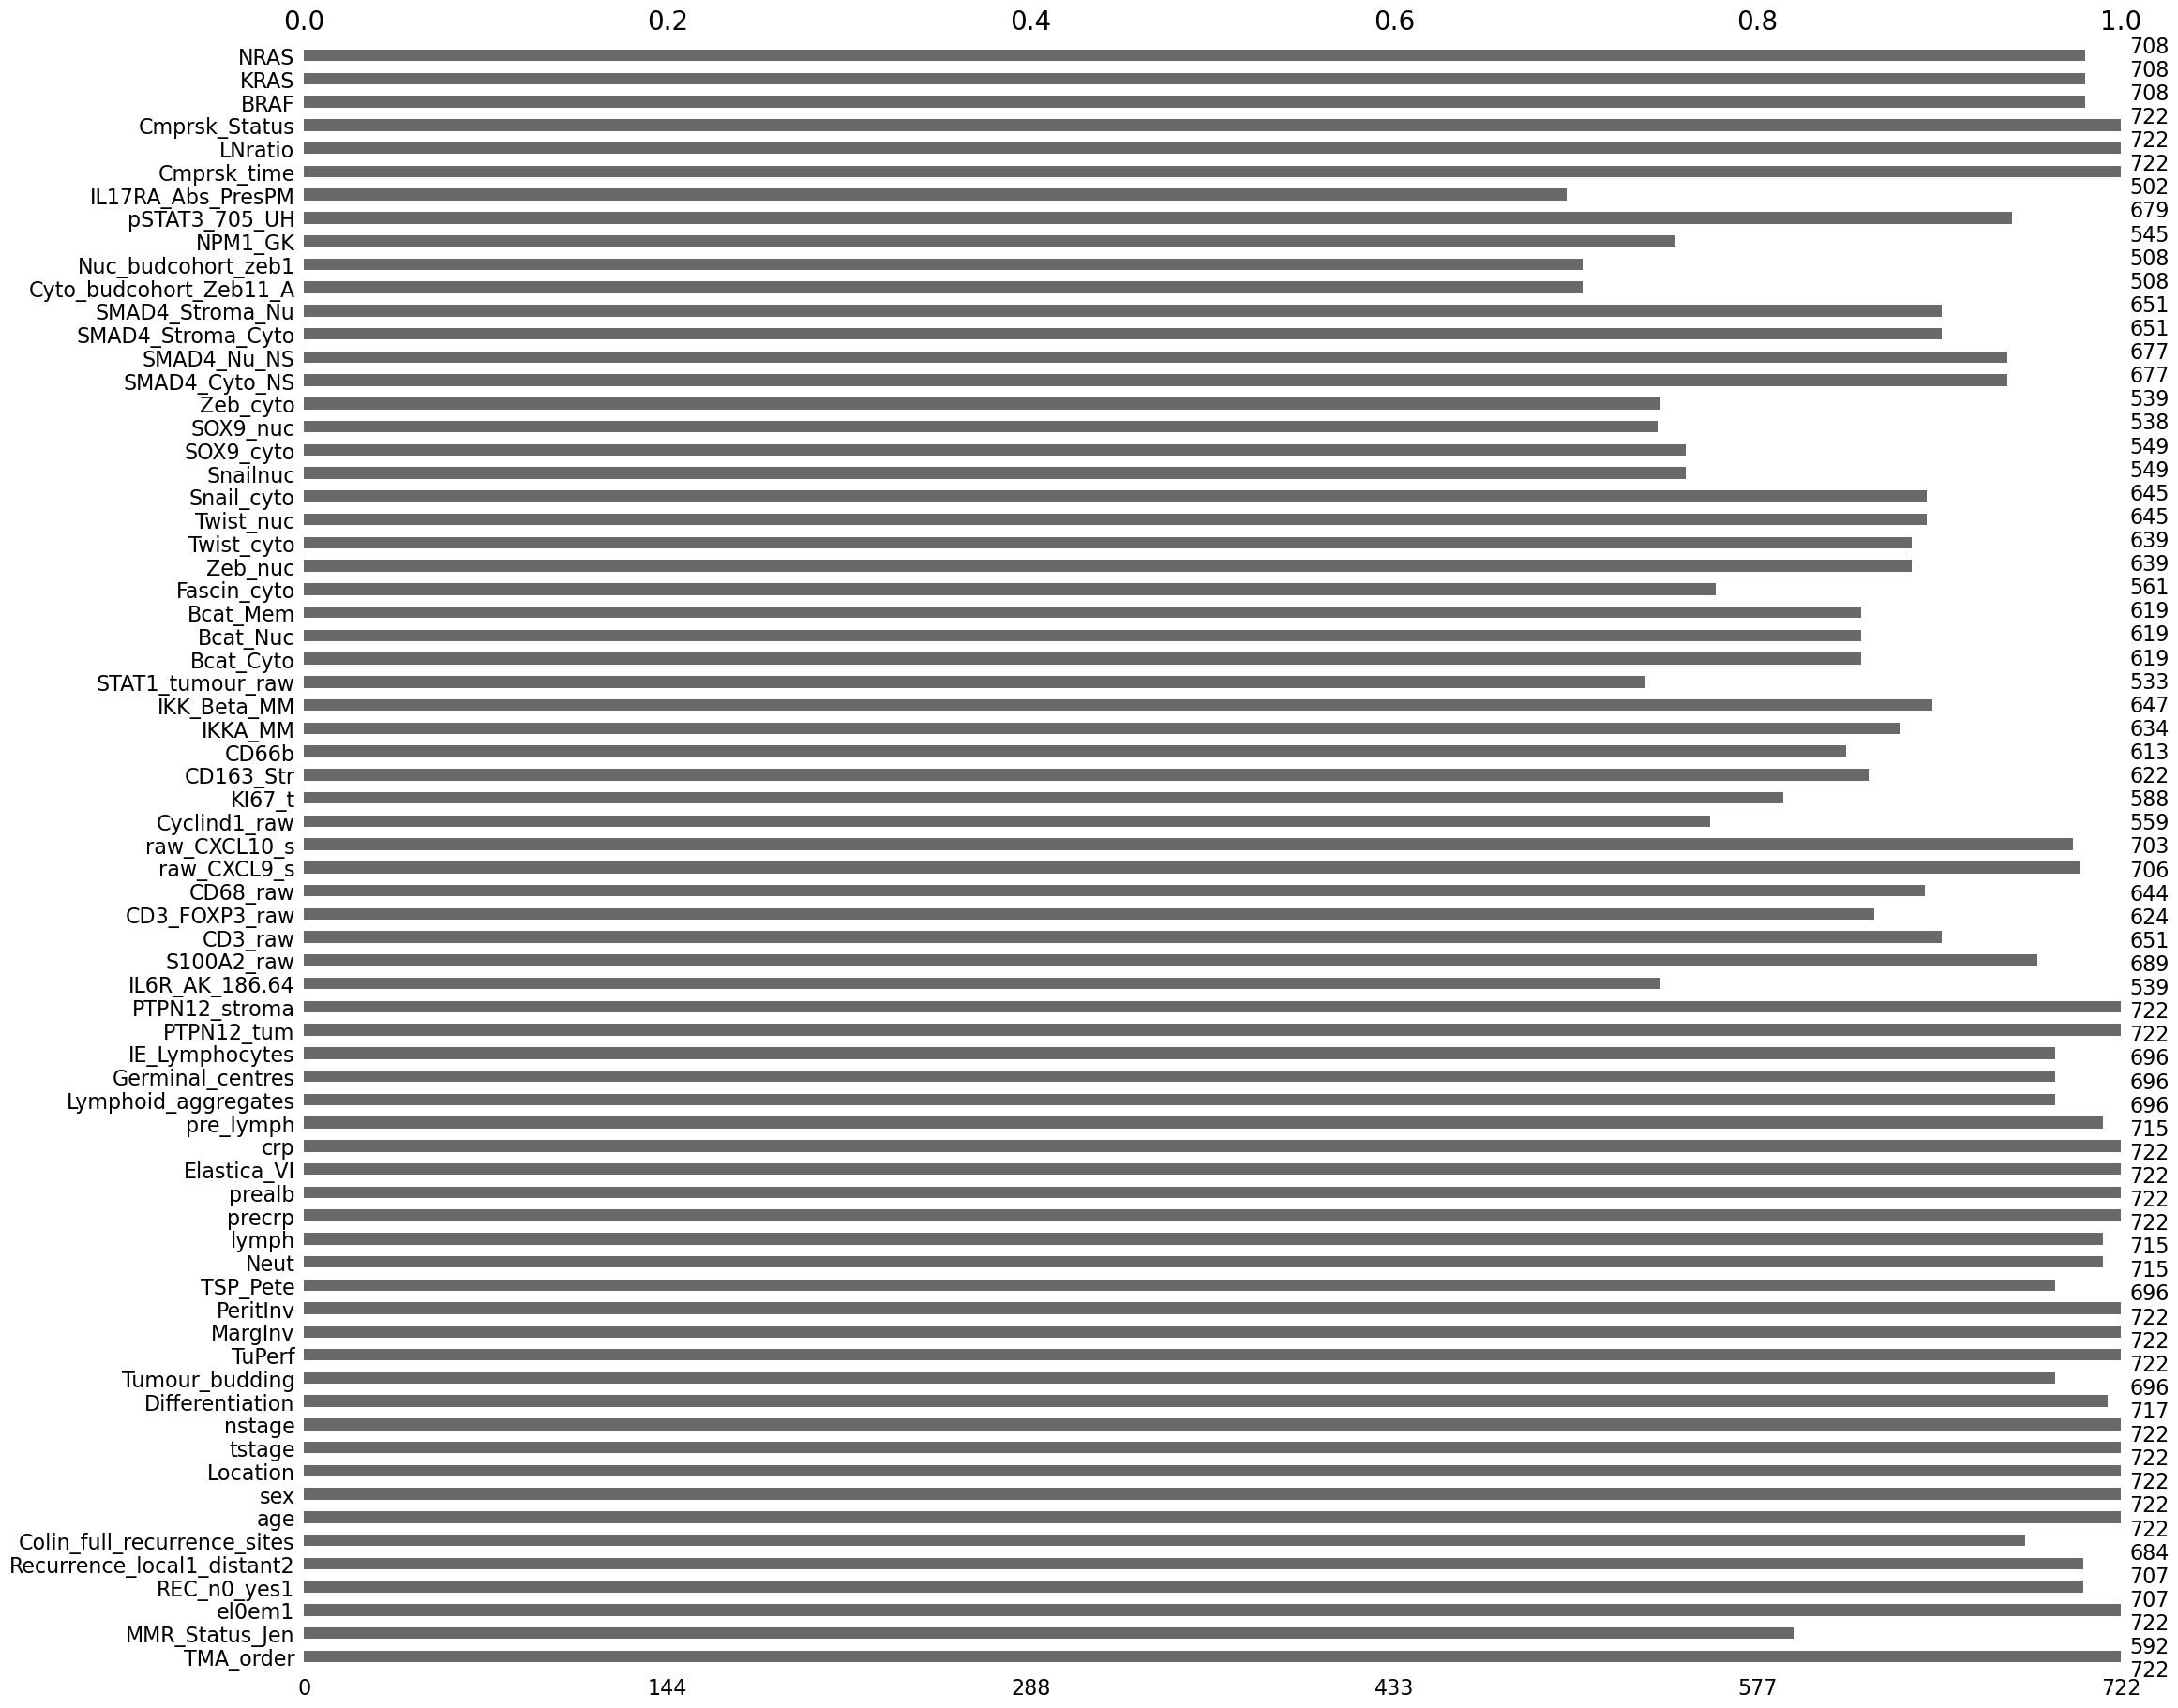

In [360]:
msno.bar(df6)
plt.show()

### Correlation plots

Numeric variables

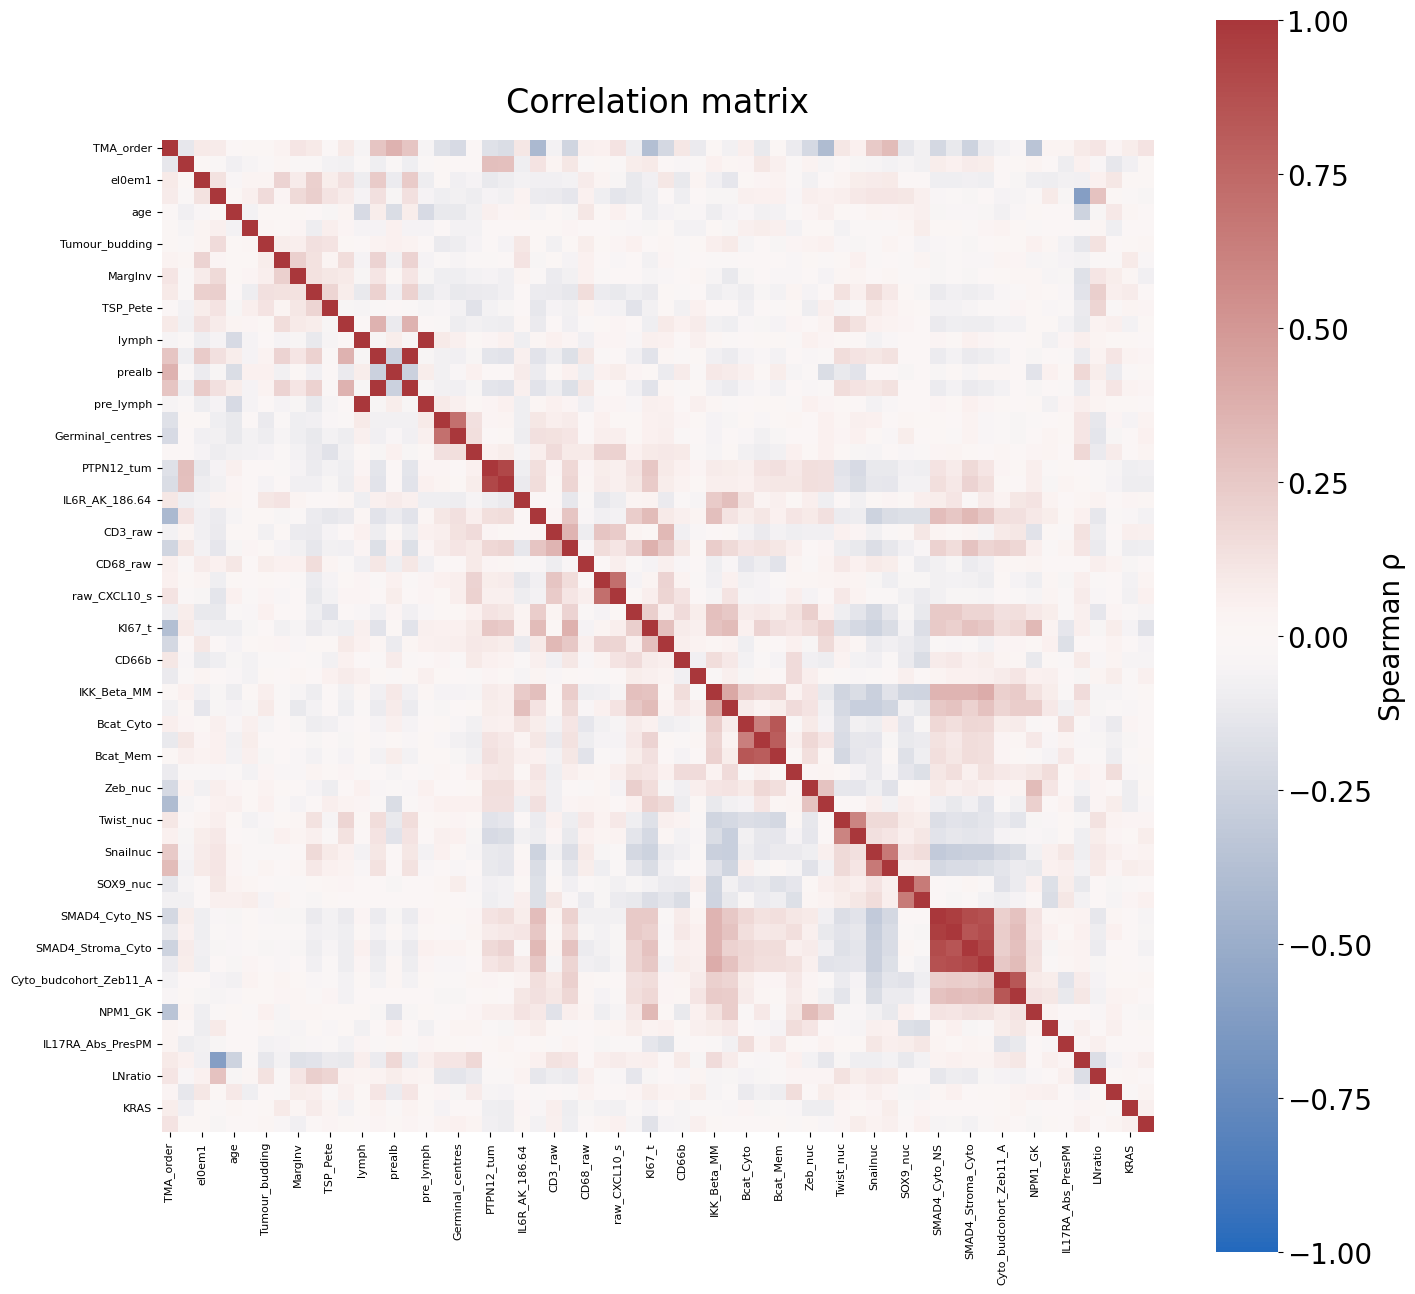

In [361]:
num = df6.select_dtypes(include=[np.number]).copy()
num = num.loc[:, num.nunique(dropna=True) > 1] 
corr = num.corr(method="spearman")

plt.figure(figsize=(16, 16))
ax = sns.heatmap(
    corr, vmin=-1, vmax=1, cmap="vlag", center=0,
    annot=False, square=True, cbar_kws={"label": "Spearman ρ"}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  va="center", fontsize=8)
ax.set_title("Correlation matrix", pad=20)
plt.show()

In [362]:
corr = num.corr(method="spearman")

# Keep only upper triangle (exclude diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Extract correlated pairs > 0.8
high_corr = (
    corr.where(mask)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
        .query("corr > 0.8")
        .sort_values("corr", ascending=False)
)

print(high_corr)


                        var1                var2      corr
669                    lymph           pre_lymph  1.000000
716                   precrp                 crp  1.000000
1800           SMAD4_Cyto_NS         SMAD4_Nu_NS  0.962578
1825       SMAD4_Stroma_Cyto     SMAD4_Stroma_Nu  0.916710
1030              PTPN12_tum       PTPN12_stroma  0.916203
1801           SMAD4_Cyto_NS   SMAD4_Stroma_Cyto  0.896074
1814             SMAD4_Nu_NS     SMAD4_Stroma_Nu  0.885376
1802           SMAD4_Cyto_NS     SMAD4_Stroma_Nu  0.867417
1813             SMAD4_Nu_NS   SMAD4_Stroma_Cyto  0.848843
1846  Cyto_budcohort_Zeb11_A  Nuc_budcohort_zeb1  0.840761
1567               Bcat_Cyto            Bcat_Mem  0.836680
1591                Bcat_Nuc            Bcat_Mem  0.812138


                        var1                var2      corr
1591                Bcat_Nuc            Bcat_Mem  0.812138
1567               Bcat_Cyto            Bcat_Mem  0.836680
1846  Cyto_budcohort_Zeb11_A  Nuc_budcohort_zeb1  0.840761
1813             SMAD4_Nu_NS   SMAD4_Stroma_Cyto  0.848843
1802           SMAD4_Cyto_NS     SMAD4_Stroma_Nu  0.867417
1814             SMAD4_Nu_NS     SMAD4_Stroma_Nu  0.885376
1801           SMAD4_Cyto_NS   SMAD4_Stroma_Cyto  0.896074
1030              PTPN12_tum       PTPN12_stroma  0.916203
1825       SMAD4_Stroma_Cyto     SMAD4_Stroma_Nu  0.916710
1800           SMAD4_Cyto_NS         SMAD4_Nu_NS  0.962578
669                    lymph           pre_lymph  1.000000
716                   precrp                 crp  1.000000


/var/folders/48/2dr34pgd6vbgmnq_dzg_m42r0000gq/T/ipykernel_5924/1248117090.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


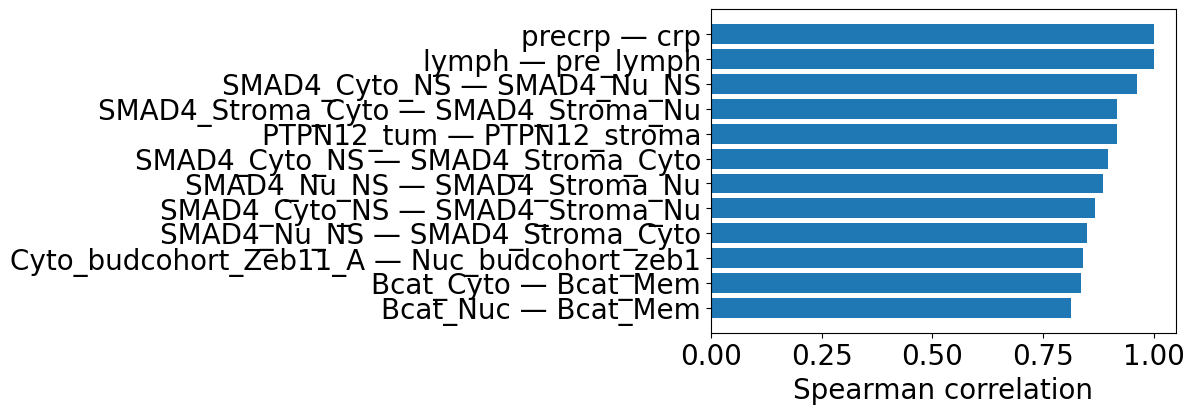

In [363]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_upper = corr.where(mask)

# Pairs with corr > 0.8
pairs = (
    corr_upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
    .query("corr > 0.8")
    .sort_values("corr", ascending=True)
)
print(pairs)

# Bar plot of correlated pairs
plt.figure(figsize=(6, max(2, 0.35*len(pairs))))
plt.barh(pairs.apply(lambda r: f"{r.var1} — {r.var2}", axis=1), pairs["corr"])
plt.xlabel("Spearman correlation")
plt.tight_layout()
plt.show()

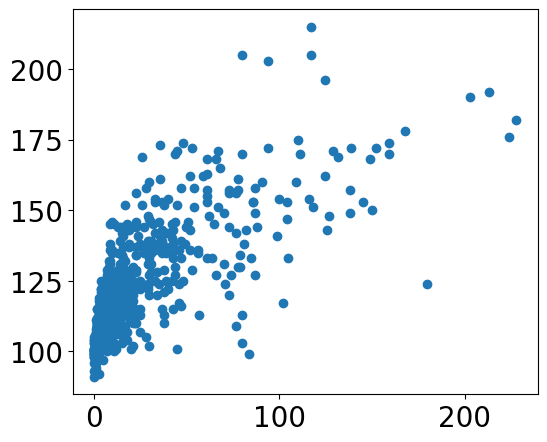

In [364]:
plt.figure(figsize=(6, 5))
plt.scatter(df6["Bcat_Nuc"], df6["Bcat_Mem"])

We can see that some variables are highly correlated. 

For instance preoperative crp and crp, as well as preoperative lymphocites and lymphocites. 

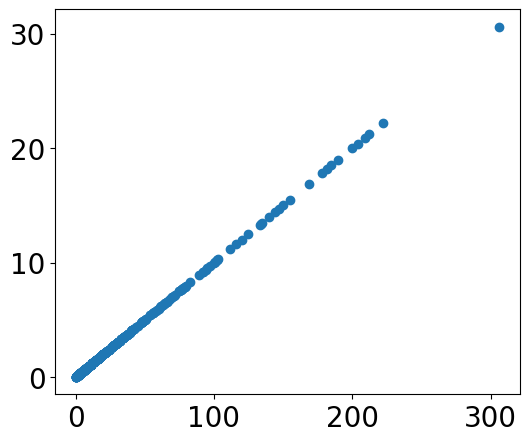

In [365]:
plt.figure(figsize=(6, 5))
plt.scatter(df6["precrp"], df6["crp"])

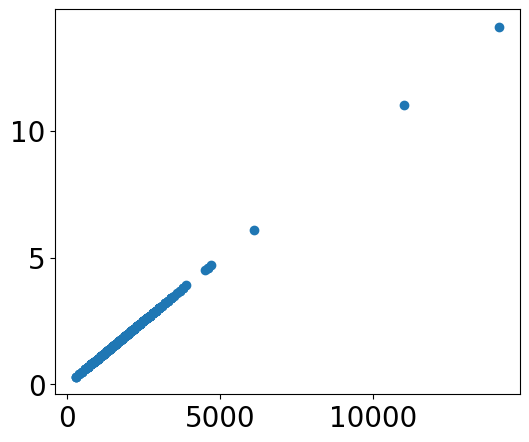

In [366]:
plt.figure(figsize=(6, 5))
plt.scatter(df6["pre_lymph"], df6["lymph"])

Joanne Edwards lab suggested that preoperative measure are preferable. We can delete the non-preoperative ones.

In [367]:
df7 = df6.drop(labels=["crp", "lymph"], axis=1)

df7

,TMA_order,MMR_Status_Jen,el0em1,REC_n0_yes1,Recurrence_local1_distant2,Colin_full_recurrence_sites,age,sex,Location,tstage,nstage,Differentiation,Tumour_budding,TuPerf,MargInv,PeritInv,TSP_Pete,Neut,precrp,prealb,Elastica_VI,pre_lymph,Lymphoid_aggregates,Germinal_centres,IE_Lymphocytes,PTPN12_tum,PTPN12_stroma,IL6R_AK_186.64,S100A2_raw,CD3_raw,CD3_FOXP3_raw,CD68_raw,raw_CXCL9_s,raw_CXCL10_s,Cyclind1_raw,KI67_t,CD163_Str,CD66b,IKKA_MM,IKK_Beta_MM,STAT1_tumour_raw,Bcat_Cyto,Bcat_Nuc,Bcat_Mem,Fascin_cyto,Zeb_nuc,Twist_cyto,Twist_nuc,Snail_cyto,Snailnuc,SOX9_cyto,SOX9_nuc,Zeb_cyto,SMAD4_Cyto_NS,SMAD4_Nu_NS,SMAD4_Stroma_Cyto,SMAD4_Stroma_Nu,Cyto_budcohort_Zeb11_A,Nuc_budcohort_zeb1,NPM1_GK,pSTAT3_705_UH,IL17RA_Abs_PresPM,Cmprsk_time,LNratio,Cmprsk_Status,BRAF,KRAS,NRAS
0,1,1.0,0,0,0,0,67.0,1,1,III,0,Well/Moderate,0,0,0,0,30.0,6.3,11.0,35.0,1,1600.0,13.0,4.0,1.6,49.49,31.21,0,103.0,5.63,2.17,5.07,0.21,0.35,65.00,25.81,14.27,0.86,118.25,1.26,121.45,141.0,23.0,137.0,23.0,1,1,0,0,0,0,0,0,0.00,0.00,0.00,0.00,1,0,135.82,3.67,<NA>,97.0,0.000,0,0,0,0
1,2,NaN,0,0,0,0,78.0,1,1,III,0,Well/Moderate,0,0,0,0,70.0,3.5,2.0,35.0,1,1400.0,14.0,0.0,1.6,0.00,0.00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.68,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,0,0,NaN,NaN,<NA>,97.0,0.000,0,0,1,0
2,3,2.0,0,1,2,6,64.0,1,0,III,2,Well/Moderate,1,0,0,0,30.0,4.3,8.2,34.0,1,2100.0,17.0,3.0,1.8,40.02,31.82,0,113.0,3.85,2.16,3.79,1.33,2.02,100.00,44.54,11.05,4.87,88.35,2.94,184.38,116.0,8.0,105.0,6.0,1,1,0,0,1,1,<NA>,<NA>,0.93,0.69,0.00,0.22,0,0,NaN,106.69,<NA>,25.0,0.375,1,0,1,0
3,4,2.0,0,0,0,0,85.0,1,1,III,0,Well/Moderate,1,0,0,0,50.0,8.9,9.0,33.0,1,700.0,11.0,0.0,2.7,89.35,91.12,<NA>,102.0,16.17,11.15,4.97,4.89,3.22,76.67,24.43,26.14,11.14,101.83,19.74,99.86,116.0,25.0,115.0,6.0,1,1,0,0,1,1,0,1,0.31,0.13,0.00,0.08,0,0,133.14,152.01,<NA>,83.0,0.000,2,0,0,1
4,5,2.0,0,0,0,0,57.0,1,1,I–II,0,Well/Moderate,0,0,0,0,30.0,4.5,1.4,36.0,1,1800.0,0.0,0.0,1.1,100.93,85.71,0,105.0,1.43,3.60,1.51,0.38,0.72,125.00,61.50,1.86,7.05,149.48,10.38,134.66,140.0,38.0,121.0,1.0,1,1,0,0,0,0,0,0,50.37,16.12,14.81,4.92,1,1,173.53,96.60,<NA>,97.0,0.000,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
717,781,2.0,0,0,0,0,68.0,0,1,III,0,Well/Moderate,0,0,0,0,30.0,2.7,6.0,36.0,1,1800.0,7.0,1.0,1.8,69.24,55.10,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,117.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,0,0,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,7.30,<NA>,171.0,0.000,0,0,0,0
718,782,2.0,0,0,0,0,66.0,1,1,I–II,0,Well/Moderate,0,0,0,0,NaN,3.6,6.0,43.0,1,1400.0,NaN,NaN,NaN,57.08,59.51,<NA>,100.0,4.19,3.28,1.00,0.70,0.38,NaN,7.28,0.47,12.59,76.31,103.08,NaN,130.0,4.0,113.0,2.0,1,0,0,0,1,1,0,0,36.49,13.87,16.97,10.34,1,1,NaN,0.00,<NA>,104.0,0.000,2,0,0,0
719,784,2.0,0,0,0,0,78.0,0,2,III,0,Well/Moderate,0,0,0,0,NaN,4.2,19.0,42.0,1,2700.0,NaN,NaN,NaN,26.80,27.77,<NA>,100.0,NaN,NaN,NaN,4.76,7.61,NaN,NaN,NaN,NaN,107.92,NaN,NaN,NaN,NaN,NaN,26.0,<NA>,<NA>,1,1,<NA>,<NA>,<NA>,<NA>,11.99,9.50,NaN,NaN,<NA>,<NA>,NaN,80.56,<NA>,145.0,0.000,2,0,1,1
720,785,2.0,1,0,0,0,75.0,1,1,III,2,Well/Moderate,0,0,0,0,NaN,7.2,20.0,36.0,1,1200.0,NaN,NaN,NaN,25.56,16.67,0,100.0,NaN,NaN,NaN,1.23,2.64,NaN,NaN,NaN,13.26,NaN,85.03,NaN,NaN,NaN,NaN,1.0,1,0,0,0,1,1,0,0,29.82,31.34,6.71,15.24,<NA>,<NA>,NaN,36.89,<NA>,53.0,0.600,2,0,1,1


In [368]:
df8 = df7.drop(
    columns=[
        "SMAD4_Cyto_NS",
        "SMAD4_Stroma_Cyto",
        "PTPN12_stroma",
        "SMAD4_Stroma_Nu",
        "Cyto_budcohort_Zeb11_A",
        "Bcat_Cyto",
        "Bcat_Mem"
    ],
    errors="ignore")


In [369]:
df8.columns

Index(['TMA_order', 'MMR_Status_Jen', 'el0em1', 'REC_n0_yes1',
       'Recurrence_local1_distant2', 'Colin_full_recurrence_sites', 'age',
       'sex', 'Location', 'tstage', 'nstage', 'Differentiation',
       'Tumour_budding', 'TuPerf', 'MargInv', 'PeritInv', 'TSP_Pete', 'Neut',
       'precrp', 'prealb', 'Elastica_VI', 'pre_lymph', 'Lymphoid_aggregates',
       'Germinal_centres', 'IE_Lymphocytes', 'PTPN12_tum', 'IL6R_AK_186.64',
       'S100A2_raw', 'CD3_raw', 'CD3_FOXP3_raw', 'CD68_raw', 'raw_CXCL9_s',
       'raw_CXCL10_s', 'Cyclind1_raw', 'KI67_t', 'CD163_Str', 'CD66b',
       'IKKA_MM', 'IKK_Beta_MM', 'STAT1_tumour_raw', 'Bcat_Nuc', 'Fascin_cyto',
       'Zeb_nuc', 'Twist_cyto', 'Twist_nuc', 'Snail_cyto', 'Snailnuc',
       'SOX9_cyto', 'SOX9_nuc', 'Zeb_cyto', 'SMAD4_Nu_NS',
       'Nuc_budcohort_zeb1', 'NPM1_GK', 'pSTAT3_705_UH', 'IL17RA_Abs_PresPM',
       'Cmprsk_time', 'LNratio', 'Cmprsk_Status', 'BRAF', 'KRAS', 'NRAS'],
      dtype='object')

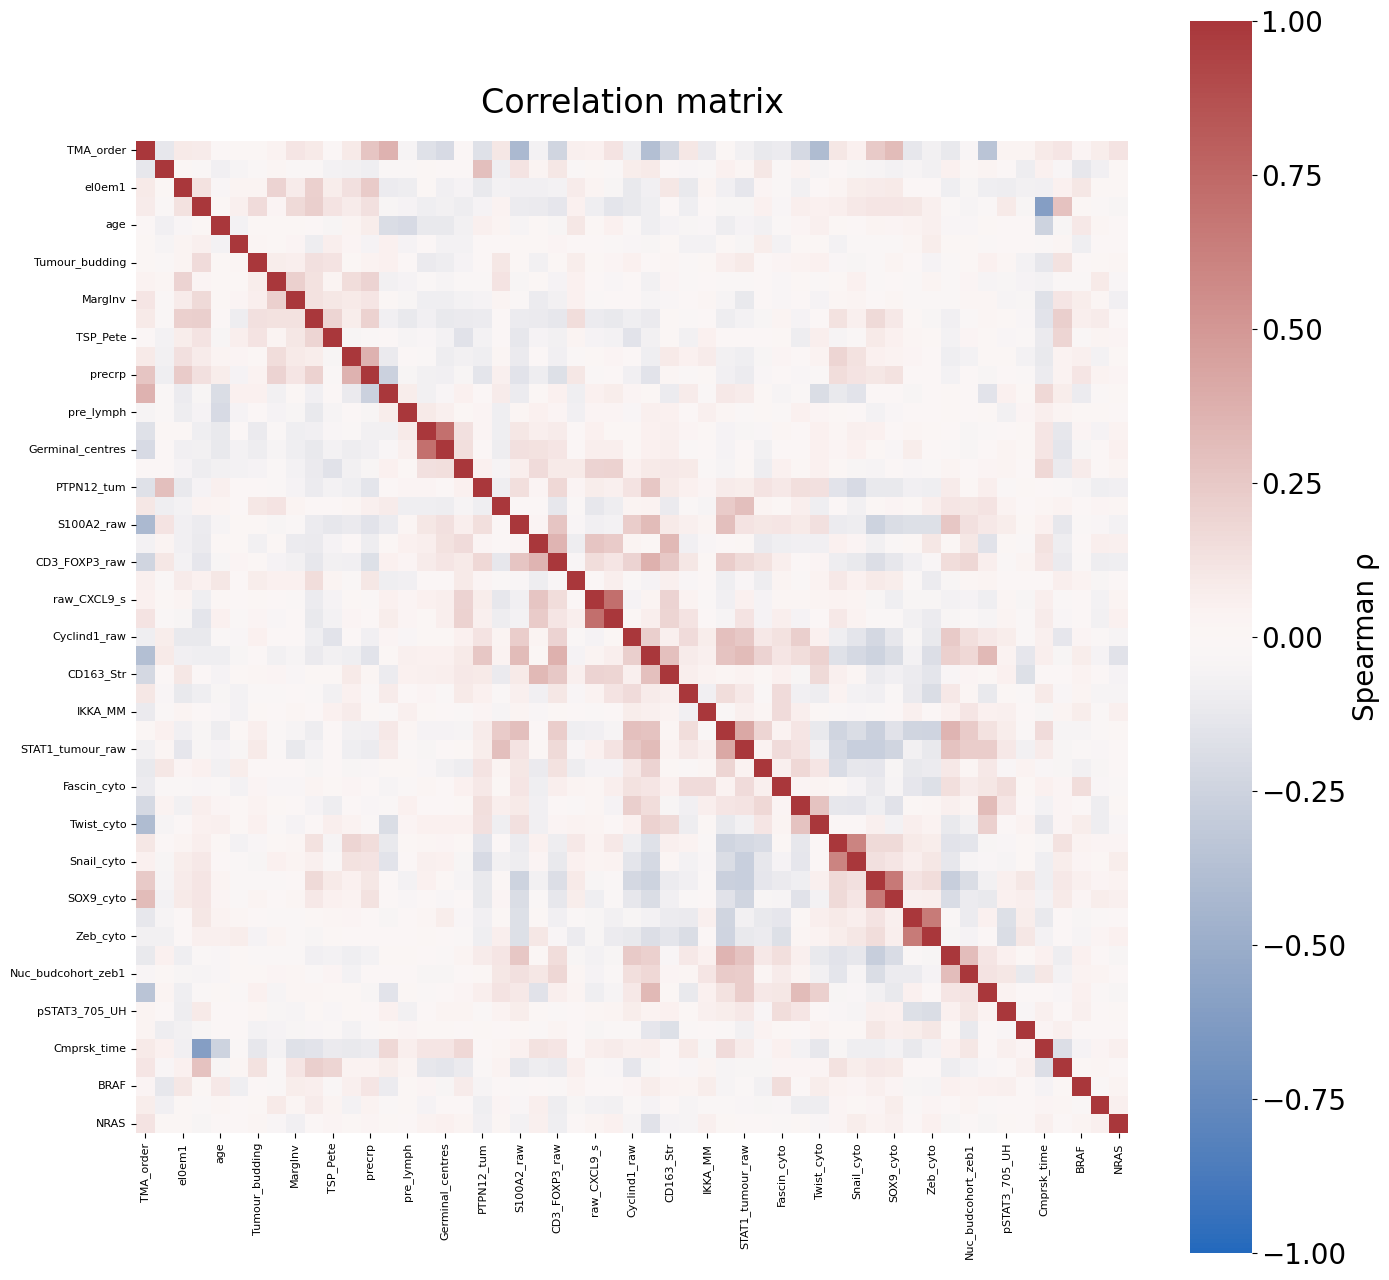

In [370]:
num = df8.select_dtypes(include=[np.number]).copy()
num = num.loc[:, num.nunique(dropna=True) > 1] 
corr = num.corr(method="spearman")

plt.figure(figsize=(16, 16))
ax = sns.heatmap(
    corr, vmin=-1, vmax=1, cmap="vlag", center=0,
    annot=False, square=True, cbar_kws={"label": "Spearman ρ"}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  va="center", fontsize=8)
ax.set_title("Correlation matrix", pad=20)
plt.show()

In [371]:
num = df8.select_dtypes(include=[np.number]).copy()
num = num.loc[:, num.nunique(dropna=True) > 1] 
corr = num.corr(method="spearman")

# Keep only upper triangle (exclude diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Extract correlated pairs > 0.8
high_corr = (
    corr.where(mask)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
        .query("corr > 0.8")
        .sort_values("corr", ascending=False)
)

print(high_corr)

Empty DataFrame
Columns: [var1, var2, corr]
Index: []


In [372]:
df8.shape

(722, 61)

### Class imbalance of categories

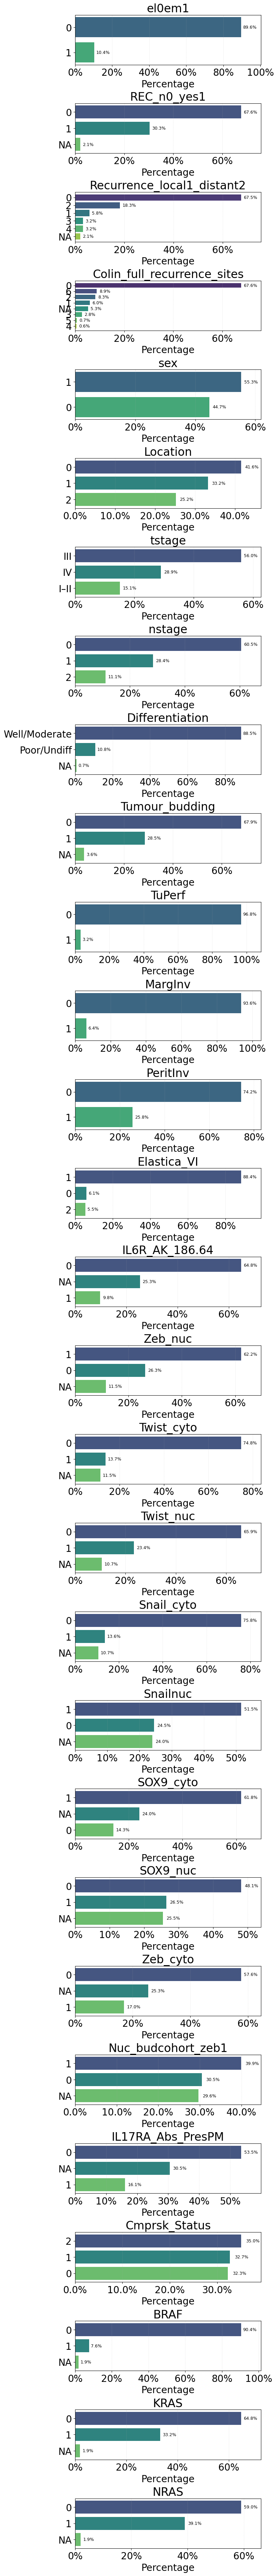

In [373]:

import matplotlib.ticker as mticker


cat = df8.select_dtypes(include=["object", "category", "bool", "int8"]).copy()
n = len(cat.columns)
fig, axes = plt.subplots(nrows=len(cat.columns), ncols=1, figsize=(8, 2.6 * n), constrained_layout=True)

for ax, col in zip(axes, cat.columns):
    vc = cat[col].value_counts(normalize=True, dropna=False)
    order = vc.sort_values(ascending=False).index
    vals = vc.loc[order].values
    labels = [("NA" if pd.isna(x) else str(x)) for x in order]

    sns.barplot(
        x=vals,
        y=labels,
        hue=labels,              # suppresses deprecation warning
        palette="viridis",
        dodge=False,
        legend=False,
        orient="h",
        ax=ax
    )

    ax.set_xlabel("Percentage")
    ax.set_ylabel("")
    ax.set_title(col)
    xmax = max(0.1, vals.max())
    ax.set_xlim(0, xmax * 1.12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.margins(y=0.05)

    for i, v in enumerate(vals):
        ax.text(v + 0.01, i, f"{v*100:.1f}%", va="center", ha="left", fontsize=9, clip_on=False)

plt.show()

Further analysis to be done with Elastica_VI and Venous Invasion, it is referring to the same. 

We can drop covariate if less that 5% counts in a column.

In [374]:
df8 = df8.drop(columns=["TuPerf"])

In [375]:
df8.shape

(722, 60)

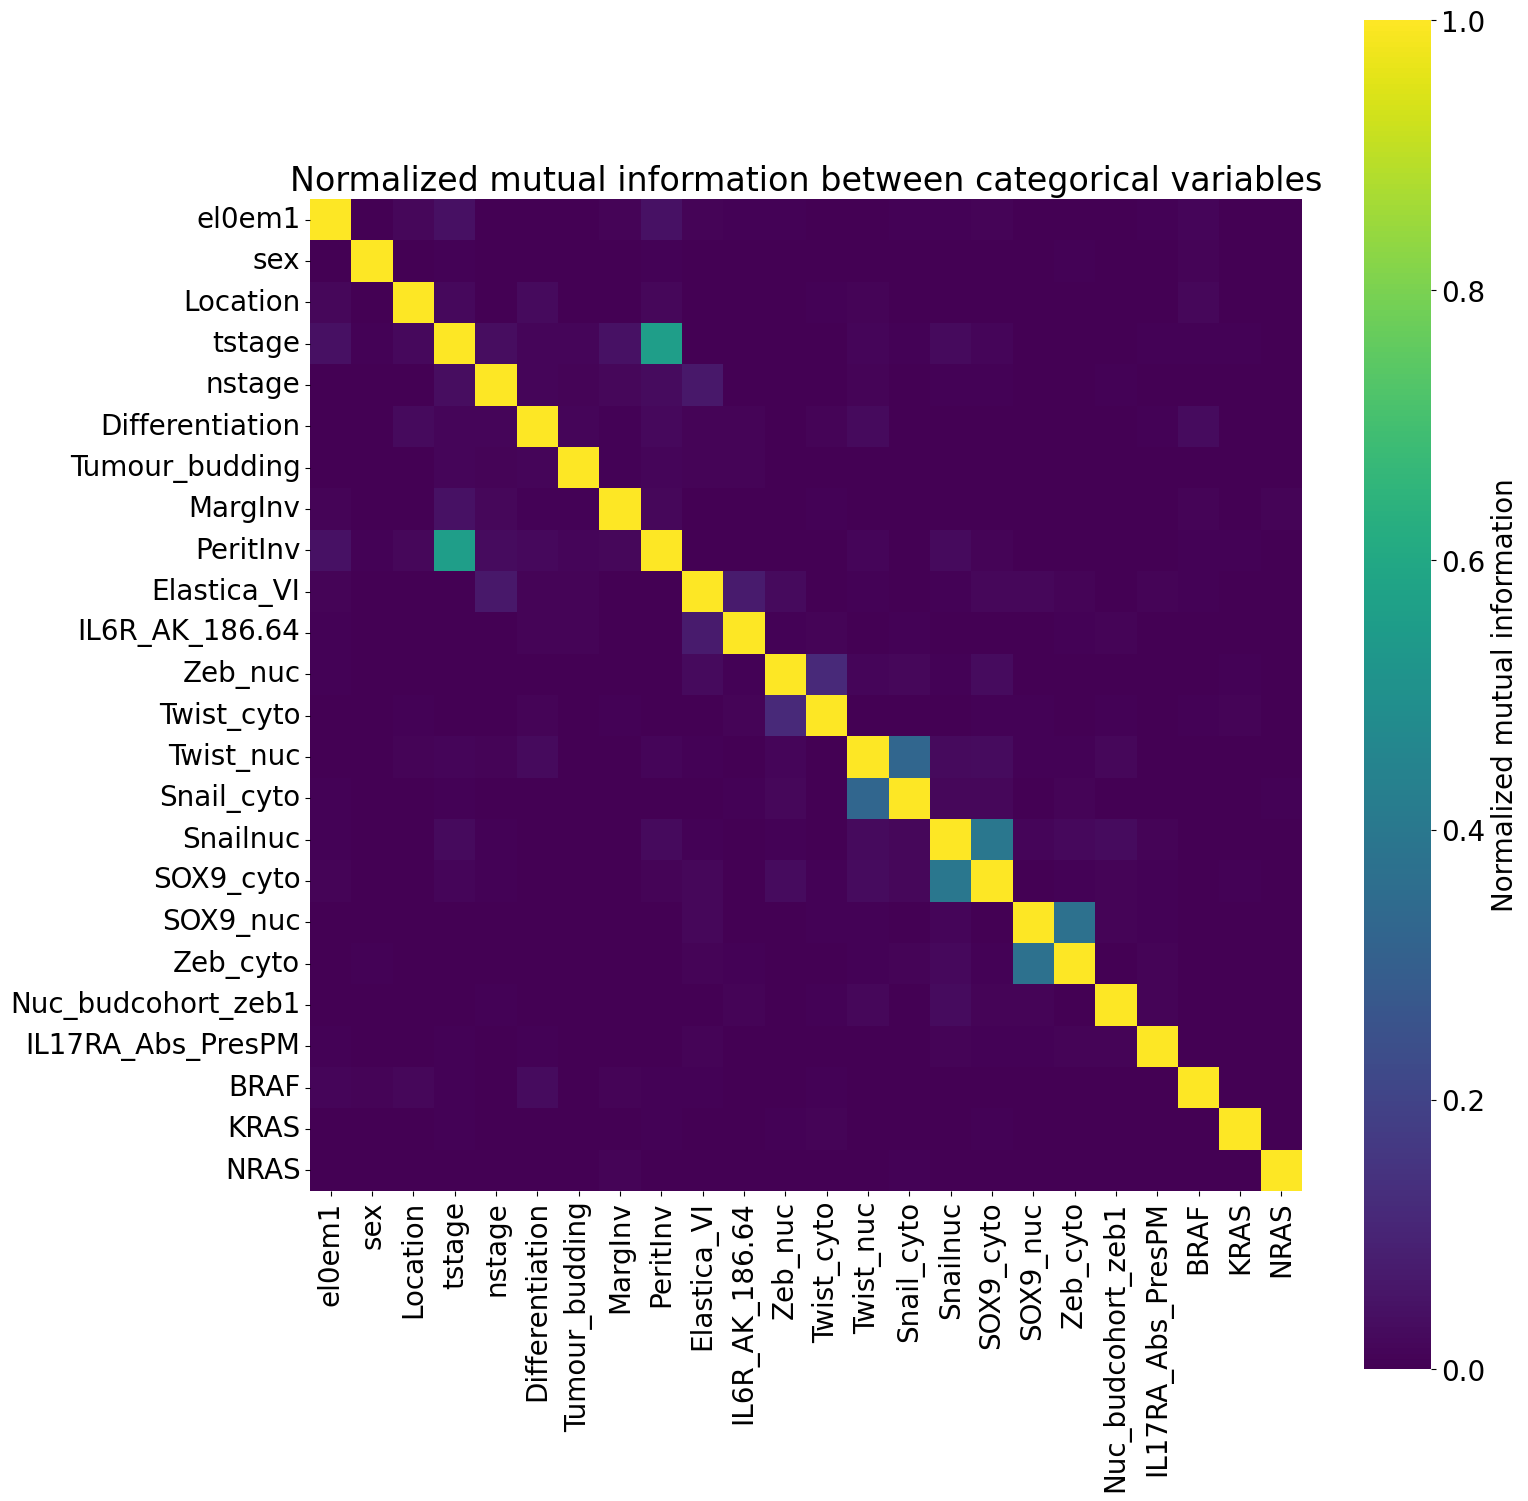

In [376]:
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score

cat = df8.select_dtypes(include=["object", "category", "bool", "int8"]).copy()
cols = cat.columns
cols = cols.drop(["REC_n0_yes1", "Recurrence_local1_distant2", 
          "Colin_full_recurrence_sites", "Cmprsk_Status"])
n = len(cols)

MI = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)
NMI = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

for i in range(n):
    for j in range(i, n):
        sub = cat[[cols[i], cols[j]]].dropna()
        if sub.empty:
            mi_ij = np.nan
            nmi_ij = np.nan
        else:
            x = sub.iloc[:, 0].to_numpy()
            y = sub.iloc[:, 1].to_numpy()

            mi_ij  = mutual_info_score(x, y)
            nmi_ij = normalized_mutual_info_score(x, y)

        MI.iat[i, j] = MI.iat[j, i] = mi_ij
        NMI.iat[i, j] = NMI.iat[j, i] = nmi_ij

np.fill_diagonal(MI.values, 0.0)
np.fill_diagonal(NMI.values, 1.0)

# Diagonal
np.fill_diagonal(MI.values, 0.0)    # MI(X,X) is entropy; often not wanted on diag
np.fill_diagonal(NMI.values, 1.0)   # by definition, NMI(X,X) = 1

plt.figure(figsize=(16, 16))   # adjust if n is large
sns.heatmap(
    NMI,
    cmap="viridis",
    vmin=0, vmax=1,
    square=True,
    cbar_kws={"label": "Normalized mutual information"},
    annot=True if n <= 15 else False,
    fmt=".2f"
)
plt.title("Normalized mutual information between categorical variables")
plt.tight_layout()
plt.show()

In [377]:
ct = pd.crosstab(df8["PeritInv"], df8["tstage"])
print(ct)

tstage    III   IV  I–II
PeritInv                
0         400   27   109
1           4  182     0


### Metadata

We can create some metadata

Sources:

https://pmc.ncbi.nlm.nih.gov/articles/PMC8580263/

https://www.nature.com/articles/s41598-023-28631-y


QPIS data


In [378]:
COL_META = {
    "TMA_order": {"name": "TMA_Order", "origin": "Clinical", "qpis": "no", "collection": "research"},
    "DFS_months_2020": {"name": "Disease_Free_Survival_Months", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "adj1": {"name": "Adjuvant_Therapy", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "el0em1": {"name": "Emergency_Surgery", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "Recurrence_local1_distant2": {"name": "Recurrence_Code_Local1_Distant2", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "Colin_full_recurrence_sites": {"name": "Recurrence_Sites", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "REC_n0_yes1": {"name": "Recurrence_Indicator", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "age": {"name": "Age", "origin": "Clinical", "qpis": "no", "collection": "routine"},
    "sex": {"name": "Sex", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "Location": {"name": "Tumour_Location", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "Dukes": {"name": "Dukes_Stage", "origin": "Staging", "qpis": "no", "collection": "routine"},
    "tstage": {"name": "T_Stage", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "nstage": {"name": "N_Stage", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    "mstage": {"name": "M_Stage", "origin": "Clinical", "qpis": "yes", "collection": "routine"},
    # derived for this analysis
    "Cmprsk_Status": {"name": "Outcome", "origin": "Clinical", "qpis": "yes", "collection": "research"},
    "Cmprsk_time": {"name": "Time", "origin": "Clinical", "qpis": "yes", "collection": "routine"},

    # blood - Laboratory
    "Neut": {"name": "Neutrophils", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "lymph": {"name": "Lymphocytes", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "precrp": {"name": "Preoperative_CRP", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "prealb": {"name": "Preoperative_Albumin", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "crp": {"name": "CRP", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "pre_lymph": {"name": "Preoperative_Lymphocytes", "origin": "Laboratory", "qpis": "no", "collection": "routine"},
    "LNratio": {"name": "Lymph_Node_Ratio", "origin": "Laboratory", "qpis": "yes", "collection": "research"},

    # pathology 
    "Lymphoid_aggregates": {"name": "Lymphoid_Aggregates", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "Germinal_centres": {"name": "Germinal_Centres", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "IE_Lymphocytes": {"name": "Intraepithelial_Lymphocytes", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "ImageAnalysis_Ki67": {"name": "Ki67_Image_Analysis", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "Differentiation": {"name": "Histological_Grade", "origin": "Pathology", "qpis": "yes", "collection": "routine"},
    "Tumour_budding": {"name": "Tumour_Budding", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "TuPerf": {"name": "Tumour_Perforation", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "MargInv": {"name": "Margin_Invasion", "origin": "Pathology", "qpis": "yes", "collection": "routine"}, # if qpis then routine
    "venousinv": {"name": "Venous_Invasion", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "PeritInv": {"name": "Peritoneal_Invasion", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "TSP_Pete": {"name": "Tumour_Stroma_Percentage", "origin": "Pathology", "qpis": "no", "collection": "research"},
    "Elastica_VI": {"name": "Elastica_Venous_Invasion", "origin": "Pathology", "qpis": "no", "collection": "research"},

    # multiplex
    "CD3_raw": {"name": "CD3", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD3_FOXP3_raw": {"name": "CD3_FOXP3", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD68_raw": {"name": "CD68", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD163_Str": {"name": "CD163_Stroma", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD66b": {"name": "CD66b", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},
    "CD3FOXP3_raw": {"name": "CD3FOXP3", "origin": "MultiplexIF", "qpis": "no", "collection": "research"},

    # origin is RNAScope (Kat  modification)
    "raw_CXCL9_s": {"name": "CXCL9", "origin": "RNAScope", "qpis": "no", "collection": "research"},
    "raw_CXCL10_s": {"name": "CXCL10", "origin": "RNAScope", "qpis": "no", "collection": "research"},

    # inmunohistochemistry:
    "PTPN12_tum": {"name": "PTPN12_Tumour", "origin": "IHC", "qpis": "no", "collection": "research"},
    "PTPN12_stroma": {"name": "PTPN12_Stroma", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IL6R_AK_186.64": {"name": "IL6R_AK_186_64", "origin": "IHC", "qpis": "no", "collection": "research"},
    "S100A2_raw": {"name": "S100A2", "origin": "IHC", "qpis": "no", "collection": "research"},

    "Cyclind1_raw": {"name": "CyclinD1", "origin": "IHC", "qpis": "no", "collection": "research"},
    "KI67_t": {"name": "Ki67_Tumour", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IKKA_MM": {"name": "IKK_Alpha", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IKK_Beta_MM": {"name": "IKK_Beta", "origin": "IHC", "qpis": "no", "collection": "research"},
    "STAT1_tumour_raw": {"name": "STAT1_Tumour", "origin": "IHC", "qpis": "no", "collection": "research"},

    "Bcat_Cyto": {"name": "BetaCatenin_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Bcat_Nuc": {"name": "BetaCatenin_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Bcat_Mem": {"name": "BetaCatenin_Membranous", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Fascin_cyto": {"name": "Fascin_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Zeb_nuc": {"name": "ZEB1_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Twist_cyto": {"name": "Twist_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Twist_nuc": {"name": "Twist_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Snail_cyto": {"name": "Snail_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Snailnuc": {"name": "Snail_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SOX9_cyto": {"name": "SOX9_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SOX9_nuc": {"name": "SOX9_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Zeb_cyto": {"name": "ZEB1_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Cyto_NS": {"name": "SMAD4_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Nu_NS": {"name": "SMAD4_Nucleus", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Stroma_Cyto": {"name": "SMAD4_Stroma_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "SMAD4_Stroma_Nu": {"name": "SMAD4_Stroma_Nucleus", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Cyto_budcohort_Zeb11_A": {"name": "BudCohort_ZEB1_Cytoplasmic", "origin": "IHC", "qpis": "no", "collection": "research"},
    "Nuc_budcohort_zeb1": {"name": "BudCohort_ZEB1_Nuclear", "origin": "IHC", "qpis": "no", "collection": "research"},
    "NPM1_GK": {"name": "NPM1", "origin": "IHC", "qpis": "no", "collection": "research"},
    "pSTAT3_705_UH": {"name": "pSTAT3_Y705", "origin": "IHC", "qpis": "no", "collection": "research"},
    "IL17RA_Abs_PresPM": {"name": "IL17RA_Presence", "origin": "IHC", "qpis": "no", "collection": "research"},
    "MMR_Status_Jen": {"name": "MMR_Status", "origin": "IHC", "qpis": "yes", "collection": "routine"},
    
    # genetics
    "BRAF": {"name": "BRAF", "origin": "Genetics", "qpis": "yes", "collection": "routine"},
    "KRAS": {"name": "KRAS", "origin": "Genetics", "qpis": "no", "collection": "research"},
    "NRAS": {"name": "NRAS", "origin": "Genetics", "qpis": "no", "collection": "research"},
}


In [379]:
### Updating metadata file
meta_df = pd.DataFrame.from_dict(COL_META).T.rename(columns={"name": "New Data Item", "origin": "Origin", "qpis": "Qpis", "collection": "Collection"})

meta_df

,New Data Item,Origin,Qpis,Collection
TMA_order,TMA_Order,Clinical,no,research
DFS_months_2020,Disease_Free_Survival_Months,Clinical,yes,routine
adj1,Adjuvant_Therapy,Clinical,no,routine
el0em1,Emergency_Surgery,Clinical,no,routine
Recurrence_local1_distant2,Recurrence_Code_Local1_Distant2,Clinical,no,routine
...,...,...,...,...
IL17RA_Abs_PresPM,IL17RA_Presence,IHC,no,research
MMR_Status_Jen,MMR_Status,IHC,yes,routine
BRAF,BRAF,Genetics,yes,routine
KRAS,KRAS,Genetics,no,research


In [380]:
## old metadata
meta2 = pd.read_excel("data/GRI_FullDataset.xlsx", sheet_name = "MetaData")

meta2.head()

,Data Item,Present in SESCD,Present in SOCCS,Present SMR06,DERIVED,Data Item Description,Data Item Entry,Units,Notes
0,TMA_order,NaN,NaN,NaN,NaN,Tissue Mircoarray (TMA) order,NaN,integer,TMAs have hundreds of tissue samples arrayed o...
1,TMA_number,NaN,NaN,NaN,NaN,Tissue Mircoarray (TMA) number,NaN,character,The number given to Microarray slide patient t...
2,CSS_months_2020,?DODeath_FINAL AND AnyRecurrenceDate,NaN,NaN,NaN,Cancer Specific Survival in Months,NaN,integer,Number of months from date of surgery (dofsurg...
3,UpdateJuly2020_a0_cd1_ncd2,eventall AND event_CRC AND event_other,NaN,NaN,NaN,Event Indicator,"0 == Alive, 1 == Cancer Cause of Death, 2 == O...",integer,"Patient event indicator, or status, as of July..."
4,neoadj1,NaN,NaN,NaN,NaN,Neoadjuvant Therapy,"0 == not received neoadjuvant, 1 == received n...",binary,"Neoadj == chemo/radio-therapy before surgery, ..."


In [381]:
## merge
meta3 = pd.merge(meta2[["Data Item", "Data Item Description", "Data Item Entry", "Notes"]], meta_df, left_on= "Data Item", right_index=True, how="right")

meta3

,Data Item,Data Item Description,Data Item Entry,Notes,New Data Item,Origin,Qpis,Collection
0.0,TMA_order,Tissue Mircoarray (TMA) order,NaN,TMAs have hundreds of tissue samples arrayed o...,TMA_Order,Clinical,no,research
8.0,DFS_months_2020,"Disease Free Survival Status (last check, i.e....",NaN,Number of months from date of surgery (dofsurg...,Disease_Free_Survival_Months,Clinical,yes,routine
13.0,adj1,Adjuvant Therapy,"0 == not received adjuvant treatment, 1 == rec...",Treatment given after the main treatment to re...,Adjuvant_Therapy,Clinical,no,routine
14.0,el0em1,Elective Surgery,"0 == elective, 1 == emergency",has the patient undergone emergency or plan su...,Emergency_Surgery,Clinical,no,routine
23.0,Recurrence_local1_distant2,Recurrence,"0 == no recurrence, 1 == local, 2 == distant, ...",Recurrent cancer starts with cancer cells that...,Recurrence_Code_Local1_Distant2,Clinical,no,routine
...,...,...,...,...,...,...,...,...
206.0,IL17RA_Abs_PresPM,NaN,"0 == absent, 1 == present",for protein,IL17RA_Presence,IHC,no,research
12.0,MMR_Status_Jen,Mismatch Repair Status,"1 == MMR deficient, 2 == MMR proficient, 3 == ...",All newly diagnosed CRC patients should have t...,MMR_Status,IHC,yes,routine
NaN,BRAF,NaN,NaN,NaN,BRAF,Genetics,yes,routine
NaN,KRAS,NaN,NaN,NaN,KRAS,Genetics,no,research


In [382]:
# adding the modified dtypes and missigness
dtypes_df = pd.DataFrame(df6.dtypes, columns=["Data Type"])

dtypes_df["% Missing"] = df6.isna().mean().mul(100).round(2)

dtypes_df.head()

,Data Type,% Missing
TMA_order,int64,0.00
MMR_Status_Jen,float64,18.01
el0em1,Int8,0.00
REC_n0_yes1,Int8,2.08
Recurrence_local1_distant2,category,2.08


In [383]:
# merge
meta4 = pd.merge(meta3, dtypes_df, left_on="Data Item", right_index=True)
meta4 = meta4.reset_index(drop=True)

meta4.head()

,Data Item,Data Item Description,Data Item Entry,Notes,New Data Item,Origin,Qpis,Collection,Data Type,% Missing
0,TMA_order,Tissue Mircoarray (TMA) order,NaN,TMAs have hundreds of tissue samples arrayed o...,TMA_Order,Clinical,no,research,int64,0.00
1,el0em1,Elective Surgery,"0 == elective, 1 == emergency",has the patient undergone emergency or plan su...,Emergency_Surgery,Clinical,no,routine,Int8,0.00
2,Recurrence_local1_distant2,Recurrence,"0 == no recurrence, 1 == local, 2 == distant, ...",Recurrent cancer starts with cancer cells that...,Recurrence_Code_Local1_Distant2,Clinical,no,routine,category,2.08
3,Colin_full_recurrence_sites,Recurrence Site,"0 == none, 1 == local, 2 == liver, 3 == lung, ...",Categorical description capturing general site...,Recurrence_Sites,Clinical,no,routine,category,5.26
4,REC_n0_yes1,Recurrence,"0 == no recurrence, 1 == recurrence",Binary variable indicating recurrence of cance...,Recurrence_Indicator,Clinical,no,routine,Int8,2.08


In [384]:
# saving
meta4.to_csv("data/GRI_preprocess-1-meta.csv")

Correct names in dataset

In [385]:
# simple mapping (exact column names as you said)
mapping = (meta4[["Data Item", "New Data Item"]]
           .dropna()
           .assign(**{
               "Data Item": lambda d: d["Data Item"].astype(str).str.strip(),
               "New Data Item": lambda d: d["New Data Item"].astype(str).str.strip()
           })
           .query("`New Data Item` != ''")
           .set_index("Data Item")["New Data Item"]
           .to_dict())

# apply
df9 = df8.rename(columns=mapping)


In [386]:
df9

,TMA_Order,MMR_Status,Emergency_Surgery,Recurrence_Indicator,Recurrence_Code_Local1_Distant2,Recurrence_Sites,Age,Sex,Tumour_Location,T_Stage,N_Stage,Histological_Grade,Tumour_Budding,Margin_Invasion,Peritoneal_Invasion,Tumour_Stroma_Percentage,Neutrophils,Preoperative_CRP,Preoperative_Albumin,Elastica_Venous_Invasion,Preoperative_Lymphocytes,Lymphoid_Aggregates,Germinal_Centres,Intraepithelial_Lymphocytes,PTPN12_Tumour,IL6R_AK_186_64,S100A2,CD3,CD3_FOXP3,CD68,CXCL9,CXCL10,CyclinD1,Ki67_Tumour,CD163_Stroma,CD66b,IKK_Alpha,IKK_Beta,STAT1_Tumour,BetaCatenin_Nuclear,Fascin_Cytoplasmic,ZEB1_Nuclear,Twist_Cytoplasmic,Twist_Nuclear,Snail_Cytoplasmic,Snail_Nuclear,SOX9_Cytoplasmic,SOX9_Nuclear,ZEB1_Cytoplasmic,SMAD4_Nucleus,BudCohort_ZEB1_Nuclear,NPM1,pSTAT3_Y705,IL17RA_Presence,Time,Lymph_Node_Ratio,Outcome,BRAF,KRAS,NRAS
0,1,1.0,0,0,0,0,67.0,1,1,III,0,Well/Moderate,0,0,0,30.0,6.3,11.0,35.0,1,1600.0,13.0,4.0,1.6,49.49,0,103.0,5.63,2.17,5.07,0.21,0.35,65.00,25.81,14.27,0.86,118.25,1.26,121.45,23.0,23.0,1,1,0,0,0,0,0,0,0.00,0,135.82,3.67,<NA>,97.0,0.000,0,0,0,0
1,2,NaN,0,0,0,0,78.0,1,1,III,0,Well/Moderate,0,0,0,70.0,3.5,2.0,35.0,1,1400.0,14.0,0.0,1.6,0.00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.68,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,0,NaN,NaN,<NA>,97.0,0.000,0,0,1,0
2,3,2.0,0,1,2,6,64.0,1,0,III,2,Well/Moderate,1,0,0,30.0,4.3,8.2,34.0,1,2100.0,17.0,3.0,1.8,40.02,0,113.0,3.85,2.16,3.79,1.33,2.02,100.00,44.54,11.05,4.87,88.35,2.94,184.38,8.0,6.0,1,1,0,0,1,1,<NA>,<NA>,0.69,0,NaN,106.69,<NA>,25.0,0.375,1,0,1,0
3,4,2.0,0,0,0,0,85.0,1,1,III,0,Well/Moderate,1,0,0,50.0,8.9,9.0,33.0,1,700.0,11.0,0.0,2.7,89.35,<NA>,102.0,16.17,11.15,4.97,4.89,3.22,76.67,24.43,26.14,11.14,101.83,19.74,99.86,25.0,6.0,1,1,0,0,1,1,0,1,0.13,0,133.14,152.01,<NA>,83.0,0.000,2,0,0,1
4,5,2.0,0,0,0,0,57.0,1,1,I–II,0,Well/Moderate,0,0,0,30.0,4.5,1.4,36.0,1,1800.0,0.0,0.0,1.1,100.93,0,105.0,1.43,3.60,1.51,0.38,0.72,125.00,61.50,1.86,7.05,149.48,10.38,134.66,38.0,1.0,1,1,0,0,0,0,0,0,16.12,1,173.53,96.60,<NA>,97.0,0.000,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
717,781,2.0,0,0,0,0,68.0,0,1,III,0,Well/Moderate,0,0,0,30.0,2.7,6.0,36.0,1,1800.0,7.0,1.0,1.8,69.24,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,117.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,0,0,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,7.30,<NA>,171.0,0.000,0,0,0,0
718,782,2.0,0,0,0,0,66.0,1,1,I–II,0,Well/Moderate,0,0,0,NaN,3.6,6.0,43.0,1,1400.0,NaN,NaN,NaN,57.08,<NA>,100.0,4.19,3.28,1.00,0.70,0.38,NaN,7.28,0.47,12.59,76.31,103.08,NaN,4.0,2.0,1,0,0,0,1,1,0,0,13.87,1,NaN,0.00,<NA>,104.0,0.000,2,0,0,0
719,784,2.0,0,0,0,0,78.0,0,2,III,0,Well/Moderate,0,0,0,NaN,4.2,19.0,42.0,1,2700.0,NaN,NaN,NaN,26.80,<NA>,100.0,NaN,NaN,NaN,4.76,7.61,NaN,NaN,NaN,NaN,107.92,NaN,NaN,NaN,26.0,<NA>,<NA>,1,1,<NA>,<NA>,<NA>,<NA>,9.50,<NA>,NaN,80.56,<NA>,145.0,0.000,2,0,1,1
720,785,2.0,1,0,0,0,75.0,1,1,III,2,Well/Moderate,0,0,0,NaN,7.2,20.0,36.0,1,1200.0,NaN,NaN,NaN,25.56,0,100.0,NaN,NaN,NaN,1.23,2.64,NaN,NaN,NaN,13.26,NaN,85.03,NaN,NaN,1.0,1,0,0,0,1,1,0,0,31.34,<NA>,NaN,36.89,<NA>,53.0,0.600,2,0,1,1


In [387]:
#df8.to_csv("data/GRI_preprocess-1.csv")
#df8.to_csv("data/GRI_preprocess-1.csv")

In [388]:
df10 = smart_fix_dtypes(df9, cat_threshold=10)

df10 = df10.drop(columns=["Recurrence_Code_Local1_Distant2", "Recurrence_Sites", "Recurrence_Indicator"], axis=1)


In [389]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   TMA_Order                    722 non-null    int64   
 1   MMR_Status                   592 non-null    Int8    
 2   Emergency_Surgery            722 non-null    Int8    
 3   Age                          722 non-null    float64 
 4   Sex                          722 non-null    Int8    
 5   Tumour_Location              722 non-null    category
 6   T_Stage                      722 non-null    category
 7   N_Stage                      722 non-null    category
 8   Histological_Grade           717 non-null    category
 9   Tumour_Budding               696 non-null    Int8    
 10  Margin_Invasion              722 non-null    Int8    
 11  Peritoneal_Invasion          722 non-null    Int8    
 12  Tumour_Stroma_Percentage     696 non-null    float64 
 13  Neutr

In [390]:
df10.to_csv("data/GRI_preprocess-2.csv")

In [391]:
df10.shape

(722, 57)

In [392]:
print(df10.columns.to_list())

['TMA_Order', 'MMR_Status', 'Emergency_Surgery', 'Age', 'Sex', 'Tumour_Location', 'T_Stage', 'N_Stage', 'Histological_Grade', 'Tumour_Budding', 'Margin_Invasion', 'Peritoneal_Invasion', 'Tumour_Stroma_Percentage', 'Neutrophils', 'Preoperative_CRP', 'Preoperative_Albumin', 'Elastica_Venous_Invasion', 'Preoperative_Lymphocytes', 'Lymphoid_Aggregates', 'Germinal_Centres', 'Intraepithelial_Lymphocytes', 'PTPN12_Tumour', 'IL6R_AK_186_64', 'S100A2', 'CD3', 'CD3_FOXP3', 'CD68', 'CXCL9', 'CXCL10', 'CyclinD1', 'Ki67_Tumour', 'CD163_Stroma', 'CD66b', 'IKK_Alpha', 'IKK_Beta', 'STAT1_Tumour', 'BetaCatenin_Nuclear', 'Fascin_Cytoplasmic', 'ZEB1_Nuclear', 'Twist_Cytoplasmic', 'Twist_Nuclear', 'Snail_Cytoplasmic', 'Snail_Nuclear', 'SOX9_Cytoplasmic', 'SOX9_Nuclear', 'ZEB1_Cytoplasmic', 'SMAD4_Nucleus', 'BudCohort_ZEB1_Nuclear', 'NPM1', 'pSTAT3_Y705', 'IL17RA_Presence', 'Time', 'Lymph_Node_Ratio', 'Outcome', 'BRAF', 'KRAS', 'NRAS']


In [393]:
df6.columns

Index(['TMA_order', 'MMR_Status_Jen', 'el0em1', 'REC_n0_yes1',
       'Recurrence_local1_distant2', 'Colin_full_recurrence_sites', 'age',
       'sex', 'Location', 'tstage', 'nstage', 'Differentiation',
       'Tumour_budding', 'TuPerf', 'MargInv', 'PeritInv', 'TSP_Pete', 'Neut',
       'lymph', 'precrp', 'prealb', 'Elastica_VI', 'crp', 'pre_lymph',
       'Lymphoid_aggregates', 'Germinal_centres', 'IE_Lymphocytes',
       'PTPN12_tum', 'PTPN12_stroma', 'IL6R_AK_186.64', 'S100A2_raw',
       'CD3_raw', 'CD3_FOXP3_raw', 'CD68_raw', 'raw_CXCL9_s', 'raw_CXCL10_s',
       'Cyclind1_raw', 'KI67_t', 'CD163_Str', 'CD66b', 'IKKA_MM',
       'IKK_Beta_MM', 'STAT1_tumour_raw', 'Bcat_Cyto', 'Bcat_Nuc', 'Bcat_Mem',
       'Fascin_cyto', 'Zeb_nuc', 'Twist_cyto', 'Twist_nuc', 'Snail_cyto',
       'Snailnuc', 'SOX9_cyto', 'SOX9_nuc', 'Zeb_cyto', 'SMAD4_Cyto_NS',
       'SMAD4_Nu_NS', 'SMAD4_Stroma_Cyto', 'SMAD4_Stroma_Nu',
       'Cyto_budcohort_Zeb11_A', 'Nuc_budcohort_zeb1', 'NPM1_GK',
       'pSTA

#### Get the plots for the thesis with right names

In [394]:
df11 = df6.copy()

df11 = df11.rename(columns=mapping).drop(columns=["Recurrence_Indicator"])

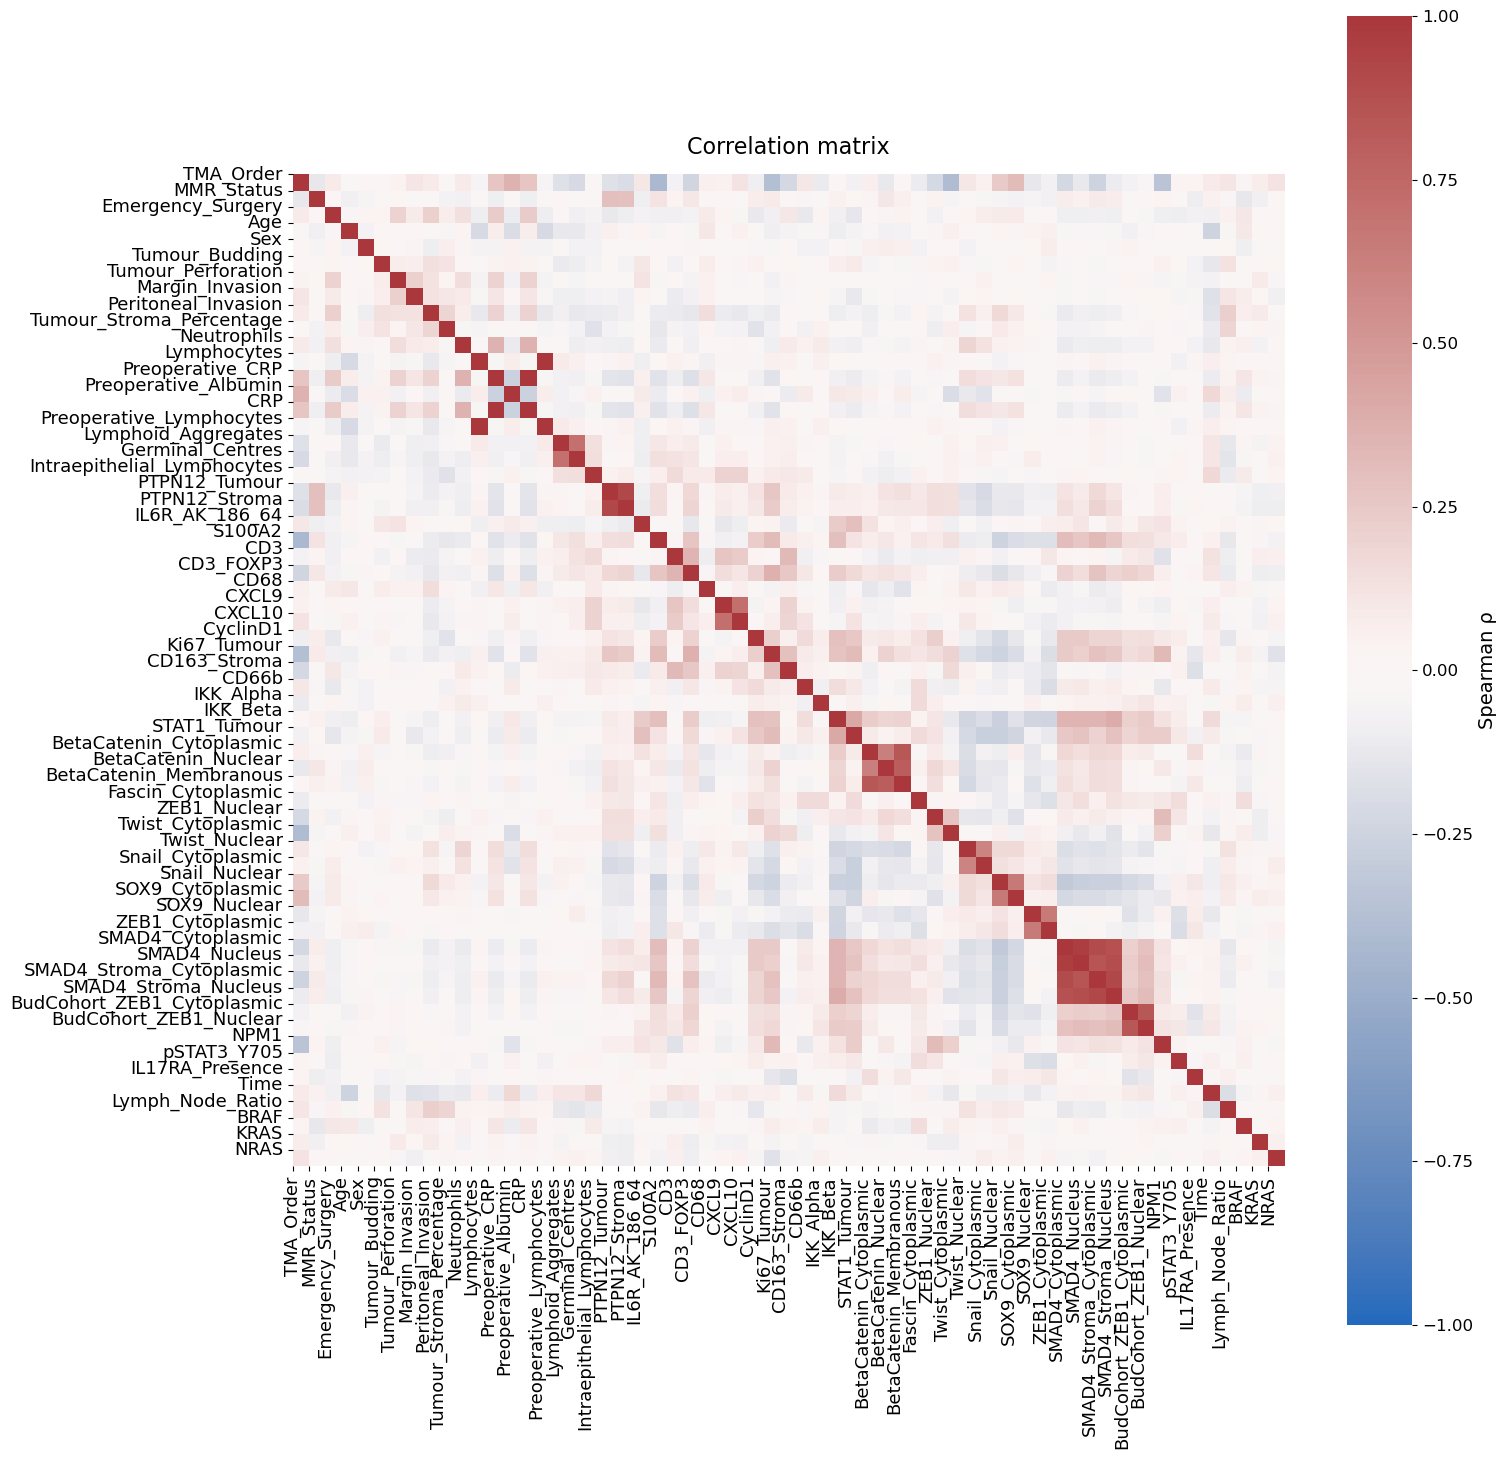

In [395]:

num = df11.select_dtypes(include=[np.number]).copy()
num = num.loc[:, num.nunique(dropna=True) > 1] 
corr = num.corr(method="spearman")

plt.figure(figsize=(16, 17))
ax = sns.heatmap(
    corr, vmin=-1, vmax=1, cmap="vlag", center=0,
    annot=False, square=True, cbar_kws={"label": "Spearman ρ"}
)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, ha="center", fontsize=13)

ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, rotation=0, va="center", fontsize=13)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Spearman ρ", fontsize=14)
ax.set_title("Correlation matrix", pad=15, fontsize=16)
plt.show()

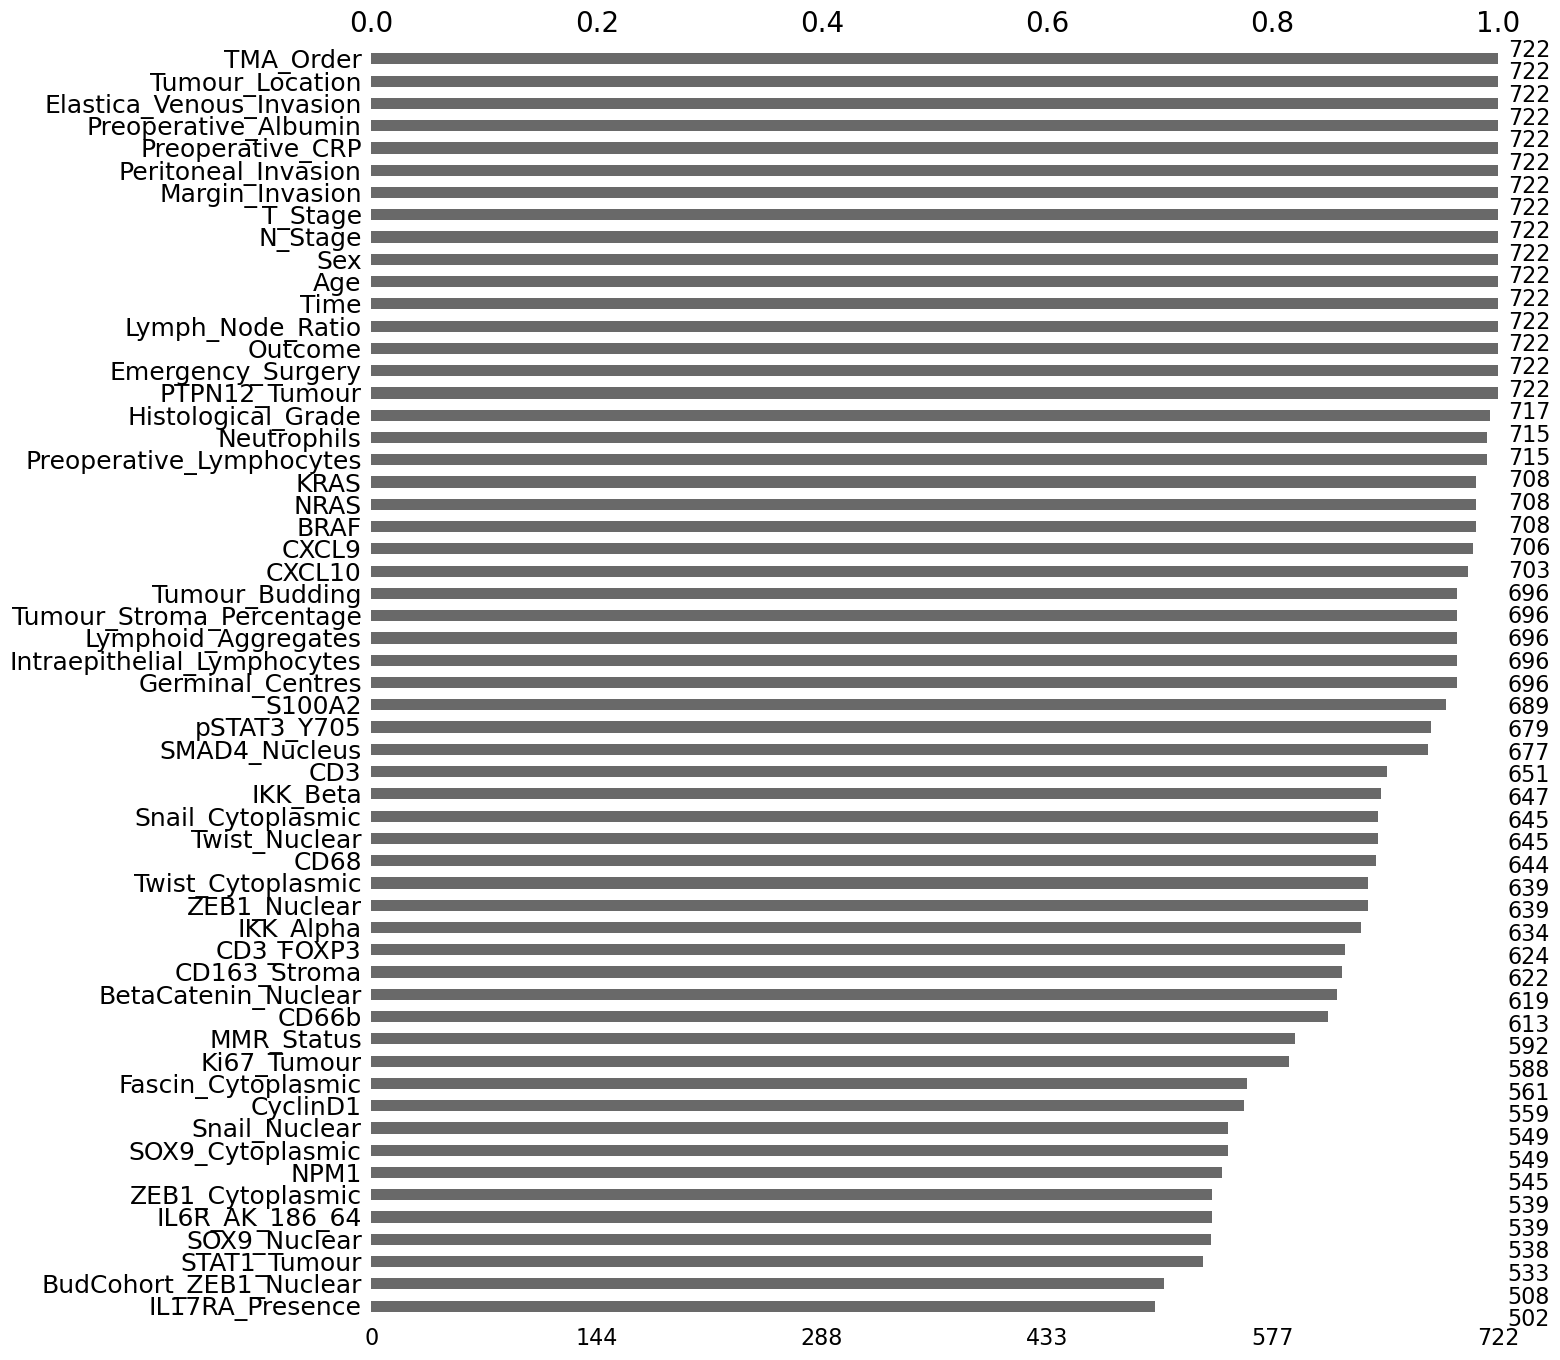

In [396]:
plt.rcParams.update({
    "figure.figsize": (16, 14),
    "font.size": 20,          # base
})

fig, ax = plt.subplots()

ax = msno.bar(df10, sort="ascending", ax=ax)

# Increase y tick label size if needed
ax.tick_params(axis="y", labelsize=18)

# Increase the numbers printed above the bars
for txt in ax.texts:
    txt.set_fontsize(14)

plt.tight_layout()
plt.show()

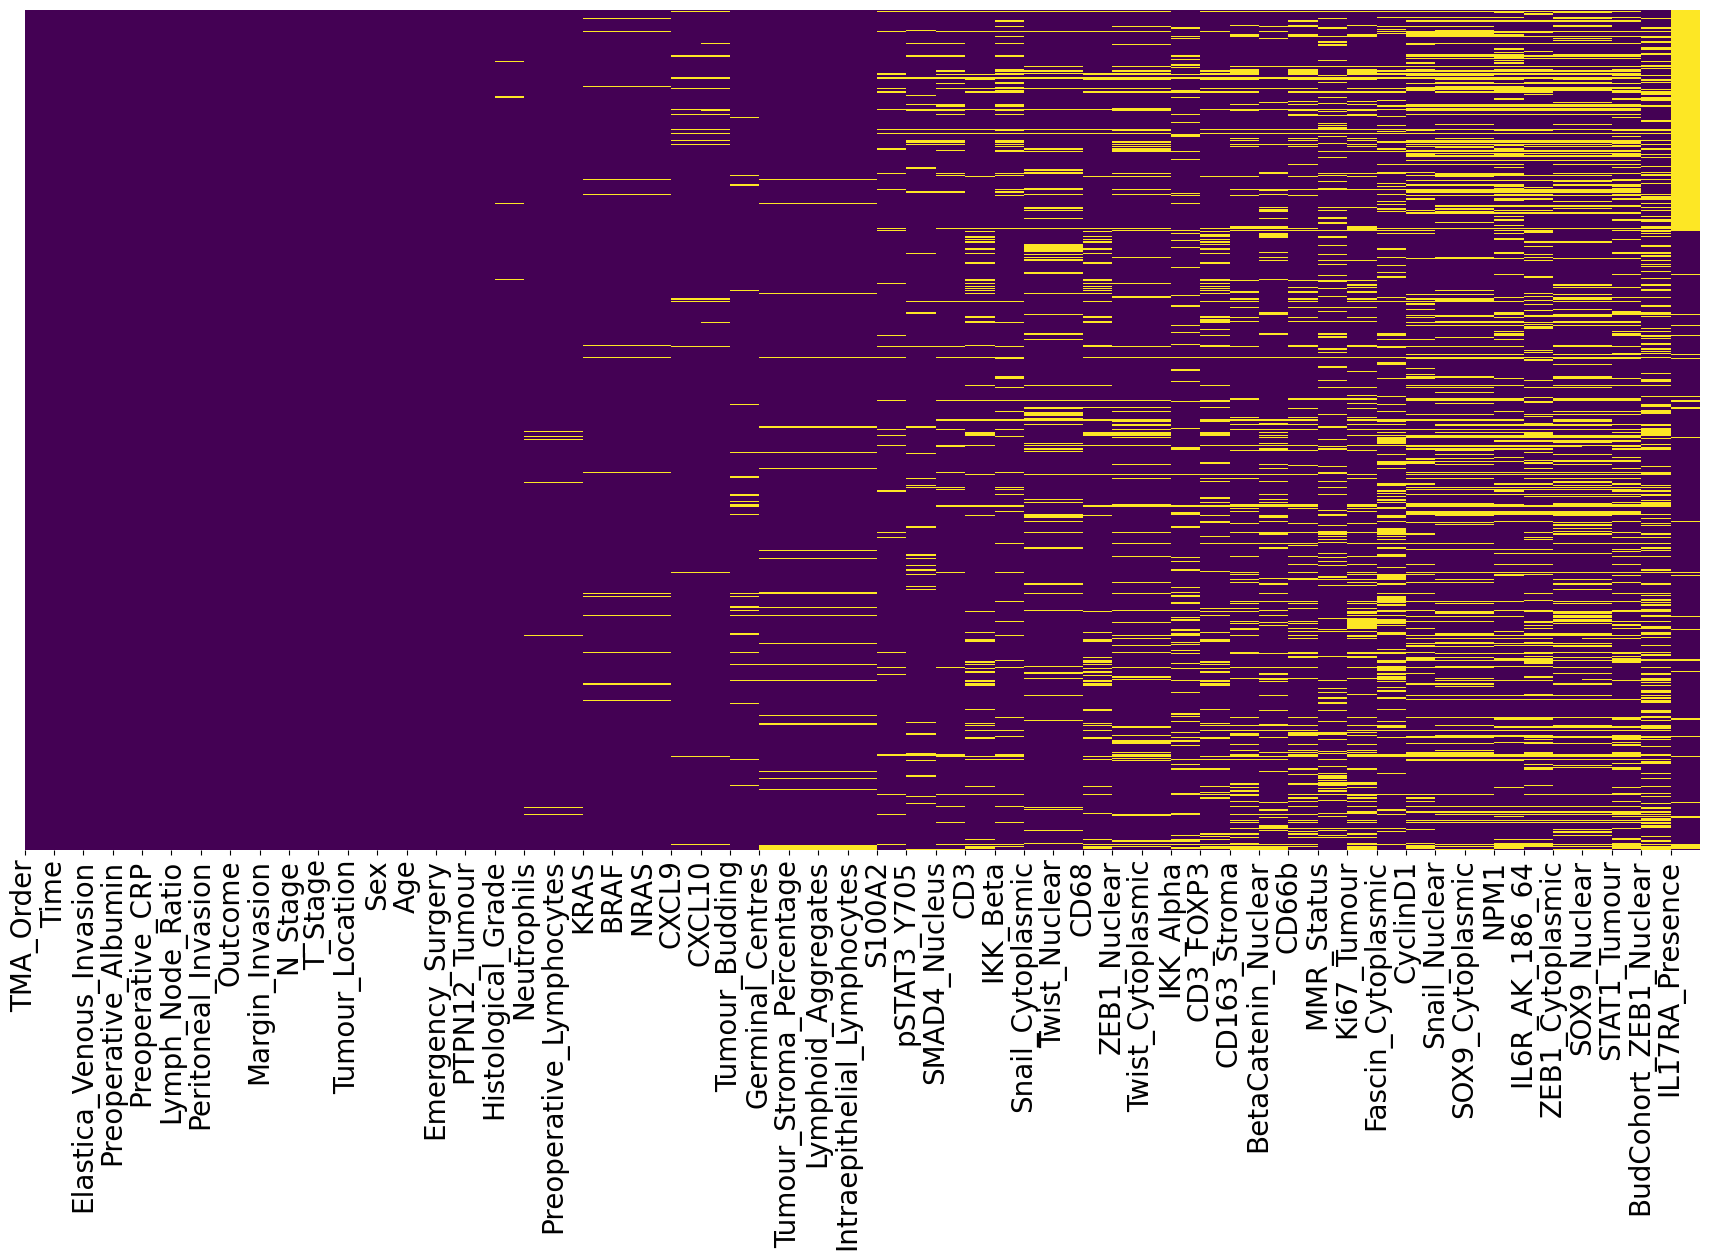

In [397]:
plt.figure(figsize=(17.5, 13))

missing_order = df10.isna().mean().sort_values()

df10_sorted = df10[missing_order.index]
ax = sns.heatmap(df10_sorted.isna(), cbar=False, cmap="viridis")

ax.set_xticks(range(len(df10_sorted.columns)))
ax.set_xticklabels(df10_sorted.columns, rotation=90, ha="center", fontsize=20)
ax.set_yticks([])
plt.tight_layout()
plt.show()


In [398]:
df10.columns

Index(['TMA_Order', 'MMR_Status', 'Emergency_Surgery', 'Age', 'Sex',
       'Tumour_Location', 'T_Stage', 'N_Stage', 'Histological_Grade',
       'Tumour_Budding', 'Margin_Invasion', 'Peritoneal_Invasion',
       'Tumour_Stroma_Percentage', 'Neutrophils', 'Preoperative_CRP',
       'Preoperative_Albumin', 'Elastica_Venous_Invasion',
       'Preoperative_Lymphocytes', 'Lymphoid_Aggregates', 'Germinal_Centres',
       'Intraepithelial_Lymphocytes', 'PTPN12_Tumour', 'IL6R_AK_186_64',
       'S100A2', 'CD3', 'CD3_FOXP3', 'CD68', 'CXCL9', 'CXCL10', 'CyclinD1',
       'Ki67_Tumour', 'CD163_Stroma', 'CD66b', 'IKK_Alpha', 'IKK_Beta',
       'STAT1_Tumour', 'BetaCatenin_Nuclear', 'Fascin_Cytoplasmic',
       'ZEB1_Nuclear', 'Twist_Cytoplasmic', 'Twist_Nuclear',
       'Snail_Cytoplasmic', 'Snail_Nuclear', 'SOX9_Cytoplasmic',
       'SOX9_Nuclear', 'ZEB1_Cytoplasmic', 'SMAD4_Nucleus',
       'BudCohort_ZEB1_Nuclear', 'NPM1', 'pSTAT3_Y705', 'IL17RA_Presence',
       'Time', 'Lymph_Node_Ratio', 'O

In [399]:
predictors = df10.drop(columns=["Time", "Outcome", "TMA_Order"])

In [400]:
predictors.shape[1]

54

In [401]:
sub_meta = meta4.loc[meta4["New Data Item"].isin(predictors)] 

In [402]:
sub_meta["Qpis"].value_counts()

Qpis
no     45
yes     9
Name: count, dtype: int64

In [403]:
sub_meta["Collection"].value_counts()

Collection
research    40
routine     14
Name: count, dtype: int64

In [404]:
sub_meta["Origin"].value_counts()

Origin
IHC            24
Pathology       9
Clinical        6
Laboratory      5
MultiplexIF     5
Genetics        3
RNAScope        2
Name: count, dtype: int64

In [405]:
df10.shape

(722, 57)

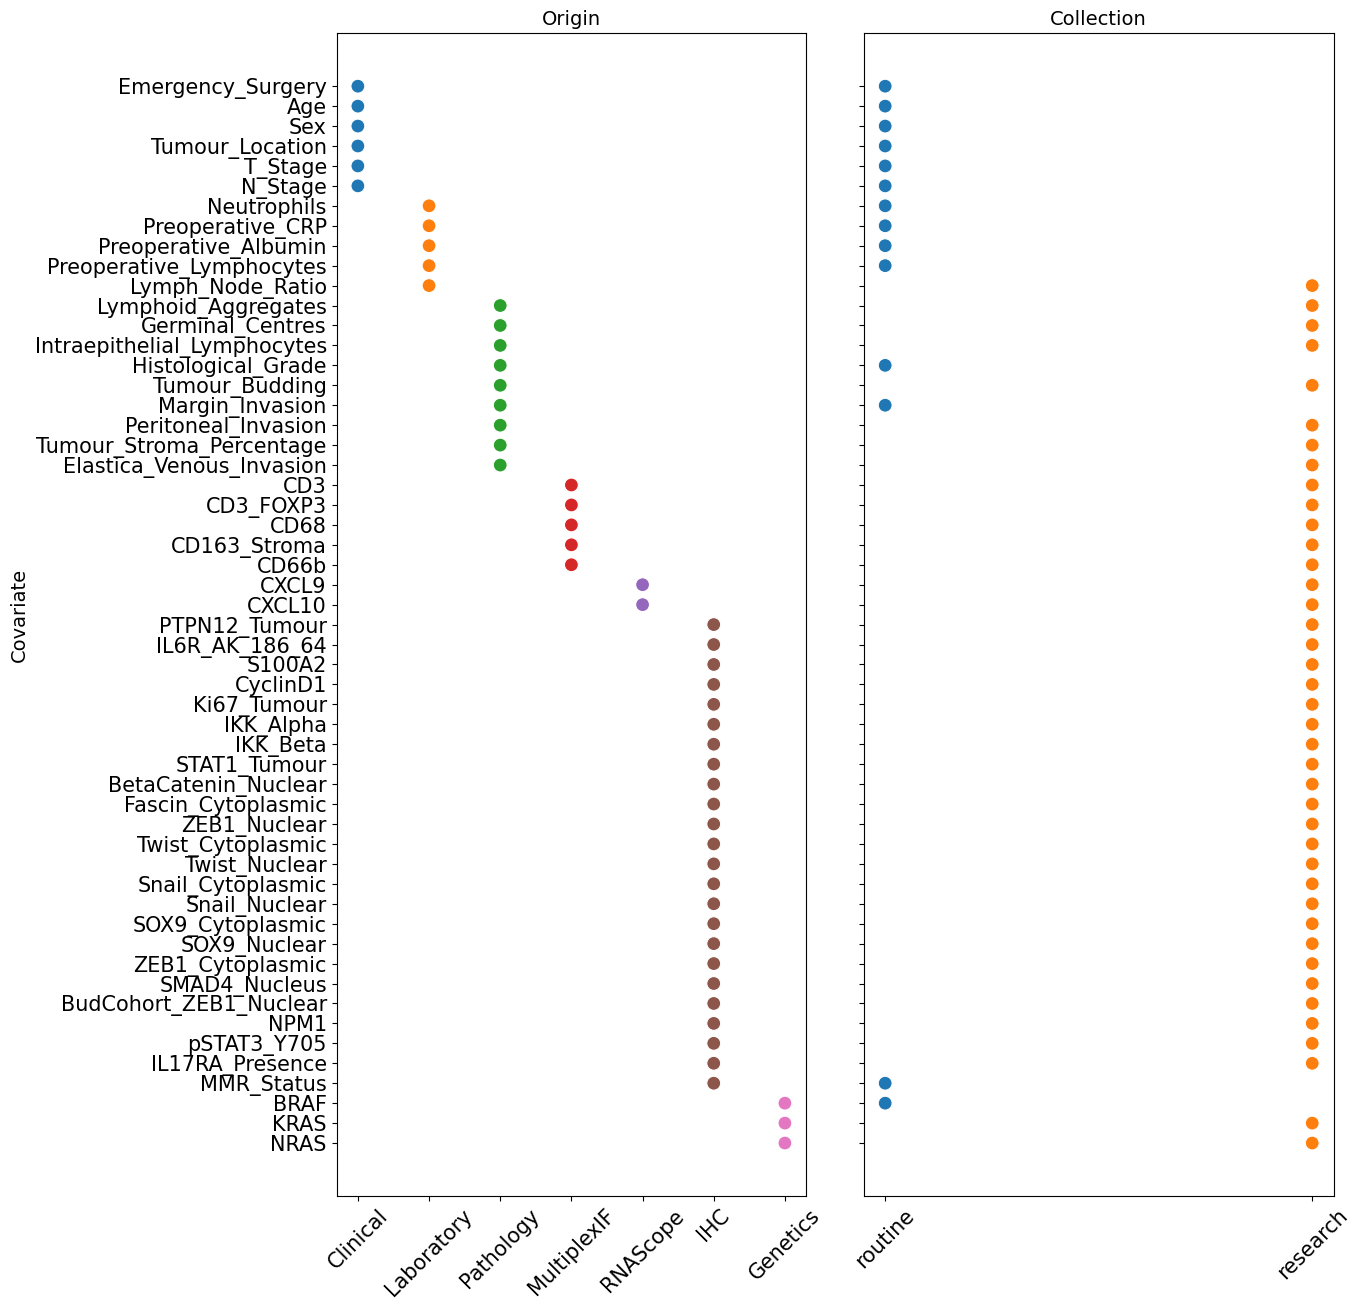

In [406]:
# counts per origin

# keep only metadata for predictors
pred_meta = (
    meta4[meta4["New Data Item"].isin(predictors)]
    .loc[:, ["New Data Item", "Origin", "Collection"]]
    .drop_duplicates()
)


pred_long = pred_meta.melt(
    id_vars="New Data Item",
    value_vars=["Origin", "Collection"],
    var_name="Category",
    value_name="Value"
)

# figure height scales with number of variables
fig, ax = plt.subplots(
    ncols=2,
    figsize=(14, 0.25 * len(pred_meta)),
    sharey=True
)

# left panel: origin
sns.scatterplot(
    data=pred_long[pred_long["Category"] == "Origin"],
    x="Value",
    y="New Data Item",
    hue="Value",
    ax=ax[0],
    s=100, 
    legend=False
)
ax[0].set_title("Origin", fontsize=14)
ax[0].set_xlabel("", fontsize=14)
ax[0].set_ylabel("Covariate", fontsize=14)

# right panel: collection
sns.scatterplot(
    data=pred_long[pred_long["Category"] == "Collection"],
    x="Value",
    y="New Data Item",
    hue="Value",
    ax=ax[1],
    s=100, 
    legend=False
)
ax[1].set_title("Collection", fontsize=14)
ax[1].set_xlabel("", fontsize=14)
ax[1].set_ylabel("", fontsize=14)

for a in ax:
    a.tick_params(axis="y", labelsize=15)
    a.tick_params(axis="x", labelsize=15, rotation=45)

plt.tight_layout()
plt.show()